In [1]:
import sys
import os
sys.path.append("../")
print(os.getcwd())
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import os
from datetime import datetime
from src.model import VAE  

latent_dim = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae_model_path = "../saved_models/vae20250408_230217_vae.pth"
vae = VAE(latent_dim=latent_dim).to(device)  

checkpoint = torch.load(vae_model_path, map_location=device)
vae.load_state_dict(checkpoint['model_state_dict'])
vae.eval()   
pd.set_option("display.max_columns", None)


/mnt/batch/tasks/shared/LS_root/mounts/clusters/jack-vm/code/Projects/Jack_ForceDeck_Winter_2024/countermovement-jump-analysis/scripts


/tmp/ipykernel_3208/2406080412.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(vae_model_path, map_location=device)


In [5]:
data = pd.read_pickle("../data/cleaned_data.pkl")  

In [6]:
len(data)

30012

In [7]:
folder_path = "../../../ForceDeck_Clustering/Vald_API_Tools/data"
sport_dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        df = pd.read_csv(os.path.join(folder_path, filename))
        sport_dfs.append(df)

sport_data = pd.concat(sport_dfs, ignore_index=True)

sport_data['recordedUTC'] = pd.to_datetime(sport_data['recordedUTC'])
data['recordedUTC'] = pd.to_datetime(data['recordedUTC'])

sport_data_trimmed = sport_data[['testID', 'profileID', 'rep', 'jump_start', 'jump_end']]

merged_df = pd.merge(data, sport_data_trimmed, on=['rep', 'testID', 'profileID'], how='left')



In [8]:
merged_df = merged_df.drop_duplicates(subset=['testID', 'profileID', 'rep'], keep='first')


In [9]:
len(merged_df)

30012

In [10]:
len(merged_df[merged_df["jump_start"] > 0])
merged_df["jump_end"].isna().sum()

105

In [11]:
merged_df = merged_df[merged_df["jump_start"] > 0]

In [12]:
# merged_df["jump_start"] = merged_df["START_OF_MOVEMENT"]

In [13]:
data = merged_df.copy()
data["jump_duration_s"] = abs(data["jump_start"] - data["jump_end"])

In [14]:
def find_jump_end_index(sequence, threshold=0):
    """Finds the index of the last non-zero value before flatline."""
    nonzero_indices = (np.abs(sequence) > threshold).nonzero()[0]
    return nonzero_indices[-1] if len(nonzero_indices) > 0 else len(sequence) - 1

def get_jump_end_time(row):
    force_seq = np.array(row["normalized_time_series"])
    end_idx = find_jump_end_index(force_seq)
    return (end_idx / 1000)

data["jump_end_time"] = data.apply(get_jump_end_time, axis=1)

def assign_gender(data, sport_col='Team'):
    male_sports = {
        'Baseball', 'Football',
        "Men's Basketball", "Men's Golf", "Men's Tennis"
    }
    
    female_sports = {
        'Acro and Tumbling', 'Softball', 'Volleyball', 'Volleyball Beach',
        "Women's Basketball", "Women's Golf", "Women's Tennis", "Soccer", "Lacrosse"
    }

    def get_gender(sport):
        if sport in male_sports:
            return 'Male'
        elif sport in female_sports:
            return 'Female'
        else:
            return 'Unknown'  

    data['Gender'] = data[sport_col].apply(get_gender)
    return data

data = assign_gender(data)

In [19]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,116.774858,10.206,10.628,10.37,10.46,18.494496,10.206,8.676187,8.861041,0.424,22.037504,22.51405,22.507032,40.056,result\nPOSITIVE_IMPULSE 305.515939\nPOSITI...,2013.020207,124.807,result\nLANDING_RFD 44361.941\nLANDING_RFD ...,1.851,242.302,-0.095,40.056,result\nPEAK_LANDING_FORCE 2750.440318\nPEA...,3826.224,0.389,49.86295,result\nLANDING_IMPULSE 74.115300\nLANDING_...,35920.0,result\nMEAN_ECCENTRIC_FORCE 541.478054\nME...,216.720458,3.928942,57.900625,result\nECCENTRIC_BRAKING_IMPULSE 24.932420...,637.786472,794.063848,result\nECCENTRIC_BRAKING_RFD 3193.798450\n...,result\nECCENTRIC_DECEL_RFD 3196.428571\nEC...,57.948306,result\nPEAK_ECCENTRIC_FORCE 1077.440318\nP...,19.533001,4850.841392,result\nECCENTRIC_DECEL_IMPULSE 42.495925\n...,

In [20]:
# data = data[data["outlier"] == 0]
data["initial_value"] = data["initial_value"] + 20
data["normalized_time_series"] = data["total_force"] / data["initial_value"]

In [21]:
import torch.nn.functional as F
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_data = torch.tensor(data["normalized_time_series"].tolist(), dtype=torch.float32).to(device)

def find_jump_end(sequence, threshold=0):
    """Finds the last non-zero value before the flatline starts."""
    nonzero_indices = (sequence.abs() > threshold).nonzero(as_tuple=True)[0]
    return nonzero_indices[-1].item() if len(nonzero_indices) > 0 else len(sequence) - 1

def process_jump_data(data, target_length=100):
    """
    Normalizes and resamples jump data.

    Parameters:
        data (torch.Tensor): Original data of shape [num_samples, time_steps]
        target_length (int): Desired length for all jumps after resampling

    Returns:
        torch.Tensor: Processed data of shape [num_samples, target_length]
    """
    num_samples, original_length = data.shape
    processed_data = []

    for i in range(num_samples):
        seq = data[i]
        jump_end = find_jump_end(seq)

        # Trim and interpolate
        trimmed_seq = seq[:jump_end + 1].unsqueeze(0)  
        resampled_seq = F.interpolate(trimmed_seq.unsqueeze(0), size=target_length, mode='linear', align_corners=False).squeeze(0).squeeze(0)

        processed_data.append(resampled_seq)

    return torch.stack(processed_data)

target_length = 100  
processed_data = process_jump_data(test_data, target_length)

data["downsampled_time_series"] = processed_data.cpu().numpy().tolist()  

/tmp/ipykernel_3208/1221499576.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  test_data = torch.tensor(data["normalized_time_series"].tolist(), dtype=torch.float32).to(device)


In [22]:
data["BODY_WEIGHT_LBS"] = data["BODY_WEIGHT_LBS"] * 2.20462
newtons_to_lbs = 0.224809

data['BODY_WEIGHT_LBS'] = data['BODY_WEIGHT_LBS'].fillna(data['initial_value'] * newtons_to_lbs)

In [23]:
data["takeoff_velocity"] = data.apply(
    lambda row: np.mean(np.array(row["downsampled_time_series"]) - 1) * row["jump_duration_s"] * 9.81, axis=1
)
data["takeoff_velocity_2"] = data.apply(
    lambda row: np.mean(np.array(row["downsampled_time_series"]) - 1) * row["jump_duration_s"] * 9.81, axis=1
)

data["tv_jump_height"] = ((data["takeoff_velocity"] ** 2) / (2 * 9.81)) * 39.37
data["tv_jump_height_2"] = ((data["takeoff_velocity_2"] ** 2) / (2 * 9.81)) * 39.37

# use reconsstruction to calculate predicted height 


In [71]:
males = data[data["Gender"] == "Male"]
females = data[data["Gender"] == "Female"]
# males = males[males["outlier"] == 0]
rep_counts = males.groupby("testID")["profileID"].count()
low_rep_testIDs = rep_counts[rep_counts < 2].index
males.loc[males["testID"].isin(low_rep_testIDs), "outlier"] = 1
males["outlier"] = (males["JUMP_HEIGHT_INCHES"] < 5).astype(int)

high_start_mask = males["downsampled_time_series"].apply(lambda x: np.any(np.array(x[20:31]) > 1))

low_air_mask = males["downsampled_time_series"].apply(lambda x: np.any(np.array(x[60:81]) < 1.6))
males["outlier"] = (males["JUMP_HEIGHT_INCHES"] < 5).astype(int)
males["outlier"] = (males["JUMP_HEIGHT_INCHES"] > 30).astype(int)
males.loc[high_start_mask | low_air_mask, "outlier"] = 1

males_clean = males[males["outlier"] == 0].copy()
males = males_clean

# females = females[females["outlier"] == 0]

rep_counts_female = females.groupby("testID")["profileID"].count()
low_rep_testIDs_female = rep_counts_female[rep_counts_female < 2].index
females.loc[females["testID"].isin(low_rep_testIDs_female), "outlier"] = 1

females["outlier"] = (females["JUMP_HEIGHT_INCHES"] < 5).astype(int)
females["outlier"] = (females["JUMP_HEIGHT_INCHES_IMP_MOM"] > 24).astype(int)

high_start_mask_female = females["downsampled_time_series"].apply(lambda x: np.any(np.array(x[20:31]) > 1))
low_air_mask_female = females["downsampled_time_series"].apply(lambda x: np.any(np.array(x[60:81]) < 1.6))

females.loc[high_start_mask_female | low_air_mask_female, "outlier"] = 1

females_clean = females[females["outlier"] == 0].copy()
females = females_clean

/tmp/ipykernel_3208/911079009.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  males["outlier"] = (males["JUMP_HEIGHT_INCHES"] < 5).astype(int)
/tmp/ipykernel_3208/911079009.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  males["outlier"] = (males["JUMP_HEIGHT_INCHES"] < 5).astype(int)
/tmp/ipykernel_3208/911079009.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the document

In [72]:
# len(males)

In [73]:
male_downsampled_data = males['downsampled_time_series'].values

male_downsampled_tensor = torch.tensor(male_downsampled_data.tolist(), dtype=torch.float32).to(device)

female_downsampled_data = females['downsampled_time_series'].values

female_downsampled_tensor = torch.tensor(female_downsampled_data.tolist(), dtype=torch.float32).to(device)

def get_latent_stats(vae, data_tensor):
    vae.eval()
    with torch.no_grad():
        mean, logvar = vae.encode(data_tensor)
        std = torch.exp(0.5 * logvar)
        z = vae.reparameterization(mean, std)
    return mean.cpu().numpy(), std.cpu().numpy(), z.cpu().numpy()

male_means, male_stds, male_latents = get_latent_stats(vae, male_downsampled_tensor)
female_means, female_stds, female_latents = get_latent_stats(vae, female_downsampled_tensor)

males["vae_latent_space_4d"] = list(male_means)
females["vae_latent_space_4d"] = list(female_means)

In [74]:
data = pd.concat([males, females], axis=0)

In [75]:
vae.eval()
with torch.no_grad():
    latent_tensor = torch.tensor(np.vstack(data["vae_latent_space_4d"]), dtype=torch.float32).to(device)
    reconstructed = vae.decode(latent_tensor).cpu().numpy()

data["reconstructed_waveform"] = list(reconstructed)

def adjust_waveform(row):
    fraction = 20 / row["initial_value"]
    first_val = row["reconstructed_waveform"][0]
    offset = first_val * fraction
    adjusted_waveform = np.array(row["reconstructed_waveform"]) - offset
    return adjusted_waveform

data["adjusted_reconstruction"] = data.apply(adjust_waveform, axis=1)


def estimate_takeoff_velocity(waveform, jump_duration):
    force_minus_bw = np.array(waveform) - 1.0  
    avg_net_force = np.mean(force_minus_bw)    
    return avg_net_force * jump_duration * 9.81

data["predicted_takeoff_velocity"] = data.apply(
    lambda row: estimate_takeoff_velocity(row["adjusted_reconstruction"], row["jump_duration_s"]),
    axis=1
)

data["latent_predicted_jump_height"] = ((data["predicted_takeoff_velocity"] ** 2) / (2 * 9.81)) * 39.37  # in inches

In [76]:

data["avg_diff_recon_vs_downsampled"] = data.apply(
    lambda row: np.mean(np.abs(np.array(row["adjusted_reconstruction"]) - np.array(row["downsampled_time_series"]))),
    axis=1
)
data["avg_magnitude_downsampled"] = data["downsampled_time_series"].apply(lambda x: np.mean(np.abs(x)))

data["diff_ratio"] = data["avg_diff_recon_vs_downsampled"] / data["avg_magnitude_downsampled"]

overall_ratio = data["diff_ratio"].mean()
print(f"Average difference as percentage of waveform magnitude: {overall_ratio * 100:.2f}%")

Average difference as percentage of waveform magnitude: 4.97%


In [77]:
data = data[data["outlier"] == 0]
males = data[data["Gender"] == "Male"]
females = data[data["Gender"] == "Female"]

### Do the shapes also vary across male and female jump heights and do they vary in a similar or different manner?

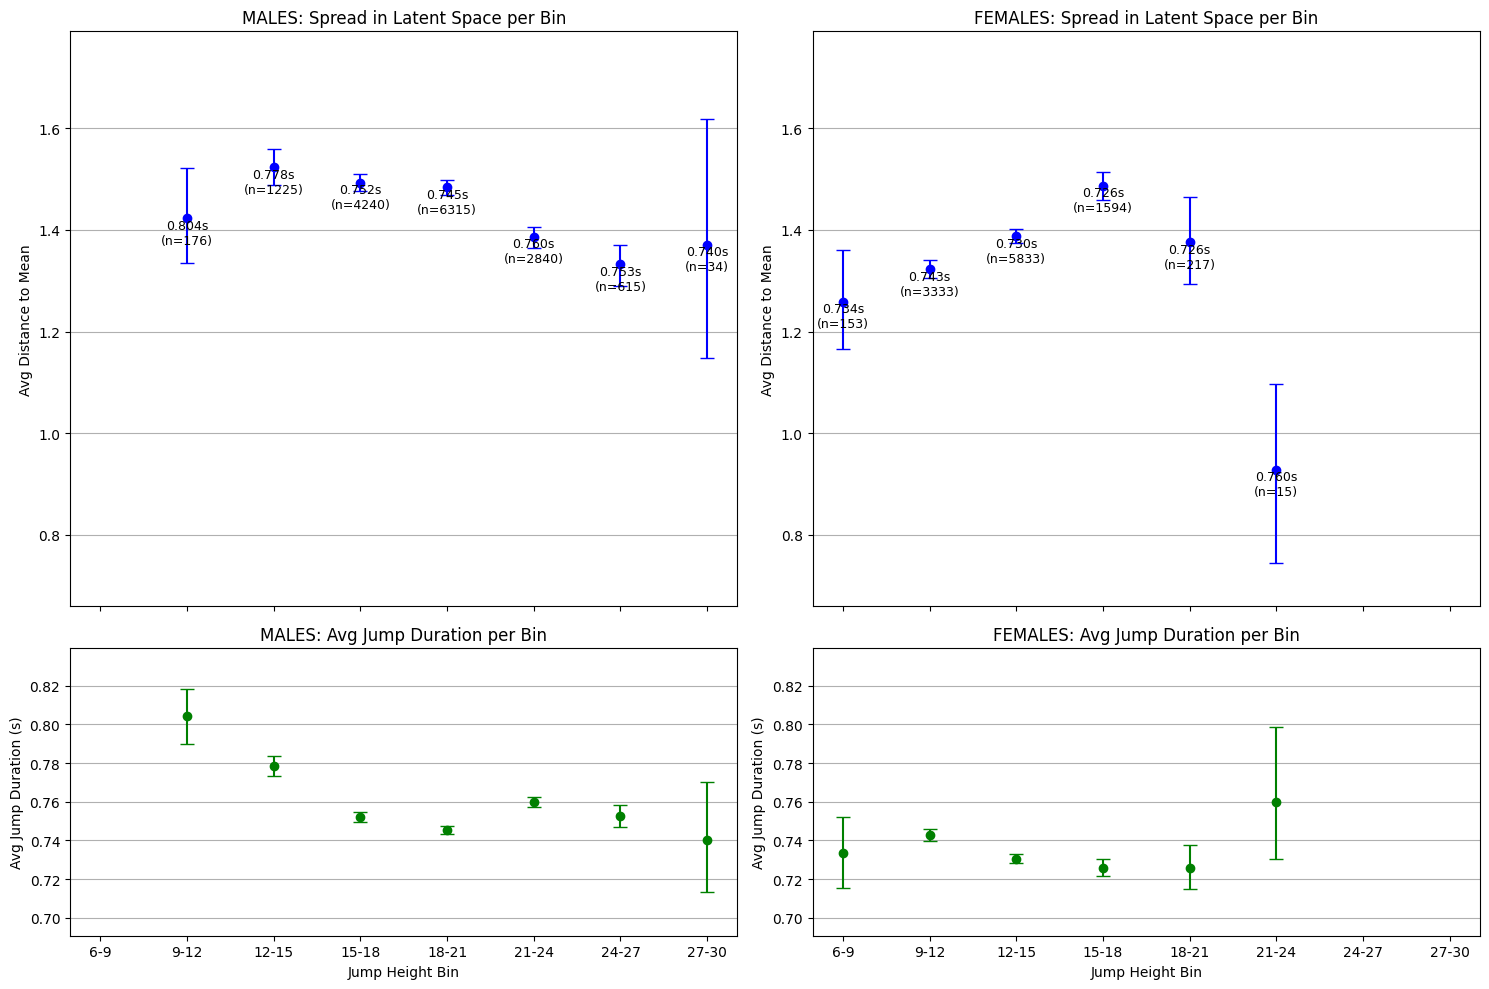

In [78]:
import math
BIN_SIZE = 3  # inches per bin
n_bootstrap = 1000
MIN_SAMPLES = 10  # min samples per bin to include

binned_males = males.dropna(subset=['jump_duration_s', 'JUMP_HEIGHT_INCHES', 'vae_latent_space_4d'])
binned_females = females.dropna(subset=['jump_duration_s', 'JUMP_HEIGHT_INCHES', 'vae_latent_space_4d'])

# binned_males = data[data["Gender"] == "Male"].dropna(subset=['jump_duration_s'])
# binned_females = data[data["Gender"] == "Female"].dropna(subset=['jump_duration_s'])

min_height = math.floor(min(binned_males["JUMP_HEIGHT_INCHES"].min(), binned_females["JUMP_HEIGHT_INCHES"].min()))
max_height = math.ceil(max(binned_males["JUMP_HEIGHT_INCHES"].max(), binned_females["JUMP_HEIGHT_INCHES"].max()))
bins = np.arange(min_height, max_height + BIN_SIZE, BIN_SIZE)
bin_labels = [f"{int(b)}-{int(b + BIN_SIZE)}" for b in bins[:-1]]

binned_males["jump_bin"] = pd.cut(binned_males["JUMP_HEIGHT_INCHES"], bins=bins, labels=bin_labels, include_lowest=True)
binned_females["jump_bin"] = pd.cut(binned_females["JUMP_HEIGHT_INCHES"], bins=bins, labels=bin_labels, include_lowest=True)

def compute_bootstrap(data):
    results = {}

    for bin_label in bin_labels:
        group = data[data["jump_bin"] == bin_label]
        n_total = group.shape[0]

        if n_total < MIN_SAMPLES:
            results[bin_label] = None
            continue

        latent_matrix = np.stack(group["vae_latent_space_4d"].values)
        jump_end_array = group["jump_duration_s"].values

        bootstrap_spreads = []
        for _ in range(n_bootstrap):
            sampled_indices = np.random.choice(n_total, size=n_total, replace=True)
            sample = latent_matrix[sampled_indices]
            sample_mean = sample.mean(axis=0)
            distances = np.linalg.norm(sample - sample_mean, axis=1)
            bootstrap_spreads.append(distances.mean())

        jump_end_boots = []
        for _ in range(n_bootstrap):
            sampled = np.random.choice(jump_end_array, size=n_total, replace=True)
            jump_end_boots.append(sampled.mean())

        results[bin_label] = {
            "mean": np.mean(bootstrap_spreads),
            "ci_lower": np.percentile(bootstrap_spreads, 2.5),
            "ci_upper": np.percentile(bootstrap_spreads, 97.5),
            "jump_mean": np.mean(jump_end_boots),
            "jump_ci_lower": np.percentile(jump_end_boots, 2.5),
            "jump_ci_upper": np.percentile(jump_end_boots, 97.5),
            "count": n_total
        }

    return results

male_results = compute_bootstrap(binned_males)
female_results = compute_bootstrap(binned_females)

all_spreads = [res["mean"] for res in male_results.values() if res is not None] + \
              [res["mean"] for res in female_results.values() if res is not None]
all_jumps = [res["jump_mean"] for res in male_results.values() if res is not None] + \
            [res["jump_mean"] for res in female_results.values() if res is not None]

spread_ymin, spread_ymax = min(all_spreads), max(all_spreads)
jump_ymin, jump_ymax = min(all_jumps), max(all_jumps)

spread_padding = (spread_ymax - spread_ymin) * .45 
jump_padding = (jump_ymax - jump_ymin) * .45

spread_ylim = (spread_ymin - spread_padding, spread_ymax + spread_padding)
jump_ylim = (jump_ymin - jump_padding, jump_ymax + jump_padding)

fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

for ax, results, title in zip(axs.T, [male_results, female_results], ["MALES", "FEMALES"]):
    means, lowers, uppers = [], [], []
    jump_means, jump_lowers, jump_uppers, counts = [], [], [], []

    for bin_label in bin_labels:
        res = results.get(bin_label)
        if res is None:
            means.append(np.nan)
            lowers.append(np.nan)
            uppers.append(np.nan)
            jump_means.append(np.nan)
            jump_lowers.append(np.nan)
            jump_uppers.append(np.nan)
            counts.append(0)
        else:
            means.append(res["mean"])
            lowers.append(res["ci_lower"])
            uppers.append(res["ci_upper"])
            jump_means.append(res["jump_mean"])
            jump_lowers.append(res["jump_ci_lower"])
            jump_uppers.append(res["jump_ci_upper"])
            counts.append(res["count"])

    ax[0].errorbar(bin_labels, means,
                   yerr=[np.array(means) - np.array(lowers), np.array(uppers) - np.array(means)],
                   fmt='o', capsize=5, linestyle='None', color='b')
    for i, (avg_end, count) in enumerate(zip(jump_means, counts)):
        if not np.isnan(avg_end):
            ax[0].text(i, means[i] - 0.05, f"{avg_end:.3f}s\n(n={count})", ha='center', fontsize=9)

    ax[0].set_title(f"{title}: Spread in Latent Space per Bin")
    ax[0].set_ylabel("Avg Distance to Mean")
    ax[0].grid(True, axis='y')
    ax[0].set_ylim(spread_ylim)  

    lower_errors = np.clip(np.array(jump_means) - np.array(jump_lowers), 0, None)
    upper_errors = np.clip(np.array(jump_uppers) - np.array(jump_means), 0, None)

    ax[1].errorbar(bin_labels, jump_means,
                   yerr=[lower_errors, upper_errors],
                   fmt='o', capsize=5, linestyle='None', color='green')

    ax[1].set_ylabel("Avg Jump Duration (s)")
    ax[1].set_xlabel("Jump Height Bin")
    ax[1].set_title(f"{title}: Avg Jump Duration per Bin")
    ax[1].grid(True, axis='y')
    ax[1].set_ylim(jump_ylim)  

plt.tight_layout()
plt.show()


- Top plot (Spread in Latent Space per Bin):
This shows the average distance (spread) between individual jumps and the mean jump in each bin of jump height. Error bars show the confidence intervals. The higher the spread, the more variety of possible jump shapes that will result in jumping within that height bin. 


=== Males ===
Skipping bin 6-9 (only 3 samples)
Bin 9-12: 176 samples | 28 unique athletes | Avg. Duration = 0.805 s | Avg. Weight = 639.6 lbs
Bin 12-15: 1225 samples | 101 unique athletes | Avg. Duration = 0.778 s | Avg. Weight = 548.4 lbs
Bin 15-18: 4240 samples | 215 unique athletes | Avg. Duration = 0.752 s | Avg. Weight = 474.8 lbs
Bin 18-21: 6315 samples | 234 unique athletes | Avg. Duration = 0.745 s | Avg. Weight = 441.8 lbs
Bin 21-24: 2840 samples | 147 unique athletes | Avg. Duration = 0.760 s | Avg. Weight = 432.0 lbs
Bin 24-27: 615 samples | 37 unique athletes | Avg. Duration = 0.753 s | Avg. Weight = 432.7 lbs
Bin 27-30: 34 samples | 7 unique athletes | Avg. Duration = 0.741 s | Avg. Weight = 419.5 lbs

=== Females ===
Bin 6-9: 153 samples | 29 unique athletes | Avg. Duration = 0.734 s | Avg. Weight = 334.5 lbs
Bin 9-12: 3333 samples | 194 unique athletes | Avg. Duration = 0.743 s | Avg. Weight = 352.7 lbs
Bin 12-15: 5833 samples | 246 unique athletes | Avg. Duration = 0.

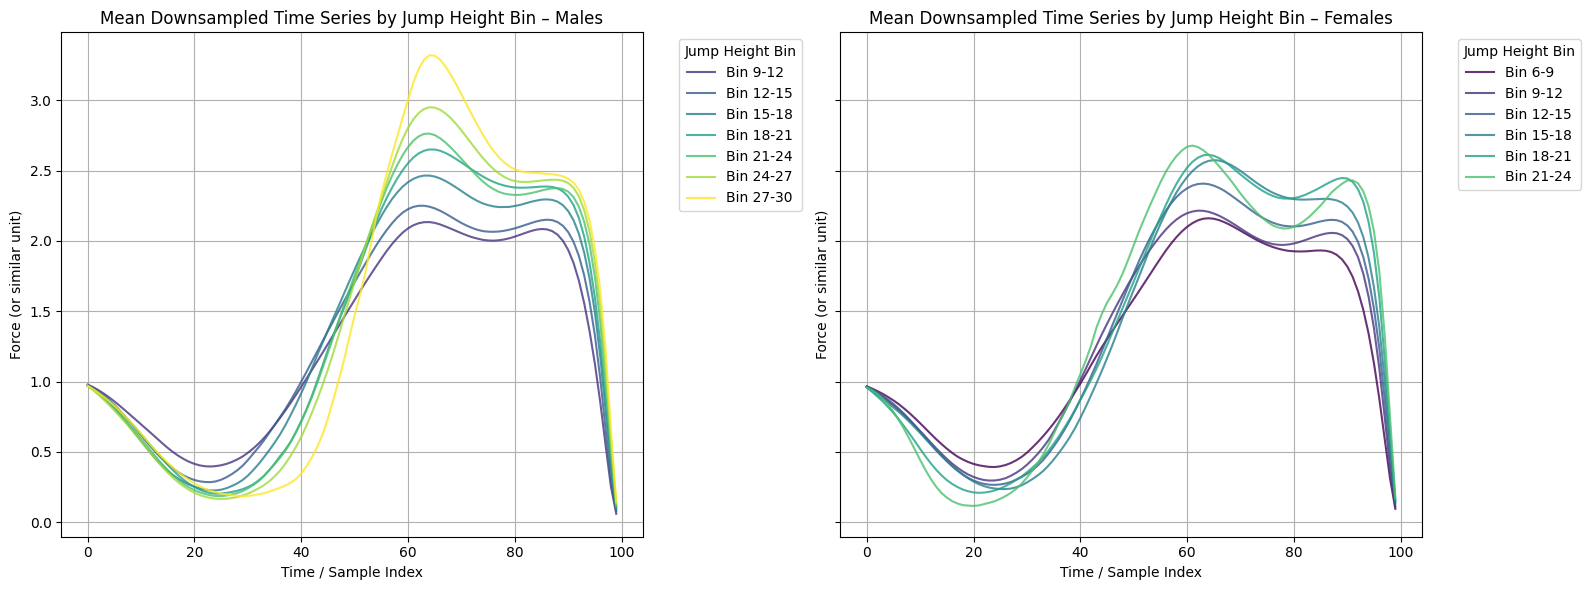

In [79]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
MAX_SAMPLES = 120
MIN_SAMPLES = 10

# Define a color map
cmap = cm.get_cmap("viridis", len(bin_labels))  # or "Set2", "tab20", etc.
bin_color_map = {label: cmap(i) for i, label in enumerate(bin_labels)}

for ax, gender_df, gender_label in zip(axs, [binned_males, binned_females], ["Males", "Females"]):
    print(f"\n=== {gender_label} ===")
    for label in bin_labels:
        group = gender_df[gender_df["jump_bin"] == label]
        n_samples = group.shape[0]

        if n_samples < MIN_SAMPLES:
            print(f"Skipping bin {label} (only {n_samples} samples)")
            continue

        avg_duration = group["jump_duration_s"].mean()
        avg_weight = group["BODY_WEIGHT_LBS"].mean()

        n_athletes = group["profileID"].nunique()
        print(f"Bin {label}: {n_samples} samples | {n_athletes} unique athletes | Avg. Duration = {avg_duration:.3f} s | Avg. Weight = {avg_weight:.1f} lbs")

        group_sample = group.sample(n=min(MAX_SAMPLES, n_samples), random_state=42)

        try:
            series_matrix = np.stack(group_sample["downsampled_time_series"].values)
            mean_series = series_matrix.mean(axis=0)
            ax.plot(mean_series, label=f'Bin {label}', alpha=0.8, color=bin_color_map[label])
        except Exception as e:
            print(f"Skipping plot for bin {label} due to error: {e}")
            continue

    ax.set_title(f"Mean Downsampled Time Series by Jump Height Bin – {gender_label}")
    ax.set_xlabel("Time / Sample Index")
    ax.set_ylabel("Force (or similar unit)")
    ax.legend(title="Jump Height Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True)

plt.tight_layout()
plt.show()


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


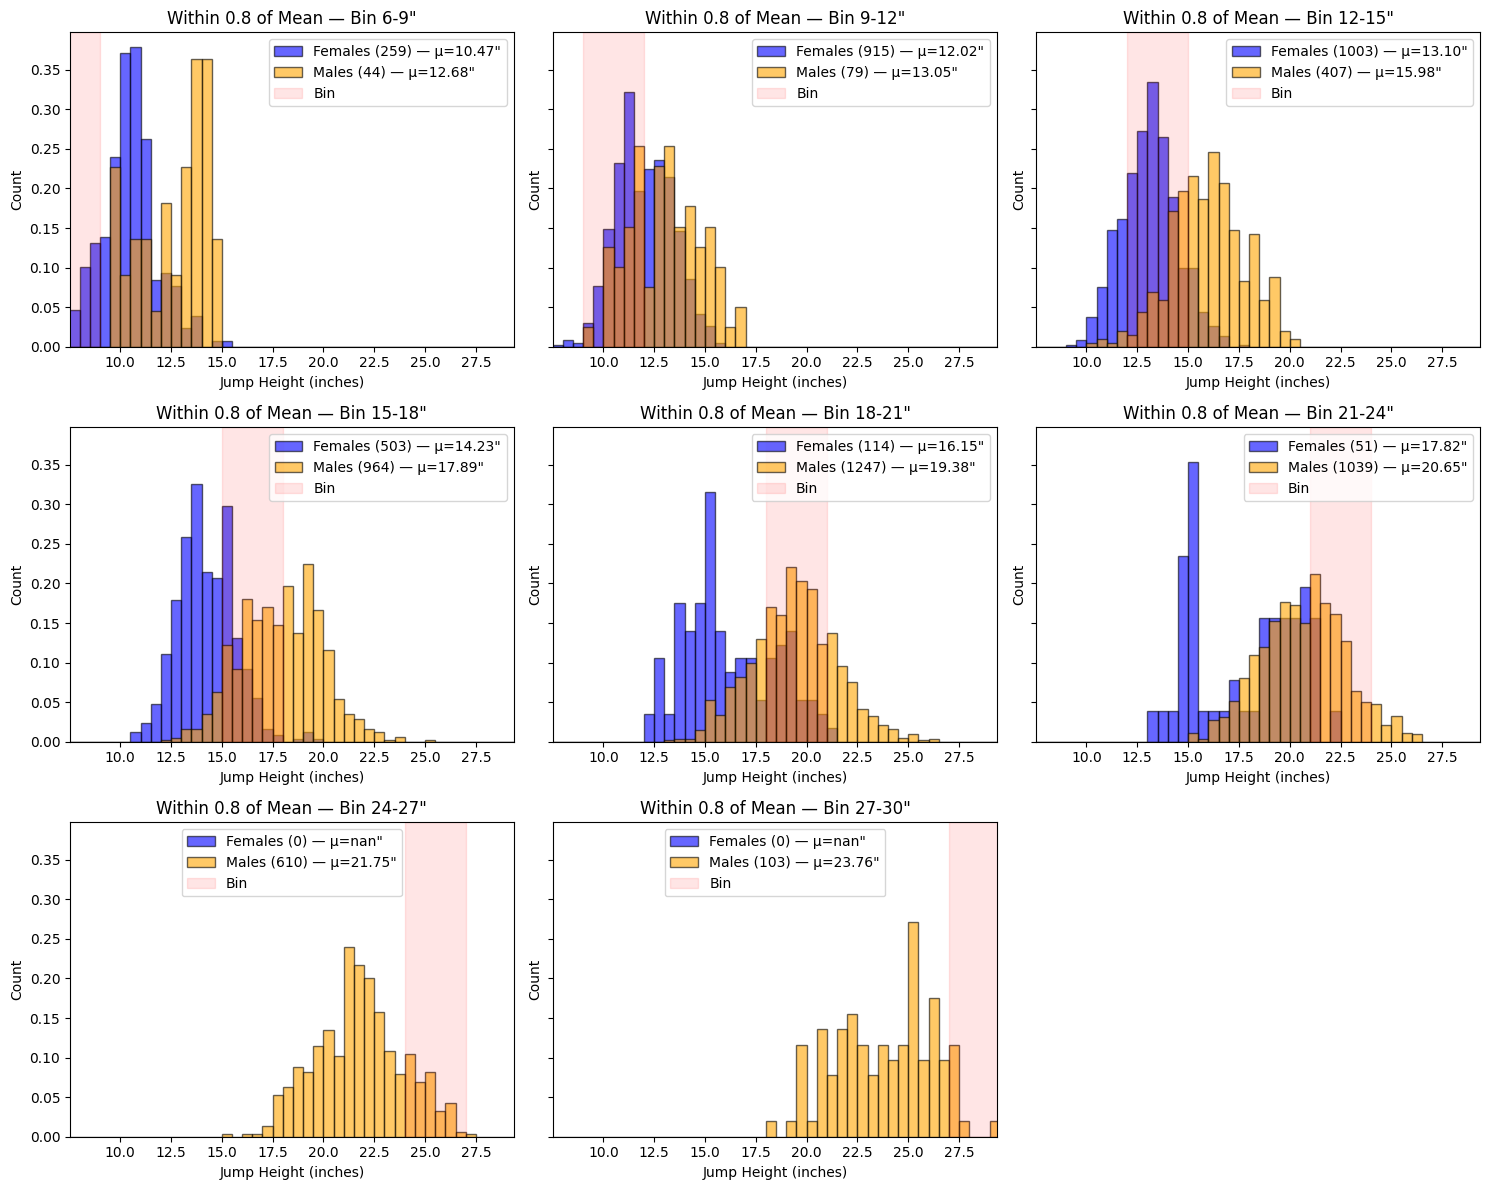

In [80]:
def get_closest_heights_by_bin(df, latent_col, height_col, bin_col, threshold):
    from collections import defaultdict

    closest_heights_per_bin = defaultdict(list)
    overlapping_heights_per_bin = defaultdict(list)

    all_latents = np.stack(df[latent_col].values)
    all_heights = df[height_col].values
    all_bins = df[bin_col].values

    for bin_label in sorted(df[bin_col].unique(), key=lambda x: int(x.split('-')[0])):
        group = df[df[bin_col] == bin_label]
        if group.empty:
            continue

        bin_latents = np.stack(group[latent_col].values)
        mean_vector = bin_latents.mean(axis=0)

        distances = np.linalg.norm(all_latents - mean_vector, axis=1)
        within_threshold = distances < threshold

        closest_heights_per_bin[bin_label] = all_heights[within_threshold]

        mask_in_bin = all_bins == bin_label
        overlap_mask = within_threshold & mask_in_bin
        overlapping_heights_per_bin[bin_label] = all_heights[overlap_mask]

    return closest_heights_per_bin, overlapping_heights_per_bin

DISTANCE_THRESHOLD = 0.8

female_closest, female_overlap = get_closest_heights_by_bin(
    binned_females, "vae_latent_space_4d", "JUMP_HEIGHT_INCHES", "jump_bin", DISTANCE_THRESHOLD
)

male_closest, male_overlap = get_closest_heights_by_bin(
    binned_males, "vae_latent_space_4d", "JUMP_HEIGHT_INCHES", "jump_bin", DISTANCE_THRESHOLD
)
df
all_closest_heights = np.concatenate([
    np.concatenate(list(female_closest.values())),
    np.concatenate(list(male_closest.values()))
])
x_min, x_max = all_closest_heights.min(), all_closest_heights.max()

all_bins = sorted(set(female_closest.keys()) | set(male_closest.keys()), key=lambda x: int(x.split('-')[0]))
n_bins = len(all_bins)
ncols = 3
nrows = int(np.ceil(n_bins / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharey=True)
axs = axs.flatten()

for i, bin_label in enumerate(all_bins):
    ax = axs[i]

    f_heights = female_closest.get(bin_label, [])
    m_heights = male_closest.get(bin_label, [])
    n_females = len(f_heights)
    n_males = len(m_heights)

    f_avg = np.mean(f_heights) if n_females > 0 else np.nan
    m_avg = np.mean(m_heights) if n_males > 0 else np.nan

    ax.hist(f_heights, bins=60, alpha=0.6, density=True, range=(0, 30),
            label=f'Females ({n_females}) — μ={f_avg:.2f}"', color='blue', edgecolor='black')
    ax.hist(m_heights, bins=60, alpha=0.6, density=True, range=(0, 30),
            label=f'Males ({n_males}) — μ={m_avg:.2f}"', color='orange', edgecolor='black')

    try:
        bin_start, bin_end = map(int, bin_label.split('-'))
        ax.axvspan(bin_start, bin_end, color='red', alpha=0.1, label="Bin")
    except ValueError:
        pass

    ax.set_title(f'Within {DISTANCE_THRESHOLD} of Mean — Bin {bin_label}"')
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Jump Height (inches)")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


This plot shows the distribution of jump heights for jumps that are most similar (in latent space) to the average jump in each height bin, separately for females (blue) and males (orange).

For each jump height bin (like 15–18 inches), we:

- Compute the mean latent vector (i.e., average movement pattern) of jumps in that bin.

- Find all jumps (from any bin) whose latent vector is within a threshold distance (0.8) of that mean.

- Plot the distribution of jump heights for these “closest” jumps, by gender.

### Could assessing a sport's jump data, say softball where you have a greater range of jump heights and athletes of various builds/positional demands be a clearer place to explore the autoencoders results? 

Skipping bin 6-9 (only 11 samples)
Bin 9-12: 957 samples | 31 unique athletes | Avg. Duration = 0.722 s
Bin 12-15: 1019 samples | 37 unique athletes | Avg. Duration = 0.704 s
Bin 15-18: 417 samples | 17 unique athletes | Avg. Duration = 0.727 s
Bin 18-21: 115 samples | 4 unique athletes | Avg. Duration = 0.771 s
Skipping bin 21-24 (only 15 samples)


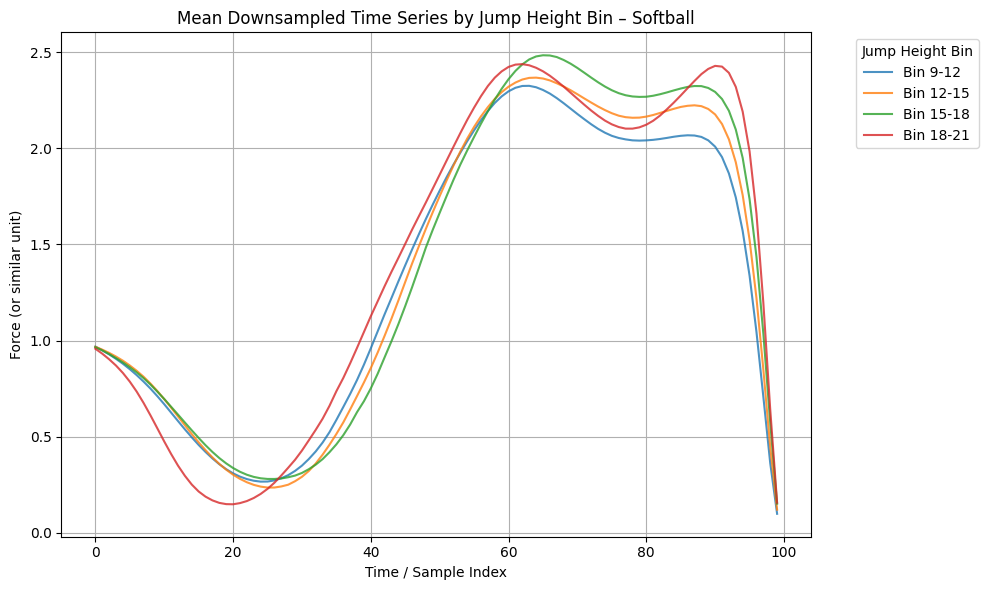

In [81]:
def plot_jump_data_by_sport(selected_sport, binned_data, vae, MIN_SAMPLES=40, MAX_SAMPLES=120):
    sport_data = binned_data[binned_data['Team'] == selected_sport]
    
    if sport_data.empty:
        print(f"No data found for {selected_sport}. Please select a different sport.")
        return

    bin_labels = sorted(sport_data["jump_bin"].unique(), key=lambda x: (int(x.split('-')[0]), int(x.split('-')[1])))

    fig, ax = plt.subplots(figsize=(10, 6))

    for label in bin_labels:
        group = sport_data[sport_data["jump_bin"] == label]
        n_samples = group.shape[0]

        if n_samples < MIN_SAMPLES:
            print(f"Skipping bin {label} (only {n_samples} samples)")
            continue

        avg_duration = group["jump_duration_s"].mean()
        n_athletes = group["profileID"].nunique()
        print(f"Bin {label}: {n_samples} samples | {n_athletes} unique athletes | Avg. Duration = {avg_duration:.3f} s")

        group_sample = group.sample(n=min(MAX_SAMPLES, n_samples), random_state=42)

        try:
            series_matrix = np.stack(group_sample["downsampled_time_series"].values)  
            mean_series = series_matrix.mean(axis=0)  # shape: (T,)
            ax.plot(mean_series, label=f'Bin {label}', alpha=0.8)
        except Exception as e:
            print(f"Skipping plot for bin {label} due to error: {e}")
            continue

    ax.set_title(f"Mean Downsampled Time Series by Jump Height Bin – {selected_sport}")
    ax.set_xlabel("Time / Sample Index")
    ax.set_ylabel("Force (or similar unit)")
    ax.legend(title="Jump Height Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True)

    plt.tight_layout()
    plt.show()

selected_sport = "Softball"  
plot_jump_data_by_sport(selected_sport, binned_females, vae)


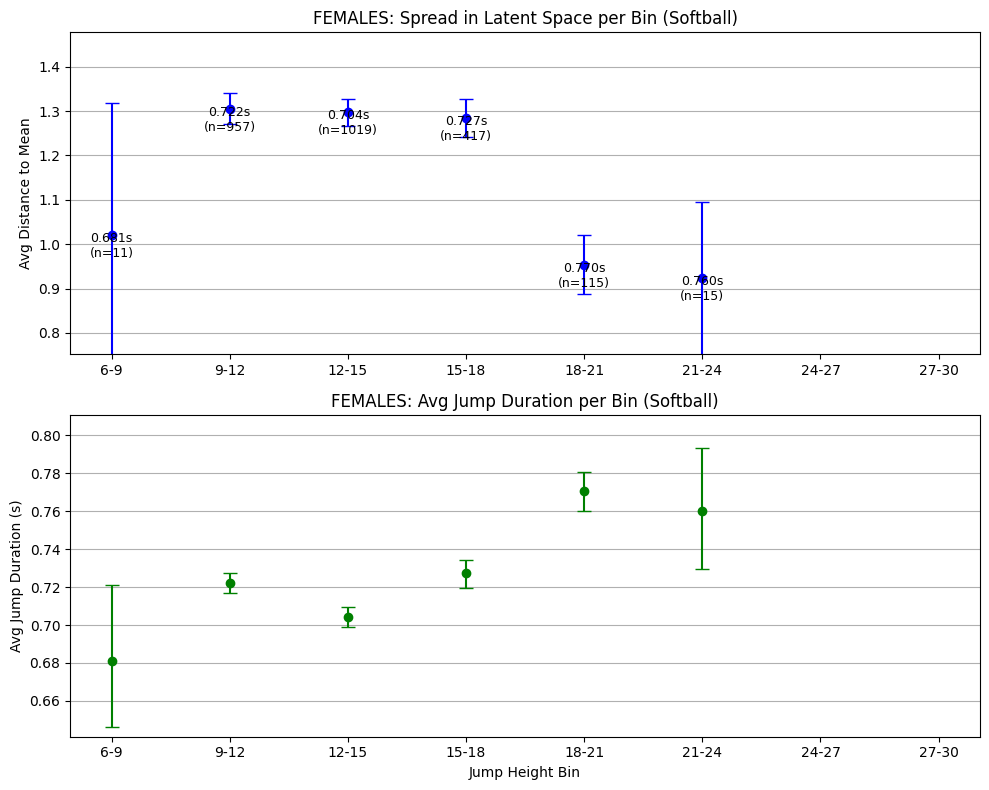

In [82]:
def compute_bootstrap(data):
    results = {}

    for bin_label in bin_labels:
        group = data[data["jump_bin"] == bin_label]
        n_total = group.shape[0]

        if n_total < MIN_SAMPLES:
            results[bin_label] = None
            continue

        latent_matrix = np.stack(group["vae_latent_space_4d"].values)
        jump_end_array = group["jump_duration_s"].values

        bootstrap_spreads = []
        for _ in range(n_bootstrap):
            sampled_indices = np.random.choice(n_total, size=n_total, replace=True)
            sample = latent_matrix[sampled_indices]
            sample_mean = sample.mean(axis=0)
            distances = np.linalg.norm(sample - sample_mean, axis=1)
            bootstrap_spreads.append(distances.mean())

        jump_end_boots = []
        for _ in range(n_bootstrap):
            sampled = np.random.choice(jump_end_array, size=n_total, replace=True)
            jump_end_boots.append(sampled.mean())

        results[bin_label] = {
            "mean": np.mean(bootstrap_spreads),
            "ci_lower": np.percentile(bootstrap_spreads, 2.5),
            "ci_upper": np.percentile(bootstrap_spreads, 97.5),
            "jump_mean": np.mean(jump_end_boots),
            "jump_ci_lower": np.percentile(jump_end_boots, 2.5),
            "jump_ci_upper": np.percentile(jump_end_boots, 97.5),
            "count": n_total
        }

    return results

binned_females_softball = binned_females[binned_females['Team'] == "Softball"]

female_results = compute_bootstrap(binned_females_softball)

all_spreads = [res["mean"] for res in female_results.values() if res is not None]
all_jumps = [res["jump_mean"] for res in female_results.values() if res is not None]

spread_ymin, spread_ymax = min(all_spreads), max(all_spreads)
jump_ymin, jump_ymax = min(all_jumps), max(all_jumps)

spread_padding = (spread_ymax - spread_ymin) * 0.45  
jump_padding = (jump_ymax - jump_ymin) * 0.45

spread_ylim = (spread_ymin - spread_padding, spread_ymax + spread_padding)
jump_ylim = (jump_ymin - jump_padding, jump_ymax + jump_padding)

fig, axs = plt.subplots(2, 1, figsize=(10, 8))

means, lowers, uppers = [], [], []
jump_means, jump_lowers, jump_uppers, counts = [], [], [], []

for bin_label in bin_labels:
    res = female_results.get(bin_label)
    if res is None:
        means.append(np.nan)
        lowers.append(np.nan)
        uppers.append(np.nan)
        jump_means.append(np.nan)
        jump_lowers.append(np.nan)
        jump_uppers.append(np.nan)
        counts.append(0)
    else:
        means.append(res["mean"])
        lowers.append(res["ci_lower"])
        uppers.append(res["ci_upper"])
        jump_means.append(res["jump_mean"])
        jump_lowers.append(res["jump_ci_lower"])
        jump_uppers.append(res["jump_ci_upper"])
        counts.append(res["count"])

axs[0].errorbar(bin_labels, means,
                yerr=[np.array(means) - np.array(lowers), np.array(uppers) - np.array(means)],
                fmt='o', capsize=5, linestyle='None', color='b')
for i, (avg_end, count) in enumerate(zip(jump_means, counts)):
    if not np.isnan(avg_end):
        axs[0].text(i, means[i] - 0.05, f"{avg_end:.3f}s\n(n={count})", ha='center', fontsize=9)

axs[0].set_title("FEMALES: Spread in Latent Space per Bin (Softball)")
axs[0].set_ylabel("Avg Distance to Mean")
axs[0].grid(True, axis='y')
axs[0].set_ylim(spread_ylim)

lower_errors = np.clip(np.array(jump_means) - np.array(jump_lowers), 0, None)
upper_errors = np.clip(np.array(jump_uppers) - np.array(jump_means), 0, None)

axs[1].errorbar(bin_labels, jump_means,
                yerr=[lower_errors, upper_errors],
                fmt='o', capsize=5, linestyle='None', color='green')

axs[1].set_ylabel("Avg Jump Duration (s)")
axs[1].set_xlabel("Jump Height Bin")
axs[1].set_title("FEMALES: Avg Jump Duration per Bin (Softball)")
axs[1].grid(True, axis='y')
axs[1].set_ylim(jump_ylim)

plt.tight_layout()
plt.show()


Bin 6-9: 11 samples | 3 unique athletes | Avg. Duration = 0.681 s | Avg. Weight = 337.57 lbs
Bin 9-12: 957 samples | 31 unique athletes | Avg. Duration = 0.722 s | Avg. Weight = 391.13 lbs
Bin 12-15: 1019 samples | 37 unique athletes | Avg. Duration = 0.704 s | Avg. Weight = 343.41 lbs
Bin 15-18: 417 samples | 17 unique athletes | Avg. Duration = 0.727 s | Avg. Weight = 324.04 lbs
Bin 18-21: 115 samples | 4 unique athletes | Avg. Duration = 0.771 s | Avg. Weight = 277.33 lbs
Bin 21-24: 15 samples | 2 unique athletes | Avg. Duration = 0.759 s | Avg. Weight = 272.28 lbs


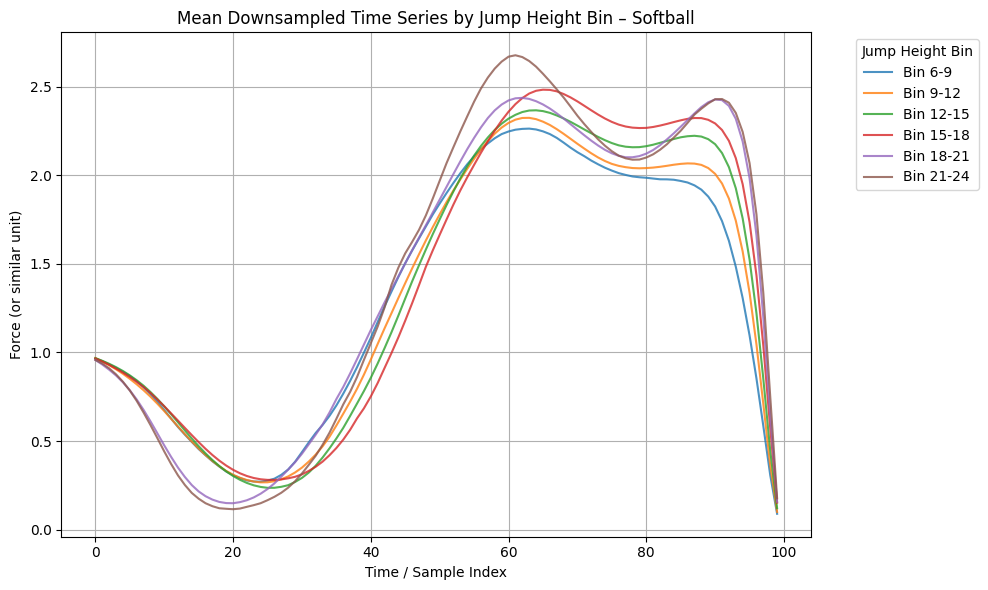

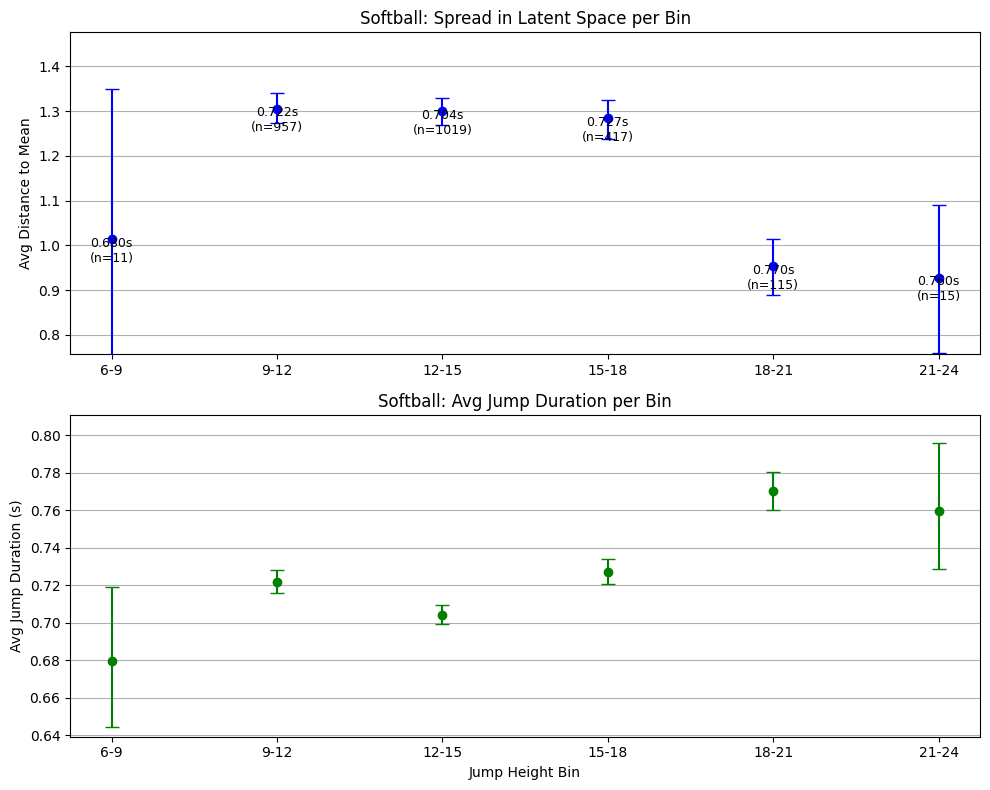

Average Body Weight for each Bin in Softball:
6-9: 337.57 lbs
9-12: 391.13 lbs
12-15: 343.41 lbs
15-18: 324.04 lbs
18-21: 277.33 lbs
21-24: 272.28 lbs


In [83]:
def plot_jump_data_and_compute_bootstrap(selected_sport, binned_data, vae, MIN_SAMPLES=10, MAX_SAMPLES=120, n_bootstrap=1000):
    sport_data = binned_data[binned_data['Team'] == selected_sport]
    
    if sport_data.empty:
        print(f"No data found for {selected_sport}. Please select a different sport.")
        return

    bin_labels = sorted(sport_data["jump_bin"].unique(), key=lambda x: (int(x.split('-')[0]), int(x.split('-')[1])))

    fig, ax = plt.subplots(figsize=(10, 6))

    for label in bin_labels:
        group = sport_data[sport_data["jump_bin"] == label]
        n_samples = group.shape[0]

        if n_samples < MIN_SAMPLES:
            print(f"Skipping bin {label} (only {n_samples} samples)")
            continue

        avg_duration = group["jump_duration_s"].mean()
        n_athletes = group["profileID"].nunique()
        avg_weight = group["BODY_WEIGHT_LBS"].mean()  # Compute the average weight for the bin
        print(f"Bin {label}: {n_samples} samples | {n_athletes} unique athletes | Avg. Duration = {avg_duration:.3f} s | Avg. Weight = {avg_weight:.2f} lbs")

        group_sample = group.sample(n=min(MAX_SAMPLES, n_samples), random_state=42)

        try:
            series_matrix = np.stack(group_sample["downsampled_time_series"].values)  # shape: (N, T)
            mean_series = series_matrix.mean(axis=0)  # shape: (T,)
            ax.plot(mean_series, label=f'Bin {label}', alpha=0.8)
        except Exception as e:
            print(f"Skipping plot for bin {label} due to error: {e}")
            continue

    ax.set_title(f"Mean Downsampled Time Series by Jump Height Bin – {selected_sport}")
    ax.set_xlabel("Time / Sample Index")
    ax.set_ylabel("Force (or similar unit)")
    ax.legend(title="Jump Height Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    results = {}

    for bin_label in bin_labels:
        group = sport_data[sport_data["jump_bin"] == bin_label]
        n_total = group.shape[0]

        if n_total < MIN_SAMPLES:
            results[bin_label] = None
            continue

        latent_matrix = np.stack(group["vae_latent_space_4d"].values)
        jump_end_array = group["jump_duration_s"].values

        bootstrap_spreads = []
        for _ in range(n_bootstrap):
            sampled_indices = np.random.choice(n_total, size=n_total, replace=True)
            sample = latent_matrix[sampled_indices]
            sample_mean = sample.mean(axis=0)
            distances = np.linalg.norm(sample - sample_mean, axis=1)
            bootstrap_spreads.append(distances.mean())

        jump_end_boots = []
        for _ in range(n_bootstrap):
            sampled = np.random.choice(jump_end_array, size=n_total, replace=True)
            jump_end_boots.append(sampled.mean())

        avg_weight = group["BODY_WEIGHT_LBS"].mean()  # Compute the average weight for the bin

        results[bin_label] = {
            "mean": np.mean(bootstrap_spreads),
            "ci_lower": np.percentile(bootstrap_spreads, 2.5),
            "ci_upper": np.percentile(bootstrap_spreads, 97.5),
            "jump_mean": np.mean(jump_end_boots),
            "jump_ci_lower": np.percentile(jump_end_boots, 2.5),
            "jump_ci_upper": np.percentile(jump_end_boots, 97.5),
            "count": n_total,
            "avg_weight": avg_weight  # Store the average weight for the bin
        }

    all_spreads = [res["mean"] for res in results.values() if res is not None]
    all_jumps = [res["jump_mean"] for res in results.values() if res is not None]
    all_weights = [res["avg_weight"] for res in results.values() if res is not None]

    spread_ymin, spread_ymax = min(all_spreads), max(all_spreads)
    jump_ymin, jump_ymax = min(all_jumps), max(all_jumps)

    spread_padding = (spread_ymax - spread_ymin) * 0.45  
    jump_padding = (jump_ymax - jump_ymin) * 0.45

    spread_ylim = (spread_ymin - spread_padding, spread_ymax + spread_padding)
    jump_ylim = (jump_ymin - jump_padding, jump_ymax + jump_padding)

    fig, axs = plt.subplots(2, 1, figsize=(10, 8))

    means, lowers, uppers = [], [], []
    jump_means, jump_lowers, jump_uppers, counts = [], [], [], []
    weights = []

    for bin_label in bin_labels:
        res = results.get(bin_label)
        if res is None:
            means.append(np.nan)
            lowers.append(np.nan)
            uppers.append(np.nan)
            jump_means.append(np.nan)
            jump_lowers.append(np.nan)
            jump_uppers.append(np.nan)
            counts.append(0)
            weights.append(np.nan)
        else:
            means.append(res["mean"])
            lowers.append(res["ci_lower"])
            uppers.append(res["ci_upper"])
            jump_means.append(res["jump_mean"])
            jump_lowers.append(res["jump_ci_lower"])
            jump_uppers.append(res["jump_ci_upper"])
            counts.append(res["count"])
            weights.append(res["avg_weight"])

    axs[0].errorbar(bin_labels, means,
                    yerr=[np.array(means) - np.array(lowers), np.array(uppers) - np.array(means)],
                    fmt='o', capsize=5, linestyle='None', color='b')
    for i, (avg_end, count) in enumerate(zip(jump_means, counts)):
        if not np.isnan(avg_end):
            axs[0].text(i, means[i] - 0.05, f"{avg_end:.3f}s\n(n={count})", ha='center', fontsize=9)

    axs[0].set_title(f"{selected_sport}: Spread in Latent Space per Bin")
    axs[0].set_ylabel("Avg Distance to Mean")
    axs[0].grid(True, axis='y')
    axs[0].set_ylim(spread_ylim)

    lower_errors = np.clip(np.array(jump_means) - np.array(jump_lowers), 0, None)
    upper_errors = np.clip(np.array(jump_uppers) - np.array(jump_means), 0, None)

    axs[1].errorbar(bin_labels, jump_means,
                    yerr=[lower_errors, upper_errors],
                    fmt='o', capsize=5, linestyle='None', color='green')

    axs[1].set_ylabel("Avg Jump Duration (s)")
    axs[1].set_xlabel("Jump Height Bin")
    axs[1].set_title(f"{selected_sport}: Avg Jump Duration per Bin")
    axs[1].grid(True, axis='y')
    axs[1].set_ylim(jump_ylim)

    plt.tight_layout()
    plt.show()

    print(f"Average Body Weight for each Bin in {selected_sport}:")
    for bin_label, weight in zip(bin_labels, weights):
        print(f"{bin_label}: {weight:.2f} lbs")

selected_sport = "Softball"
plot_jump_data_and_compute_bootstrap(selected_sport, binned_females, vae)


Plotting 115 downsampled series for bin 18-21 in Softball...


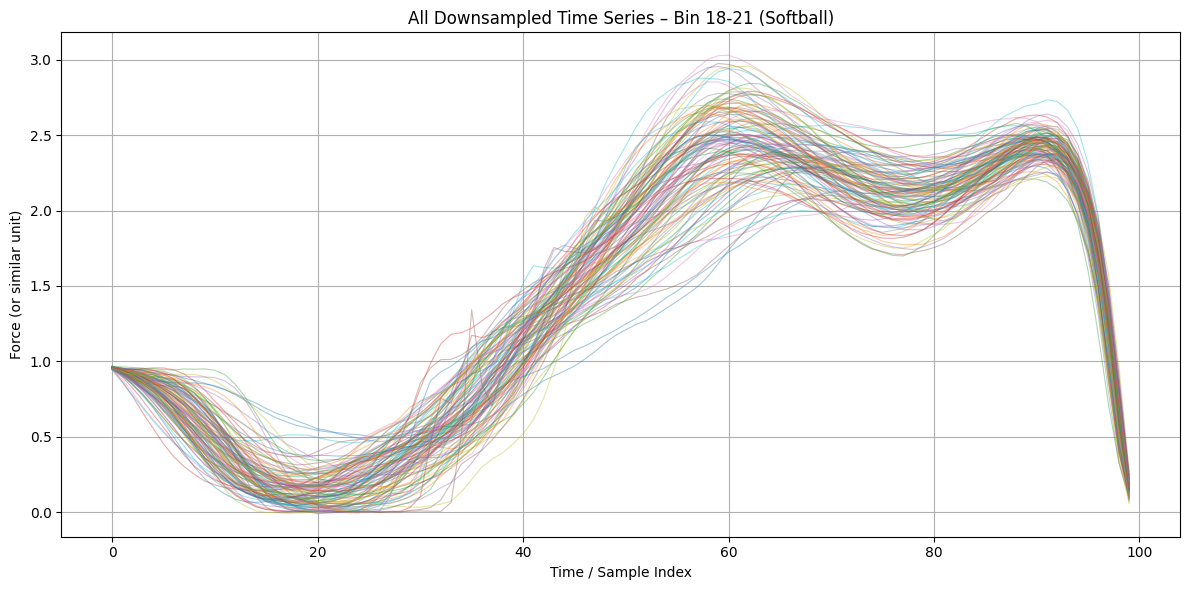

In [84]:
def plot_all_downsampled_series_for_bin(selected_sport, binned_data, target_bin="18-21"):
    sport_data = binned_data[binned_data["Team"] == selected_sport]

    if sport_data.empty:
        print(f"No data for {selected_sport}")
        return

    bin_data = sport_data[sport_data["jump_bin"] == target_bin]

    if bin_data.empty:
        print(f"No data for bin '{target_bin}' in {selected_sport}")
        return

    print(f"Plotting {len(bin_data)} downsampled series for bin {target_bin} in {selected_sport}...")

    plt.figure(figsize=(12, 6))

    for i, row in bin_data.iterrows():
        try:
            series = row["downsampled_time_series"]
            plt.plot(series, alpha=0.4, linewidth=0.8)
        except Exception as e:
            print(f"Error plotting index {i}: {e}")

    plt.title(f"All Downsampled Time Series – Bin {target_bin} ({selected_sport})")
    plt.xlabel("Time / Sample Index")
    plt.ylabel("Force (or similar unit)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_all_downsampled_series_for_bin("Softball", binned_females, target_bin="18-21")


latent_1           0.172047
latent_2          -0.696273
latent_3          -0.363737
latent_4          -0.307891
jump_duration_s    1.000000
Name: jump_duration_s, dtype: float64


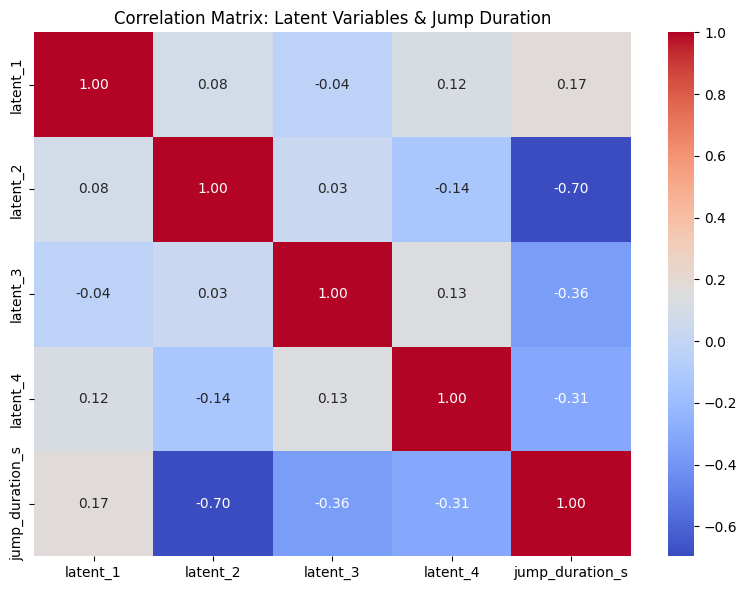

In [85]:
X_latent_4d = np.stack(males["vae_latent_space_4d"].values)
latent_df = pd.DataFrame(X_latent_4d, columns=["latent_1", "latent_2", "latent_3", "latent_4"])

latent_df["jump_duration_s"] = males["jump_duration_s"].values
corr_df = latent_df.dropna()

correlation_matrix = corr_df.corr()

print(correlation_matrix["jump_duration_s"])


plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: Latent Variables & Jump Duration")
plt.tight_layout()
plt.show()


In [86]:
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

model_df = males.dropna(subset=["jump_duration_s", "JUMP_HEIGHT_INCHES_IMP_MOM", "vae_latent_space_4d"])

X_latent = np.stack(model_df["vae_latent_space_4d"].values)
X = np.hstack([X_latent, model_df[["jump_duration_s"]].values])
y = model_df["JUMP_HEIGHT_INCHES_IMP_MOM"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Test RMSE: {rmse:.2f} inches")

print("Coefficients (latent_1 to latent_4, then jump_duration_s):", model.coef_)
# males.head(1)

Test RMSE: 1.68 inches
Coefficients (latent_1 to latent_4, then jump_duration_s): [-2.03375981  3.70292576 -1.16418346  1.99078717 27.86275836]


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [87]:
# def adjust_waveform(row):
#     fraction = 20 / row["initial_value"]
#     first_val = row["reconstructed_waveform"][0]
#     offset = first_val * fraction
#     adjusted_waveform = np.array(row["reconstructed_waveform"]) - offset
#     return adjusted_waveform

# males["adjusted_reconstruction"] = males.apply(adjust_waveform, axis=1)


In [88]:
males.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2,outlier,vae_latent_space_4d,reconstructed_waveform,adjusted_reconstruction,predicted_takeoff_velocity,latent_predicted_jump_height,avg_diff_recon_vs_downsampled,avg_magnitude_downsampled,diff_ratio
1438,0,0,adaee8b6-4ae7-4292-b7f4-8c1491cfb54c,1,b2cf3cb0-ec27-4a6a-b65c-0f0e86650797,2023-11-02 22:04:03.724000+00:00,Baseball,Sport,NaN,NaN,421.539954,35.34,35.828,35.532,35.678,17.514109,35.34,22.977109,22.176691,0.69,58.361826,56.314473,56.328765,108.007,result\nPOSITIVE_IMPULSE 845.683491\nPOSITI...,6433.102659,180.127,result\nLANDING_RFD 375447.617\nLANDING_RFD...,2.543,986.282,-0.143,108.007,result\nPEAK_LANDING_FORCE 10512.533271\nPE...,29926.697,0.838,117.813888,result\nLANDING_IMPULSE 89.352932\nLANDING_...,46380.0,result\nMEAN_ECCENTRIC_FORCE 880.741434\nME...,744.683532,8.345663,104.00544,result\nECCENTRIC_BRAKING_IMPULSE 71.46482...,1118.821861,1895.809587,result\nECCENTRIC_BR

Text(0.5, 1.0, 'Actual vs. Predicted Jump Height')

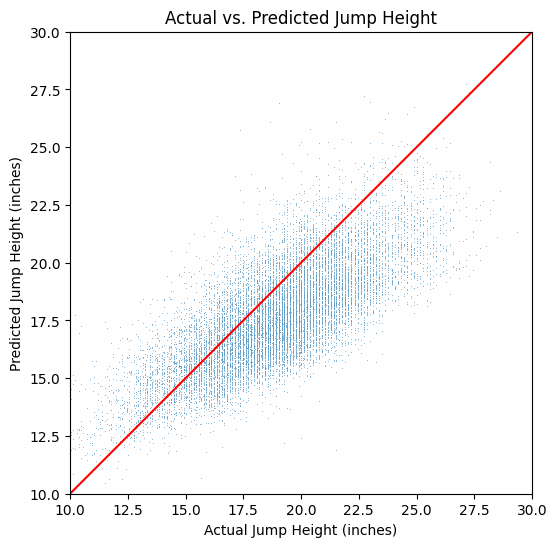

In [89]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=males["JUMP_HEIGHT_INCHES"],
    y=males["latent_predicted_jump_height"],
    alpha=1,
    s=0.4
)

plt.plot([10, 30], [10, 30], color='red')

plt.xlim(10, 30)
plt.ylim(10, 30)

plt.gca().set_aspect('equal', adjustable='box')

plt.xlabel("Actual Jump Height (inches)")
plt.ylabel("Predicted Jump Height (inches)")
plt.title("Actual vs. Predicted Jump Height")


In [90]:
average_difference = (data["latent_predicted_jump_height"] - data["JUMP_HEIGHT_INCHES"]).abs().mean()
print(f"Average Difference (Predicted - Actual): {average_difference:.2f} inches")
average_abs_difference = (data["tv_jump_height"] - data["JUMP_HEIGHT_INCHES"]).abs().mean()
print(f"Mean Absolute Difference: {average_abs_difference:.2f} inches")

Average Difference (Predicted - Actual): 1.59 inches
Mean Absolute Difference: 1.46 inches


In [91]:
# latent_vals = np.stack(model_df["vae_latent_space_4d"].values)
# min_vals = latent_vals.min(axis=0)
# max_vals = latent_vals.max(axis=0)
# duration_min = model_df["jump_duration_s"].min()
# duration_max = model_df["jump_duration_s"].max()

# print("Latent min/max:", min_vals, max_vals)
# print("Duration range:", duration_min, duration_max)


In [92]:

len(males[(males["JUMP_HEIGHT_INCHES_IMP_MOM"] > 24) & (males["outlier"] == 0)])
before = len(males)
after = len(males.dropna(subset=['jump_duration_s']))
print("Dropped due to NaNs in Jump Duration (s):", before - after)
print(f"Before: {before}, After: {after}")

Dropped due to NaNs in Jump Duration (s): 0
Before: 15448, After: 15448


In [93]:
# X_latent = np.stack(model_df["vae_latent_space_4d"].values)
# X = np.hstack([X_latent, model_df[["jump_duration_s"]].values])
# y = model_df["JUMP_HEIGHT_INCHES_IMP_MOM"].values

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model = LinearRegression()
# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)
# rmse = mean_squared_error(y_test, y_pred, squared=False)

# latent_vec = [-2.47, 2.22, -2.29, 2.92]

# print(f"Ideal vector is {latent_vec}")

# x1 = float(input("Enter a number for Latent 1: "))
# x2 = float(input("Enter a number for Latent 2: "))
# x3 = float(input("Enter a number for Latent 3: "))
# x4 = float(input("Enter a number for Latent 4: "))
# latent_vec_2  = [x1, x2, x3, x4]

# mean_jump_duration = model_df["jump_duration_s"].mean()  # USING THE MEAN JUMP DURATION


# X_optimal = np.hstack([latent_vec, [mean_jump_duration]])
# X_input = np.hstack([latent_vec_2, [mean_jump_duration]])

# predicted_jump_optimal = model.predict([X_optimal])[0]
# predicted_jump_input = model.predict([X_input])[0]

# print(f"Predicted Jump Height for Optimal Latent Vector: {predicted_jump_optimal:.2f} inches")
# print(f"Predicted Jump Height for User Input Latent Vector: {predicted_jump_input:.2f} inches")

# # Reconstruct the force curves
# vae.eval()

# latent_tensor = torch.tensor(latent_vec, dtype=torch.float32).unsqueeze(0)
# latent_tensor_2 = torch.tensor(latent_vec_2, dtype=torch.float32).unsqueeze(0)

# with torch.no_grad():
#     reconstructed = vae.decode(latent_tensor).squeeze().cpu().numpy()
#     reconstructed_2 = vae.decode(latent_tensor_2).squeeze().cpu().numpy()

# plt.figure(figsize=(10, 4))
# plt.plot(reconstructed, label="Optimal Latent Vector")
# plt.plot(reconstructed_2, label="User Input Latent Vector")
# plt.title("Reconstructed Force Curves")
# plt.xlabel("Time (samples)")
# plt.ylabel("Total Force (N)")
# plt.grid(True)
# plt.legend()  
# plt.tight_layout()
# plt.show()


In [94]:
# males["profileID"].unique()

### Prescribing a Jump to Increase Height by X inches
- Modify latent vector so predicted jump height increases by 'delta'
- Regression model used to predict height based on Latent Space and jump duration

In [95]:
from scipy.optimize import minimize


def prescribe_jump_improvement(profileID, model_df, vae, top_n=1, delta=1.0):
    vae.eval()
    athlete_df = model_df[model_df["profileID"] == profileID].copy()
    
    if athlete_df.empty:
        print(f"No data found for profileID: {profileID}")
        return

    top_jumps = athlete_df.sort_values("recordedUTC", ascending=False).head(top_n)

    for idx, row in top_jumps.iterrows():
        latent_vec = np.array(row["vae_latent_space_4d"])
        jump_duration = row["jump_duration_s"]
        initial_val = row["initial_value"]
        jump_date = row["recordedUTC"]
        actual_recorded_height = row["JUMP_HEIGHT_INCHES"]

        if initial_val < 1e-3:
            print(f"[SKIP] initial_val too small ({initial_val})")
            continue
        if jump_duration > 2.0 or jump_duration <= 0:
            print(f"[SKIP] suspicious jump_duration ({jump_duration:.3f}s)")
            continue

        def predict_height(z):
            with torch.no_grad():
                z_tensor = torch.tensor(z, dtype=torch.float32).unsqueeze(0)
                rec = vae.decode(z_tensor).squeeze().cpu().numpy()

            rec = np.clip(rec, 0, 5)  
            offset = rec[0] * (20 / initial_val)
            adjusted = rec - offset
            net_force = adjusted - 1.0
            avg_net_force = np.mean(net_force)
            takeoff_velocity = avg_net_force * jump_duration * 9.81
            height = (takeoff_velocity ** 2) / (2 * 9.81) * 39.37

            # if height > 35:
                # print(f"[WARN] Predicted height too large: {height:.2f}")
            return height

        # Predict height from latent vector (not recorded height)
        predicted_orig_height = predict_height(latent_vec)
        target_jump_height = predicted_orig_height + delta

        def objective(z_new):
            pred = predict_height(z_new)
            penalty = max(0, target_jump_height - pred) ** 2  # Penalize shortfall
            return np.sum((z_new - latent_vec) ** 2) + 10 * penalty


        def constraint(z_new):
            return predict_height(z_new) - target_jump_height

        bounds = [(val - 2.0, val + 2.0) for val in latent_vec]

        # result = minimize(
        #     objective,
        #     x0=latent_vec,
        #     method='SLSQP',
        #     constraints={'type': 'ineq', 'fun': constraint},
        #     bounds=bounds,
        #     options={'maxiter': 1000, 'disp': True}
        # )
        
        from scipy.optimize import basinhopping

        minimizer_kwargs = {
            "method": "SLSQP",
            "bounds": bounds,
            "constraints": {'type': 'ineq', 'fun': constraint}
        }
        result = basinhopping(objective, x0=latent_vec, minimizer_kwargs=minimizer_kwargs, niter=100)


        print("\n" + "=" * 60)
        print(f"Jump ID: {row['profileID']}, Date: {jump_date}, Jump Duration: {jump_duration:.2f} s")
        print(f"Predicted Original Height: {predicted_orig_height:.2f} inches")
        print(f"Target Prescribed Height: {target_jump_height:.2f} inches")
        print(f"Actual Jump Height: {actual_recorded_height} inches")


    z_new = result.x
    predicted_new_height = predict_height(z_new)
    print("Optimization succeeded.")
    print(f"Prescribed Height: {predicted_new_height:.2f} inches")
    print(f"Latent change magnitude: {np.linalg.norm(z_new - latent_vec):.4f}")

    print(f"\nLatent Dimension Comparison:")
    print(f"{'Dim':<5}{'Original':>12}{'New':>12}{'Δ (New - Orig)':>18}")
    for i, (orig, new) in enumerate(zip(latent_vec, z_new)):
        print(f"{i+1:<5}{orig:>12.4f}{new:>12.4f}{(new - orig):>18.4f}")

    with torch.no_grad():
        rec_orig = vae.decode(torch.tensor(latent_vec, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()
        rec_new = vae.decode(torch.tensor(z_new, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()

    offset_orig = rec_orig[0] * (20 / initial_val)
    offset_new = rec_new[0] * (20 / initial_val)
    adj_orig = rec_orig - offset_orig
    adj_new = rec_new - offset_new

    plt.figure(figsize=(10, 4))
    plt.plot(adj_orig, label=f"Original (Predicted: {predicted_orig_height:.2f})")
    plt.plot(adj_new, label=f"Prescribed (Predicted: {predicted_new_height:.2f})")
    plt.title(f"Force Curve (Jump ID: {row['profileID']})")
    plt.xlabel("Time (samples)")
    plt.ylabel("Total Force (N)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# else:
#     print("Optimization failed.")
#     print(result.message)



In [96]:
# model_df[model_df["profileID"] == "dc014c8c-efea-4ae2-b759-9c054903a557"]

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/scipy/optimize/_optimize.py:353: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "



Jump ID: 5743491d-af1f-47fb-8838-252a96696964, Date: 2024-12-28 20:21:48.544000+00:00, Jump Duration: 0.82 s
Predicted Original Height: 18.29 inches
Target Prescribed Height: 20.29 inches
Actual Jump Height: 15.570188770140176 inches
Optimization succeeded.
Prescribed Height: 20.29 inches
Latent change magnitude: 0.3186

Latent Dimension Comparison:
Dim      Original         New    Δ (New - Orig)
1          0.2095      0.0957           -0.1138
2          0.4077      0.6930            0.2853
3         -0.0651     -0.0972           -0.0320
4         -0.8380     -0.7596            0.0784


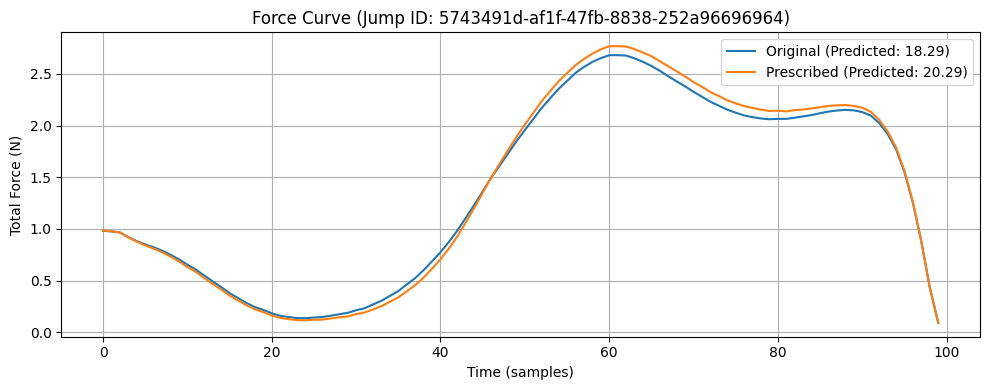

In [97]:

# prescribe_jump_improvement(profileID="5743491d-af1f-47fb-8838-252a96696964", model_df=binned_males, top_n=1, vae=vae, delta=2)


In [98]:
def identify_plateaued_athletes(model_df, min_increase=1.0):
    """
    Identifies athletes who have plateaued based on their jump performance and ensure 
    there are at least two different days of data.
    """
    plateaued_athletes = []  
    
    for profileID in model_df['profileID'].unique():
        athlete_df = model_df[model_df['profileID'] == profileID].sort_values('recordedUTC')
        
        unique_dates = athlete_df['recordedUTC'].dt.date.nunique()
        
        if unique_dates < 2:
            continue  
        
        max_jump_height = athlete_df['JUMP_HEIGHT_INCHES'].max()
        min_jump_height = athlete_df['JUMP_HEIGHT_INCHES'].min()
        
        if max_jump_height - min_jump_height < min_increase:
            plateaued_athletes.append(profileID)
    
    return plateaued_athletes


plateaued_athletes = identify_plateaued_athletes(data, min_increase=2.0)
print("Plateaued Athletes:", plateaued_athletes)


Plateaued Athletes: ['599d08c4-2361-4ad9-a2dd-2ceec9c26da4', '33edf078-8844-4d11-abae-539ad16de27b', '6565f9c0-e379-4c73-8f93-6a0b6ab13fbb', 'c0c0eb57-5a96-40e1-9df9-f841eec3ec2c', 'df9367ee-f99c-4a44-86ff-341915d8699c', '52a47c3f-955e-49d7-ac00-00b1ce6f5a6c', 'e449ad44-a151-4cc3-b97c-078b72fa9a82', '3aeec28f-9e76-47f4-acbc-3c3b1f8d8b8e', 'f5ba2233-5b3b-4646-a6ea-b3cf814294e2', 'b6c10b34-caaf-41d3-8c5f-bb0f598adda0', 'e536e874-50c6-498d-8d56-0ec15b110691', 'dd4bd1dc-b3be-483c-bccd-282cd99eb02e', '9d4c9096-d765-4ce5-9a95-f5b613f6b1d7', '194398a7-7000-48c5-941d-0846a3982e09', '45c6611f-15ab-4409-9c79-23f2cc9a0f99', '33ed5f5e-e7d0-4b67-9e4c-2f93ff66a415', '4c13676c-d180-4291-8e35-4e1ef72f08d2', '53ce847c-4b4a-468a-b726-7d830345de05', '48594ea2-7e25-43c8-8f94-b08c357ba9a3', '5e012055-7343-4ee9-b0ea-f0b72ca05a60', '8060d57e-3fe2-4f73-8cbf-f4ca3c3c4f71', 'e8f3340f-736e-4ffc-bb41-02e46f863564', '9e8fca1d-9bd2-46dd-a55f-15371d03b7da', '7c05c496-e5bf-498f-85b4-1ad13aa530e8', 'd7cb766c-970d-4734

In [99]:
# scale time for everyone and subtract mean of distribution and dividie by standard deviation \
# mean of all time variables
# take standard deviation of all time varibles
# transform all times by subtracting mean and dividie by standard deviation between (-1 and 1)



=== Males ===
Skipping bin 6-9 (only 3 samples)
Bin 9-12: 176 samples
Bin 12-15: 1225 samples
Bin 15-18: 4240 samples
Bin 18-21: 6315 samples
Bin 21-24: 2840 samples
Bin 24-27: 615 samples
Bin 27-30: 34 samples

=== Females ===
Bin 6-9: 153 samples
Bin 9-12: 3333 samples
Bin 12-15: 5833 samples
Bin 15-18: 1594 samples
Bin 18-21: 217 samples
Bin 21-24: 15 samples
Skipping bin 24-27 (only 0 samples)
Skipping bin 27-30 (only 0 samples)


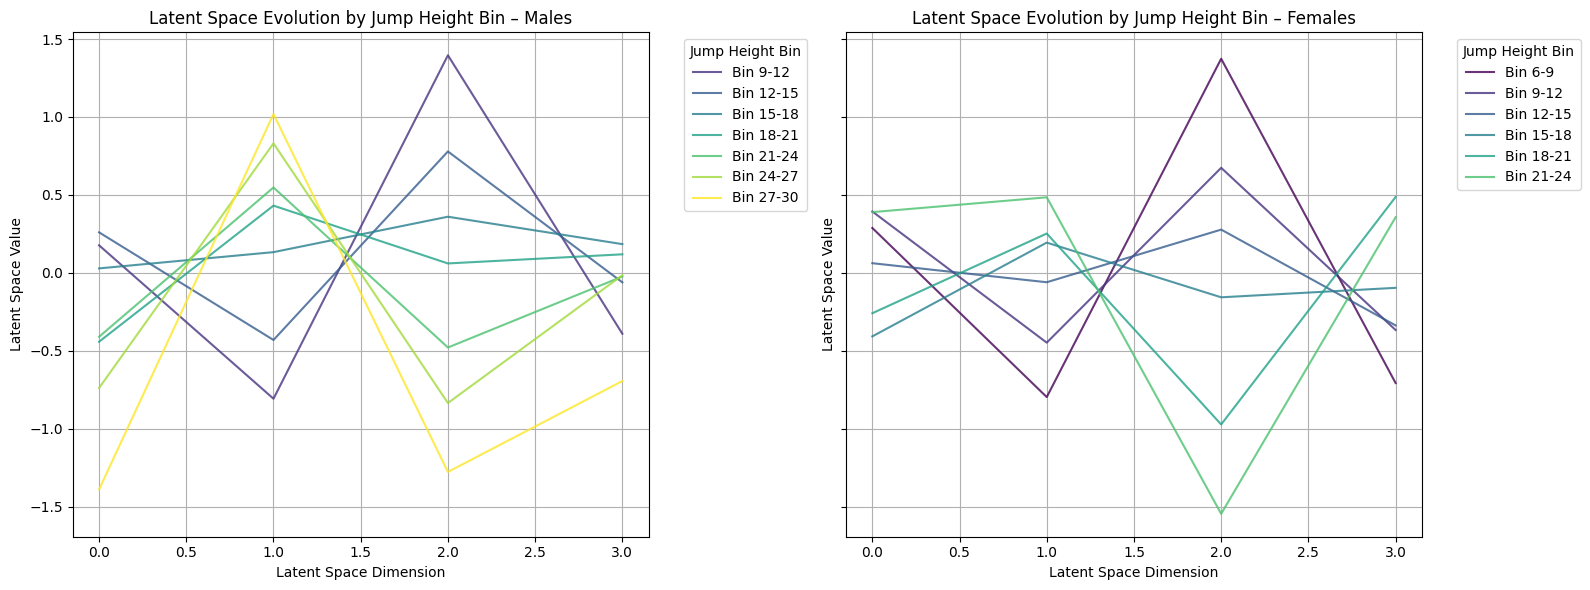

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_latent_space_by_gender(binned_males, binned_females, bin_labels, vae, MIN_SAMPLES=10, MAX_SAMPLES=120):
    fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # Define a color map
    cmap = cm.get_cmap("viridis", len(bin_labels))  # Choose a color map (you can try "Set2", "tab20", etc.)
    bin_color_map = {label: cmap(i) for i, label in enumerate(bin_labels)}

    for ax, gender_df, gender_label in zip(axs, [binned_males, binned_females], ["Males", "Females"]):
        print(f"\n=== {gender_label} ===")
        
        # Loop through each bin and plot latent space evolution
        for label in bin_labels:
            group = gender_df[gender_df["jump_bin"] == label]
            n_samples = group.shape[0]

            if n_samples < MIN_SAMPLES:
                print(f"Skipping bin {label} (only {n_samples} samples)")
                continue

            # Sample from each bin
            group_sample = group.sample(n=min(MAX_SAMPLES, n_samples), random_state=42)

            try:
                # Extract latent vectors for the samples
                latent_matrix = np.stack(group_sample["vae_latent_space_4d"].values)
                
                # Calculate the mean latent vector for each bin
                latent_mean = latent_matrix.mean(axis=0)
                
                # Plot the mean latent vector for the bin
                ax.plot(latent_mean, label=f'Bin {label}', alpha=0.8, color=bin_color_map[label])
                
                print(f"Bin {label}: {n_samples} samples")
            except Exception as e:
                print(f"Skipping plot for bin {label} due to error: {e}")
                continue

        # Add labels, title, and grid to the subplot
        ax.set_title(f"Latent Space Evolution by Jump Height Bin – {gender_label}")
        ax.set_xlabel("Latent Space Dimension")
        ax.set_ylabel("Latent Space Value")
        ax.legend(title="Jump Height Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True)

    plt.tight_layout()
    plt.show()

# Example usage
plot_latent_space_by_gender(binned_males, binned_females, bin_labels, vae)


In [101]:
# import matplotlib.pyplot as plt

# # Create a plot to visualize the evolution of latent vectors
# fig, ax = plt.subplots(figsize=(10, 6))

# # Plot each bin's mean latent vector
# for bin_label in bin_labels:
#     ax.plot(mean_latents[bin_label], label=f"Bin {bin_label}", marker='o')

# # Customize the plot
# ax.set_title("Mean Latent Vector Evolution Across Jump Height Bins")
# ax.set_xlabel("Latent Space Dimension")
# ax.set_ylabel("Latent Space Value")
# ax.legend(title="Jump Height Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
# ax.grid(True)

# plt.tight_layout()
# plt.show()


In [102]:
# when caculating an improvement in jump height, does the predicted jump curve match the curve being shown for the ideal shape of the higher bin?

# 1. You have an athlete in the 12-15 bin (say they jump 14 inches)
# 2. If you plot their jump improved by 2 inches
# 3. Does their new shape start to match the average shape for the higher bin?
# 4. Maybe look at differences between latent vector before and after prediction change, to see if there is less varation relative to the mean of the higher jump bin


In [103]:
binned_males.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2,outlier,vae_latent_space_4d,reconstructed_waveform,adjusted_reconstruction,predicted_takeoff_velocity,latent_predicted_jump_height,avg_diff_recon_vs_downsampled,avg_magnitude_downsampled,diff_ratio,jump_bin
1438,0,0,adaee8b6-4ae7-4292-b7f4-8c1491cfb54c,1,b2cf3cb0-ec27-4a6a-b65c-0f0e86650797,2023-11-02 22:04:03.724000+00:00,Baseball,Sport,NaN,NaN,421.539954,35.34,35.828,35.532,35.678,17.514109,35.34,22.977109,22.176691,0.69,58.361826,56.314473,56.328765,108.007,result\nPOSITIVE_IMPULSE 845.683491\nPOSITI...,6433.102659,180.127,result\nLANDING_RFD 375447.617\nLANDING_RFD...,2.543,986.282,-0.143,108.007,result\nPEAK_LANDING_FORCE 10512.533271\nPE...,29926.697,0.838,117.813888,result\nLANDING_IMPULSE 89.352932\nLANDING_...,46380.0,result\nMEAN_ECCENTRIC_FORCE 880.741434\nME...,744.683532,8.345663,104.00544,result\nECCENTRIC_BRAKING_IMPULSE 71.46482...,1118.821861,1895.809587,result\nECC

When the latent vector is optimized to achieve a higher jump, does the reconstructed force curve from the new latent vector:

- look more like the average (idealized) curve of the next bin,

- in both shape and scale, rather than just producing a taller jump?

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/scipy/optimize/_optimize.py:353: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "



Jump ID: 5743491d-af1f-47fb-8838-252a96696964, Date: 2024-12-28 20:21:48.544000+00:00
Predicted Original Height: 18.29 inches
Target Prescribed Height: 22.29 inches
Predicted Prescribed Height: 22.29 inches
Latent change magnitude: 0.6194

Latent Dimension Comparison:
Dim      Original         New    Δ (New - Orig)
1          0.2095     -0.0937           -0.3032
2          0.4077      0.9437            0.5359
3         -0.0651     -0.1200           -0.0548
4         -0.8380     -0.8002            0.0379

--- Quantitative Similarity to Higher Bin ---
Metric                  Original    Prescribed   Improved?
RMSE                      0.1521        0.1320         YES
Pearson Corr.             0.9894        0.9912         YES
Current Bin: 18-21
Higher Bin: 21-24


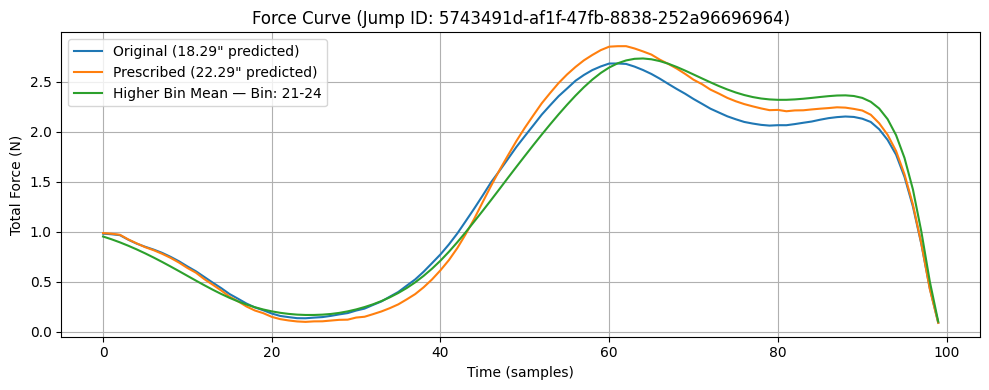

In [104]:
from scipy.optimize import basinhopping
from scipy.stats import pearsonr

def prescribe_jump_improvement(profileID, model_df, vae, top_n=1, delta=1.0):
    vae.eval()
    athlete_df = model_df[model_df["profileID"] == profileID].copy()
    
    if athlete_df.empty:
        print(f"No data found for profileID: {profileID}")
        return

    top_jumps = athlete_df.sort_values("recordedUTC", ascending=False).head(top_n)

    for idx, row in top_jumps.iterrows():
        latent_vec = np.array(row["vae_latent_space_4d"])
        jump_duration = row["jump_duration_s"]
        initial_val = row["initial_value"]
        jump_date = row["recordedUTC"]
        actual_recorded_height = row["JUMP_HEIGHT_INCHES"]

        if initial_val < 1e-3:
            print(f"[SKIP] initial_val too small ({initial_val})")
            continue
        if jump_duration > 2.0 or jump_duration <= 0:
            print(f"[SKIP] suspicious jump_duration ({jump_duration:.3f}s)")
            continue

        def predict_height(z):
            with torch.no_grad():
                z_tensor = torch.tensor(z, dtype=torch.float32).unsqueeze(0)
                rec = vae.decode(z_tensor).squeeze().cpu().numpy()

            rec = np.clip(rec, 0, 5)
            offset = rec[0] * (20 / initial_val)
            adjusted = rec - offset
            net_force = adjusted - 1.0
            avg_net_force = np.mean(net_force)
            takeoff_velocity = avg_net_force * jump_duration * 9.81
            height = (takeoff_velocity ** 2) / (2 * 9.81) * 39.37
            return height

        predicted_orig_height = predict_height(latent_vec)
        target_jump_height = predicted_orig_height + delta

        def objective(z_new):
            pred = predict_height(z_new)
            penalty = max(0, target_jump_height - pred) ** 2
            return np.sum((z_new - latent_vec) ** 2) + 10 * penalty

        def constraint(z_new):
            return predict_height(z_new) - target_jump_height
        
        def min_latent_shift(z_new):
            return np.linalg.norm(z_new - latent_vec) - epsilon
        
        epsilon = 0.05

        constraints = [
            {'type': 'ineq', 'fun': constraint},           
            {'type': 'ineq', 'fun': min_latent_shift},     
        ]

        bounds = [(val - 2.0, val + 2.0) for val in latent_vec]

        minimizer_kwargs = {
            "method": "SLSQP",
            "bounds": bounds,
            "constraints": constraints
        }

        result = basinhopping(objective, x0=latent_vec, minimizer_kwargs=minimizer_kwargs, niter=100)

        z_new = result.x
        predicted_new_height = predict_height(z_new)

        print("\n" + "=" * 60)
        print(f"Jump ID: {row['profileID']}, Date: {jump_date}")
        print(f"Predicted Original Height: {predicted_orig_height:.2f} inches")
        print(f"Target Prescribed Height: {target_jump_height:.2f} inches")
        print(f"Predicted Prescribed Height: {predicted_new_height:.2f} inches")
        print(f"Latent change magnitude: {np.linalg.norm(z_new - latent_vec):.4f}")

        print(f"\nLatent Dimension Comparison:")
        print(f"{'Dim':<5}{'Original':>12}{'New':>12}{'Δ (New - Orig)':>18}")
        for i, (orig, new) in enumerate(zip(latent_vec, z_new)):
            print(f"{i+1:<5}{orig:>12.4f}{new:>12.4f}{(new - orig):>18.4f}")

        # Reconstruct from latent vectors
        with torch.no_grad():
            rec_orig = vae.decode(torch.tensor(latent_vec, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()
            rec_new = vae.decode(torch.tensor(z_new, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()

        offset_orig = rec_orig[0] * (20 / initial_val)
        offset_new = rec_new[0] * (20 / initial_val)
        adj_orig = rec_orig - offset_orig
        adj_new = rec_new - offset_new

        # Check bin logic
        def parse_bin_label(label):
            start, end = label.split('-')
            return float(start), float(end)

        unique_bins = model_df['jump_bin'].dropna().unique()
        bin_tuples = [(label, *parse_bin_label(label)) for label in unique_bins]
        bin_tuples.sort(key=lambda x: x[1])

        current_bin_label = None
        next_bin_label = None
        for i, (label, start, end) in enumerate(bin_tuples):
            if start <= predicted_orig_height < end:
                current_bin_label = label
                if i + 1 < len(bin_tuples):
                    next_bin_label = bin_tuples[i + 1][0]
                break


        higher_bin_latents = model_df[model_df['JUMP_HEIGHT_INCHES'] > actual_recorded_height]
        if next_bin_label:
            higher_bin_latents = higher_bin_latents[higher_bin_latents['jump_bin'] == next_bin_label]

        if not higher_bin_latents.empty:
            top10_higher_bin = higher_bin_latents.sort_values("JUMP_HEIGHT_INCHES", ascending=False).head(10)

            if 'downsampled_time_series' in higher_bin_latents.columns:
                downsampled_arrays = np.stack(higher_bin_latents['downsampled_time_series'].values)
                avg_downsampled_ts = np.mean(downsampled_arrays, axis=0)

                offset_higher_bin = avg_downsampled_ts[0] * (20 / initial_val)
                adj_higher_bin = avg_downsampled_ts - offset_higher_bin
                rmse_orig = np.sqrt(np.mean((adj_orig - adj_higher_bin) ** 2))
                rmse_new = np.sqrt(np.mean((adj_new - adj_higher_bin) ** 2))

                corr_orig, _ = pearsonr(adj_orig, adj_higher_bin)
                corr_new, _ = pearsonr(adj_new, adj_higher_bin)

                print("\n--- Quantitative Similarity to Higher Bin ---")
                print(f"{'Metric':<20}{'Original':>12}{'Prescribed':>14}{'Improved?':>12}")
                print(f"{'RMSE':<20}{rmse_orig:>12.4f}{rmse_new:>14.4f}{'YES' if rmse_new < rmse_orig else 'NO':>12}")
                print(f"{'Pearson Corr.':<20}{corr_orig:>12.4f}{corr_new:>14.4f}{'YES' if corr_new > corr_orig else 'NO':>12}")
            else:
                print("No 'downsampled_time_series' column found in higher bin data.")
                continue

            print(f"Current Bin: {current_bin_label}")
            print(f"Higher Bin: {next_bin_label}")

            plt.figure(figsize=(10, 4))
            plt.plot(adj_orig, label=f"Original ({predicted_orig_height:.2f}\" predicted)")
            plt.plot(adj_new, label=f"Prescribed ({predicted_new_height:.2f}\" predicted)")
            plt.plot(adj_higher_bin, label=f"Higher Bin Mean — Bin: {next_bin_label}")
            plt.title(f"Force Curve (Jump ID: {row['profileID']})")
            plt.xlabel("Time (samples)")
            plt.ylabel("Total Force (N)")
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No higher bin data found for the jump height range.")



prescribe_jump_improvement(profileID="5743491d-af1f-47fb-8838-252a96696964", model_df=binned_males, top_n=1, vae=vae, delta=4)


In [105]:
def check_convergence_to_higher_bin(model_df, vae, delta=1.0):
    vae.eval()
    results = []

    for profileID in model_df['profileID'].unique():
        athlete_df = model_df[model_df["profileID"] == profileID].copy()
        if athlete_df.empty:
            continue

        top_jumps = athlete_df.sort_values("recordedUTC", ascending=False).head(1)

        for idx, row in top_jumps.iterrows():
            latent_vec = np.array(row["vae_latent_space_4d"])
            jump_duration = row["jump_duration_s"]
            initial_val = row["initial_value"]
            actual_recorded_height = row["JUMP_HEIGHT_INCHES"]

            if initial_val < 1e-3 or jump_duration > 2.0 or jump_duration <= 0:
                continue

            target_jump_height = actual_recorded_height + delta

            def predict_height(z):
                with torch.no_grad():
                    z_tensor = torch.tensor(z, dtype=torch.float32).unsqueeze(0)
                    rec = vae.decode(z_tensor).squeeze().cpu().numpy()

                rec = np.clip(rec, 0, 5)
                offset = rec[0] * (20 / initial_val)
                adjusted = rec - offset
                net_force = adjusted - 1.0
                avg_net_force = np.mean(net_force)
                takeoff_velocity = avg_net_force * jump_duration * 9.81
                height = (takeoff_velocity ** 2) / (2 * 9.81) * 39.37
                return height

            def objective(z_new):
                pred = predict_height(z_new)
                penalty = max(0, target_jump_height - pred) ** 2
                return np.sum((z_new - latent_vec) ** 2) + 10 * penalty

            def constraint(z_new):
                return predict_height(z_new) - target_jump_height

            def min_latent_shift(z_new):
                return np.linalg.norm(z_new - latent_vec) - epsilon

            epsilon = 0.05
            constraints = [
                {'type': 'ineq', 'fun': constraint},
                {'type': 'ineq', 'fun': min_latent_shift},
            ]

            bounds = [(val - 2.0, val + 2.0) for val in latent_vec]

            from scipy.optimize import basinhopping
            minimizer_kwargs = {
                "method": "SLSQP",
                "bounds": bounds,
                "constraints": {'type': 'ineq', 'fun': constraint}
            }

            result = basinhopping(objective, latent_vec, minimizer_kwargs=minimizer_kwargs, niter=100)

            z_new = result.x
            predicted_new_height = predict_height(z_new)

            def parse_bin_label(label):
                start, end = label.split('-')
                return float(start), float(end)

            unique_bins = model_df['jump_bin'].dropna().unique()
            bin_tuples = [(label, *parse_bin_label(label)) for label in unique_bins]
            bin_tuples.sort(key=lambda x: x[1])  # sort by bin start

            current_bin_label = None
            next_bin_label = None
            for i, (label, start, end) in enumerate(bin_tuples):
                if start <= actual_recorded_height < end:
                    current_bin_label = label
                if start <= predicted_new_height < end:
                    if label != current_bin_label:
                        next_bin_label = label
                    break

            if next_bin_label:
                higher_bin_latents = model_df[model_df['jump_bin'] == next_bin_label]

                if not higher_bin_latents.empty:
                    top10_higher_bin = higher_bin_latents.sort_values("JUMP_HEIGHT_INCHES", ascending=False).head(10)
                    higher_bin_mean_latent = np.mean(np.stack(top10_higher_bin['vae_latent_space_4d'].values), axis=0)

                    if 'downsampled_time_series' in higher_bin_latents.columns:
                        downsampled_arrays = np.stack(higher_bin_latents['downsampled_time_series'].values)
                        avg_downsampled_ts = np.mean(downsampled_arrays, axis=0)

                        offset_higher_bin = avg_downsampled_ts[0] * (20 / initial_val)
                        adj_higher_bin = avg_downsampled_ts - offset_higher_bin

                        rec_new = vae.decode(torch.tensor(z_new, dtype=torch.float32).unsqueeze(0)).squeeze().detach().cpu().numpy()
                        rec_new = np.clip(rec_new, 0, 5)
                        offset_new = rec_new[0] * (20 / initial_val)
                        adj_new = rec_new - offset_new

                        rec_orig = vae.decode(torch.tensor(latent_vec, dtype=torch.float32).unsqueeze(0)).squeeze().detach().cpu().numpy()
                        rec_orig = np.clip(rec_orig, 0, 5)
                        offset_orig = rec_orig[0] * (20 / initial_val)
                        adj_orig = rec_orig - offset_orig

                        rmse_orig = np.sqrt(np.mean((adj_orig - adj_higher_bin) ** 2))
                        rmse_new = np.sqrt(np.mean((adj_new - adj_higher_bin) ** 2))

                        from scipy.stats import pearsonr
                        corr_orig, _ = pearsonr(adj_orig, adj_higher_bin)
                        corr_new, _ = pearsonr(adj_new, adj_higher_bin)

                        athlete_result = {
                            'athlete_id': profileID,
                            'predicted_jump_height': predicted_new_height,
                            'actual_jump_height': actual_recorded_height,
                            'rmse_orig': rmse_orig,
                            'rmse_new': rmse_new,
                            'corr_orig': corr_orig,
                            'corr_new': corr_new,
                            'higher_bin': next_bin_label
                        }

                        results.append(athlete_result)

    return pd.DataFrame(results)


In [106]:
sample_profileIDs = binned_males['profileID'].sample(n=1, random_state=42)

sampled_model_df = binned_males[binned_males['profileID'].isin(sample_profileIDs)]

results_df = check_convergence_to_higher_bin(model_df=sampled_model_df, vae=vae, delta=4.0)
print(results_df)


Empty DataFrame
Columns: []
Index: []


In [107]:
def summarize_convergence(results_df):
    if results_df.empty:
        print("No athletes processed.")
        return

    converged = results_df[
        (results_df['rmse_new'] < results_df['rmse_orig']) &
        (results_df['corr_new'] > results_df['corr_orig'])
    ]

    total = len(results_df)
    num_converged = len(converged)
    num_not_converged = total - num_converged

    percent_converged = (num_converged / total) * 100 if total > 0 else 0

    print(f"Total athletes analyzed: {total}")
    print(f"Athletes that converged to higher bin pattern: {num_converged} ({percent_converged:.1f}%)")
    print(f"Athletes that did NOT converge: {num_not_converged} ({100 - percent_converged:.1f}%)")

    return converged, results_df[~results_df.index.isin(converged.index)]


In [108]:
converged_df, not_converged_df = summarize_convergence(results_df)


No athletes processed.


TypeError: cannot unpack non-iterable NoneType object

In [ ]:
# prescribe_jump_improvement('ff218290-61dd-44fa-98ec-1db80d58a01d', binned_males, vae, delta=4.0)

In [109]:
from scipy.optimize import minimize
from scipy.stats import pearsonr

def prescribe_jump_improvement(profileID, model_df, vae, top_n=1, delta=1.0):
    vae.eval()
    athlete_df = model_df[model_df["profileID"] == profileID].copy()
    
    if athlete_df.empty:
        print(f"No data found for profileID: {profileID}")
        return

    top_jumps = athlete_df.sort_values("recordedUTC", ascending=False).head(top_n)

    for idx, row in top_jumps.iterrows():
        latent_vec = np.array(row["vae_latent_space_4d"])
        jump_height = row["JUMP_HEIGHT_INCHES"]
        target_jump_height = jump_height + delta
        jump_duration = row["jump_duration_s"]
        initial_val = row["initial_value"]
        jump_date = row["recordedUTC"]
        tv_jump_height_row = row["tv_jump_height"]
        dst = row["adjusted_reconstruction"]

        if initial_val < 1e-3:
            print(f"[SKIP] initial_val too small ({initial_val})")
            continue
        if jump_duration > 2.0 or jump_duration <= 0:
            print(f"[SKIP] suspicious jump_duration ({jump_duration:.3f}s)")
            continue

        def predict_height(z):
            with torch.no_grad():
                z_tensor = torch.tensor(z, dtype=torch.float32).unsqueeze(0)
                rec = vae.decode(z_tensor).squeeze().cpu().numpy()

            rec = np.clip(rec, 0, 5)
            offset = rec[0] * (20 / initial_val)
            adjusted = rec - offset
            net_force = adjusted - 1.0
            avg_net_force = np.mean(net_force)
            takeoff_velocity = avg_net_force * jump_duration * 9.81
            height = (takeoff_velocity ** 2) / (2 * 9.81) * 39.37
            return height

        def objective(z_new):
            return np.sum((z_new - latent_vec) ** 2)

        def constraint(z_new):
            return predict_height(z_new) - target_jump_height

        def min_latent_shift(z_new):
            return np.linalg.norm(z_new - latent_vec) - epsilon

        epsilon = 0.05

        constraints = [
            {'type': 'ineq', 'fun': constraint},
            {'type': 'ineq', 'fun': min_latent_shift},
        ]

        bounds = [(val - 2.0, val + 2.0) for val in latent_vec]

        result = minimize(
            objective,
            x0=latent_vec,
            method='SLSQP',
            constraints=constraints,
            bounds=bounds,
            options={'maxiter': 1000, 'disp': True}
        )

        # Reconstruct curves
        with torch.no_grad():
            rec_orig = vae.decode(torch.tensor(latent_vec, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()
            rec_new = vae.decode(torch.tensor(result.x, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()

        offset_orig = rec_orig[0] * (20 / initial_val)
        offset_new = rec_new[0] * (20 / initial_val)
        adj_orig = rec_orig - offset_orig
        adj_new = rec_new - offset_new

        vae_pred_height_orig = predict_height(latent_vec)
        vae_pred_height_new = predict_height(result.x)

        print("\n" + "=" * 60)
        print(f"Jump ID: {row['profileID']}, Date: {jump_date}")
        print(f"{'Recorded Height':<30}: {jump_height:.2f} inches")
        print(f"{'TV-derived Height from Raw Curve':<30}: {tv_jump_height_row:.2f} inches" if tv_jump_height_row is not None else "TV-derived Height: N/A")
        print(f"{'Height from VAE (Original)':<30}: {vae_pred_height_orig:.2f} inches")
        print(f"{'Height from VAE (Prescribed)':<30}: {vae_pred_height_new:.2f} inches")

        if result.success or result.status in [8, 9]:
            z_new = result.x
            print(f"\nOptimization succeeded.")
            print(f"Latent change magnitude: {np.linalg.norm(z_new - latent_vec):.4f}")
            print(f"\nLatent Dimension Comparison:")
            print(f"{'Dim':<5}{'Original':>12}{'New':>12}{'Δ (New - Orig)':>18}")
            for i, (orig, new) in enumerate(zip(latent_vec, z_new)):
                print(f"{i+1:<5}{orig:>12.4f}{new:>12.4f}{(new - orig):>18.4f}")

            # Bin analysis
            def parse_bin_label(label):
                if '+' in label:
                    start = float(label.replace('+', ''))
                    return (start, float('inf'))
                start, end = map(float, label.split('-'))
                return (start, end)

            unique_bins = model_df['jump_bin'].dropna().unique()
            bin_tuples = [(label, *parse_bin_label(label)) for label in unique_bins]
            bin_tuples.sort(key=lambda x: x[1])

            current_bin_label = None
            next_bin_label = None
            for i, (label, start, end) in enumerate(bin_tuples):
                if start <= jump_height < end:
                    current_bin_label = label
                    if i + 1 < len(bin_tuples):
                        next_bin_label = bin_tuples[i + 1][0]
                    break

            higher_bin_latents = model_df[model_df['JUMP_HEIGHT_INCHES'] > jump_height]
            if next_bin_label:
                higher_bin_latents = higher_bin_latents[higher_bin_latents['jump_bin'] == next_bin_label]

            if not higher_bin_latents.empty:
                top10_higher_bin = higher_bin_latents.sort_values("JUMP_HEIGHT_INCHES", ascending=False).head(10)
                higher_bin_mean_latent = np.mean(np.stack(top10_higher_bin['vae_latent_space_4d'].values), axis=0)

                if 'downsampled_time_series' in higher_bin_latents.columns:
                    downsampled_arrays = np.stack(higher_bin_latents['downsampled_time_series'].values)
                    avg_downsampled_ts = np.mean(downsampled_arrays, axis=0)

                    offset_higher_bin = avg_downsampled_ts[0] * (20 / initial_val)
                    adj_higher_bin = avg_downsampled_ts - offset_higher_bin
                    rmse_orig = np.sqrt(np.mean((adj_orig - adj_higher_bin) ** 2))
                    rmse_new = np.sqrt(np.mean((adj_new - adj_higher_bin) ** 2))
                    corr_orig, _ = pearsonr(adj_orig, adj_higher_bin)
                    corr_new, _ = pearsonr(adj_new, adj_higher_bin)

                    print("\n--- Quantitative Similarity to Higher Bin ---")
                    print(f"{'Metric':<20}{'Original':>12}{'Prescribed':>14}{'Improved?':>12}")
                    print(f"{'RMSE':<20}{rmse_orig:>12.4f}{rmse_new:>14.4f}{'YES' if rmse_new < rmse_orig else 'NO':>12}")
                    print(f"{'Pearson Corr.':<20}{corr_orig:>12.4f}{corr_new:>14.4f}{'YES' if corr_new > corr_orig else 'NO':>12}")
                else:
                    print("No 'downsampled_time_series' column found in higher bin data.")
                    continue

                print(f"Current Bin: {current_bin_label}")
                print(f"Higher Bin: {next_bin_label}")

                plt.figure(figsize=(10, 4))
                plt.plot(dst, label=f"Original Raw Curve ({tv_jump_height_row:.2f}\" in)", linestyle="dotted", alpha=0.7, linewidth=2.5)
                plt.plot(adj_orig, label=f"VAE Reconstructed (Orig) ({vae_pred_height_orig:.2f}\" in)")
                plt.plot(adj_new, label=f"Prescribed ({vae_pred_height_new:.2f}\" in)")
                plt.plot(adj_higher_bin, label=f"Higher Bin Mean — Bin: {next_bin_label}")
                plt.title(f"Force Curve (Jump ID: {row['profileID']})")
                plt.xlabel("Time (samples)")
                plt.ylabel("Total Force (N)")
                plt.grid(True)
                plt.legend()
                plt.tight_layout()
                plt.show()

            else:
                print("No higher bin data found for the jump height range.")
        else:
            print("Optimization failed.")
            print(result.message)


In [110]:
testing_testing = binned_males[binned_males["profileID"] == '1c1770d7-ff83-425c-94e4-27247bec8662']
testing_testing = testing_testing.sort_values("recordedUTC", ascending=False).head(1)

In [111]:
testing_testing

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2,outlier,vae_latent_space_4d,reconstructed_waveform,adjusted_reconstruction,predicted_takeoff_velocity,latent_predicted_jump_height,avg_diff_recon_vs_downsampled,avg_magnitude_downsampled,diff_ratio,jump_bin
1624,142,142,fc195506-8b02-4a56-99cb-8210b4585640,1,1c1770d7-ff83-425c-94e4-27247bec8662,2023-02-26 19:14:22.105000+00:00,Baseball,Sport,NaN,NaN,418.423757,36.972,37.466,37.184,37.34,17.504618,36.972,15.242979,14.907694,0.562,38.717145,37.842681,37.865523,53.102,result\nPOSITIVE_IMPULSE 699.674238\nPOSITI...,2865.524225,143.276,result\nLANDING_RFD 110944.916\nLANDING_RFD...,2.742,681.173,-0.077,53.102,result\nPEAK_LANDING_FORCE 5547.245779\nPEA...,13211.597,0.903,62.908208,result\nLANDING_IMPULSE 87.302289\nLANDING_...,110600.0,result\nMEAN_ECCENTRIC_FORCE 864.717553\nME...,571.45042,6.480499,87.265088,result\nECCENTRIC_BRAKING_IMPULSE 59.77769...,1078.879581,1765.058279,result\n

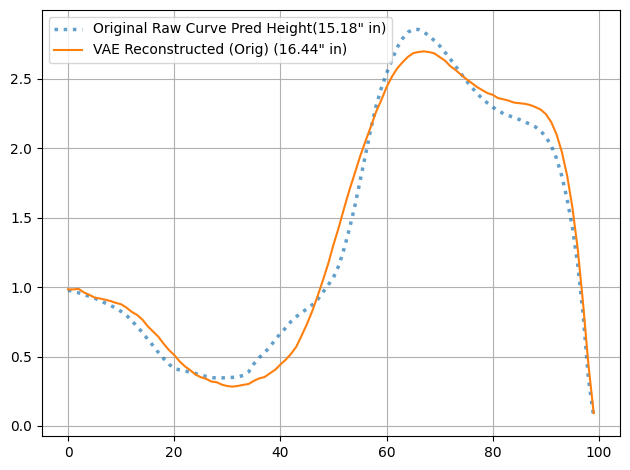

JUMP_HEIGHT_INCHES: 15.24297851962704


In [112]:
test_og_jump_latent = testing_testing["vae_latent_space_4d"].iloc[0]
test_og_dst = testing_testing["downsampled_time_series"].iloc[0]
test_init_val = testing_testing["initial_value"].iloc[0]
test_pred_height = testing_testing["tv_jump_height"].iloc[0]
actual_jh = testing_testing["JUMP_HEIGHT_INCHES"].iloc[0]
vae_pred = testing_testing["latent_predicted_jump_height"].iloc[0]

with torch.no_grad():
    rec_orig = vae.decode(torch.tensor(test_og_jump_latent, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()

offset_orig = rec_orig[0] * (20 / test_init_val)
adj_orig = rec_orig - offset_orig
        
        
# prescribe_jump_improvement('ff218290-61dd-44fa-98ec-1db80d58a01d', binned_males, vae, delta=4.0)

plt.plot(test_og_dst, label=f"Original Raw Curve Pred Height({test_pred_height:.2f}\" in)", linestyle="dotted", alpha=0.7, linewidth=2.5)
plt.plot(adj_orig, label=f"VAE Reconstructed (Orig) ({vae_pred:.2f}\" in)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
print(f"JUMP_HEIGHT_INCHES: {actual_jh}")


In [113]:
cleaned_df = binned_males.dropna(subset=["latent_predicted_jump_height", "tv_jump_height", "JUMP_HEIGHT_INCHES", "jump_bin"])

cleaned_df["vae_abs_error"] = (cleaned_df["latent_predicted_jump_height"] - cleaned_df["JUMP_HEIGHT_INCHES_IMP_MOM"]).abs()
cleaned_df["tv_abs_error"] = (cleaned_df["tv_jump_height"] - cleaned_df["JUMP_HEIGHT_INCHES_IMP_MOM"]).abs()

error_summary = cleaned_df.groupby("jump_bin")[["vae_abs_error", "tv_abs_error"]].mean().sort_index()

overall_vae_error = cleaned_df["vae_abs_error"].mean()
overall_tv_error = cleaned_df["tv_abs_error"].mean()

print("Average Absolute Error by Jump Bin:")
print(error_summary)
print("\nOverall Avg Absolute Error for Jump Height predicted by reconstruction:", round(overall_vae_error, 2), "inches")
print("Overall Avg Absolute Error for Jump Height predicted by time series:", round(overall_tv_error, 2), "inches")


Average Absolute Error by Jump Bin:
          vae_abs_error  tv_abs_error
jump_bin                             
6-9            4.988006      0.628750
9-12           3.260947      0.382279
12-15          2.394859      0.465720
15-18          1.641374      0.567271
18-21          1.446572      0.663766
21-24          1.437378      0.799495
24-27          1.697483      0.907768
27-30          2.563245      0.747434

Overall Avg Absolute Error for Jump Height predicted by reconstruction: 1.61 inches
Overall Avg Absolute Error for Jump Height predicted by time series: 0.65 inches


In [114]:
def analyze_latent_convergence(binned_df, vae, delta=2.0):
    vae.eval()
    results = []

    # Pre-compute bin mean latents
    def parse_bin_label(label):
        if '+' in label:
            start = float(label.replace('+', ''))
            return (start, float('inf'))
        start, end = map(float, label.split('-'))
        return (start, end)

    unique_bins = binned_df['jump_bin'].dropna().unique()
    bin_tuples = [(label, *parse_bin_label(label)) for label in unique_bins]
    bin_tuples.sort(key=lambda x: x[1])
    
    # Debug: Print the unique bins and bin_tuples
    print("Available bins:", unique_bins)
    print("Sorted bin tuples:", bin_tuples)
    
    bin_latent_means = {
        label: np.mean(np.stack(group['vae_latent_space_4d'].values), axis=0)
        for label, group in binned_df.groupby('jump_bin') if not group.empty
    }

    # Debug: Check the computed latent means for each bin
    print("Latent means for bins:", bin_latent_means.keys())

    for idx, row in binned_df.iterrows():
        if 'vae_latent_space_4d' not in row or row['vae_latent_space_4d'] is None:
            continue

        latent_vec = np.array(row['vae_latent_space_4d'])
        jump_height = row["JUMP_HEIGHT_INCHES"]
        target_jump_height = jump_height + delta
        jump_duration = row["jump_duration_s"]
        initial_val = row["initial_value"]
        current_bin = row["jump_bin"]

        if initial_val < 1e-3 or jump_duration > 2.0 or jump_duration <= 0 or pd.isna(current_bin):
            continue

        # Find the next bin
        next_bin = None
        for i, (label, start, end) in enumerate(bin_tuples):
            if label == current_bin and i + 1 < len(bin_tuples):
                next_bin = bin_tuples[i + 1][0]
                print(f"Current Bin: {current_bin}, Next Bin: {next_bin}")  # Debug print
                break

        if next_bin not in bin_latent_means or current_bin not in bin_latent_means:
            continue

        def predict_height(z):
            with torch.no_grad():
                z_tensor = torch.tensor(z, dtype=torch.float32).unsqueeze(0)
                rec = vae.decode(z_tensor).squeeze().cpu().numpy()

            rec = np.clip(rec, 0, 5)
            offset = rec[0] * (20 / initial_val)
            adjusted = rec - offset
            net_force = adjusted - 1.0
            avg_net_force = np.mean(net_force)
            takeoff_velocity = avg_net_force * jump_duration * 9.81
            height = (takeoff_velocity ** 2) / (2 * 9.81) * 39.37
            return height

        def objective(z_new):
            return np.sum((z_new - latent_vec) ** 2)

        def constraint(z_new):
            return predict_height(z_new) - target_jump_height

        def min_latent_shift(z_new):
            return np.linalg.norm(z_new - latent_vec) - 0.05

        constraints = [
            {'type': 'ineq', 'fun': constraint},
            {'type': 'ineq', 'fun': min_latent_shift}
        ]
        bounds = [(val - 2.0, val + 2.0) for val in latent_vec]

        result = minimize(
            objective,
            x0=latent_vec,
            method='SLSQP',
            constraints=constraints,
            bounds=bounds,
            options={'maxiter': 1000, 'disp': False}
        )

        if not result.success:
            continue

        z_new = result.x

        # Compute distances
        orig_to_next = np.linalg.norm(latent_vec - bin_latent_means[next_bin])
        new_to_next = np.linalg.norm(z_new - bin_latent_means[next_bin])
        orig_to_curr = np.linalg.norm(latent_vec - bin_latent_means[current_bin])
        new_to_curr = np.linalg.norm(z_new - bin_latent_means[current_bin])

        results.append({
            "current_bin": current_bin,
            "next_bin": next_bin,
            "orig_to_next": orig_to_next,
            "new_to_next": new_to_next,
            "orig_to_curr": orig_to_curr,
            "new_to_curr": new_to_curr,
            "converged": new_to_next < orig_to_next
        })

    # Aggregate
    results_df = pd.DataFrame(results)
    summary = results_df.groupby("current_bin").agg({
        "orig_to_next": "mean",
        "new_to_next": "mean",
        "orig_to_curr": "mean",
        "new_to_curr": "mean",
        "converged": "mean"
    }).rename(columns={"converged": "fraction_converged"})

    print(summary)
    return results_df, summary


# Sample 5 items from each bin and pass to analysis
eligible_bins = binned_males["jump_bin"].value_counts()
eligible_bins = eligible_bins[eligible_bins >= 5].index

filtered = binned_males[binned_males["jump_bin"].isin(eligible_bins)]

# Debug: Check available bins after filtering
print("Filtered bins:", filtered['jump_bin'].unique())

# Sample 5 items from each bin
subset_binned_males = pd.concat([
    group.sample(n=5, random_state=42)
    for _, group in filtered.groupby('jump_bin')
    if len(group) >= 5
])

# Now run the analysis
results_df, summary_df = analyze_latent_convergence(subset_binned_males, vae, delta=2.0)


Filtered bins: ['21-24', '24-27', '18-21', '12-15', '15-18', '27-30', '9-12']
Categories (8, object): ['6-9' < '9-12' < '12-15' < '15-18' < '18-21' < '21-24' < '24-27' < '27-30']
Available bins: ['9-12', '12-15', '15-18', '18-21', '21-24', '24-27', '27-30']
Categories (8, object): ['6-9' < '9-12' < '12-15' < '15-18' < '18-21' < '21-24' < '24-27' < '27-30']
Sorted bin tuples: [('9-12', 9.0, 12.0), ('12-15', 12.0, 15.0), ('15-18', 15.0, 18.0), ('18-21', 18.0, 21.0), ('21-24', 21.0, 24.0), ('24-27', 24.0, 27.0), ('27-30', 27.0, 30.0)]
Latent means for bins: dict_keys(['9-12', '12-15', '15-18', '18-21', '21-24', '24-27', '27-30'])
Current Bin: 9-12, Next Bin: 12-15
Current Bin: 9-12, Next Bin: 12-15
Current Bin: 9-12, Next Bin: 12-15
Current Bin: 9-12, Next Bin: 12-15
Current Bin: 9-12, Next Bin: 12-15
Current Bin: 12-15, Next Bin: 15-18
Current Bin: 12-15, Next Bin: 15-18
Current Bin: 12-15, Next Bin: 15-18
Current Bin: 12-15, Next Bin: 15-18
Current Bin: 12-15, Next Bin: 15-18
Current Bi

In [115]:
eligible_bins = binned_males["jump_bin"].value_counts()
eligible_bins = eligible_bins[eligible_bins >= 5].index

filtered = binned_males[binned_males["jump_bin"].isin(eligible_bins)]



In [116]:
subset_binned_males = filtered.sample(n=20, random_state=42)

results_df, summary_df = analyze_latent_convergence(subset_binned_males, vae, delta=2.0)


Available bins: ['15-18', '12-15', '18-21', '21-24']
Categories (8, object): ['6-9' < '9-12' < '12-15' < '15-18' < '18-21' < '21-24' < '24-27' < '27-30']
Sorted bin tuples: [('12-15', 12.0, 15.0), ('15-18', 15.0, 18.0), ('18-21', 18.0, 21.0), ('21-24', 21.0, 24.0)]
Latent means for bins: dict_keys(['12-15', '15-18', '18-21', '21-24'])
Current Bin: 15-18, Next Bin: 18-21
Current Bin: 12-15, Next Bin: 15-18
Current Bin: 18-21, Next Bin: 21-24
Current Bin: 18-21, Next Bin: 21-24
Current Bin: 18-21, Next Bin: 21-24
Current Bin: 12-15, Next Bin: 15-18
Current Bin: 18-21, Next Bin: 21-24
Current Bin: 15-18, Next Bin: 18-21
Current Bin: 15-18, Next Bin: 18-21
Current Bin: 18-21, Next Bin: 21-24
Current Bin: 18-21, Next Bin: 21-24
Current Bin: 15-18, Next Bin: 18-21
Current Bin: 18-21, Next Bin: 21-24
Current Bin: 18-21, Next Bin: 21-24
Current Bin: 15-18, Next Bin: 18-21
Current Bin: 15-18, Next Bin: 18-21
Current Bin: 18-21, Next Bin: 21-24
Current Bin: 15-18, Next Bin: 18-21
Current Bin: 12

In [ ]:
summary_df

In [117]:
# Compute mean absolute difference for each row
def waveform_diff(row):
    return np.mean(np.abs(np.array(row["adjusted_reconstruction"]) - np.array(row["downsampled_time_series"])))

cleaned_df["bin_recon_diff"] = cleaned_df.apply(waveform_diff, axis=1)

# Group by jump bin and compute average per-bin error
error_summary = cleaned_df.groupby("jump_bin")["bin_recon_diff"].mean().sort_index()

# Overall mean reconstruction difference
overall_recon_diff = cleaned_df["bin_recon_diff"].mean()

print(error_summary)
print("\nOverall Mean Reconstruction Difference:", overall_recon_diff)


jump_bin
6-9      0.097054
9-12     0.077106
12-15    0.078610
15-18    0.069653
18-21    0.070464
21-24    0.071116
24-27    0.076319
27-30    0.092955
Name: bin_recon_diff, dtype: float64

Overall Mean Reconstruction Difference: 0.07137075388563549


In [118]:
sample_athletes = binned_males['profileID'].dropna().unique()[:10]  # or .sample(n=10) if randomized
results = []
print(sample_athletes)
for pid in sample_athletes:
    res = prescribe_and_measure_convergence(pid, binned_males, vae, delta=2.0)
    print(pid)
    if res:  # Avoid None returns
        print(f"Original Height for {pid}: {res['JUMP_HEIGHT_INCHES']}")  # Print the original height
        results.append(res)

df_results = pd.DataFrame(results)


['b2cf3cb0-ec27-4a6a-b65c-0f0e86650797'
 'a9e7d07b-0d02-467b-9969-188f76395365'
 'ff218290-61dd-44fa-98ec-1db80d58a01d'
 '5101d3c9-b2b9-4554-bcf4-1e3343a211b5'
 'b41d7fcf-8123-467a-a3ec-25e78bd0566c'
 '1c1770d7-ff83-425c-94e4-27247bec8662'
 '657cdaf4-e31f-4003-a48b-287f51ec7149'
 'b9015d87-02ad-4c66-9c53-299824a14436'
 '035ec4c0-c3fd-4fe3-999a-2a45ae562f09'
 '8d654c0c-7070-4f9f-9eff-2b1fc12be9e2']


NameError: name 'prescribe_and_measure_convergence' is not defined

In [ ]:
df_results

Positive directional derivative for linesearch    (Exit mode 8)
            Current function value: 0.0
            Iterations: 5
            Function evaluations: 5
            Gradient evaluations: 1

Jump ID: 657cdaf4-e31f-4003-a48b-287f51ec7149, Date: 2024-02-06 21:29:34.778000+00:00
Recorded Height               : 17.96 inches
TV-derived Height from Raw Curve: 14.10 inches
Height from VAE (Original)    : 14.88 inches
Height from VAE (Prescribed)  : 14.88 inches

Optimization succeeded.
Latent change magnitude: 0.0000

Latent Dimension Comparison:
Dim      Original         New    Δ (New - Orig)
1          1.3929      1.3929            0.0000
2         -0.0070     -0.0070            0.0000
3          0.1348      0.1348            0.0000
4          0.2539      0.2539            0.0000

--- Quantitative Similarity to Higher Bin ---
Metric                  Original    Prescribed   Improved?
RMSE                      0.3334        0.3334          NO
Pearson Corr.             0.9285     

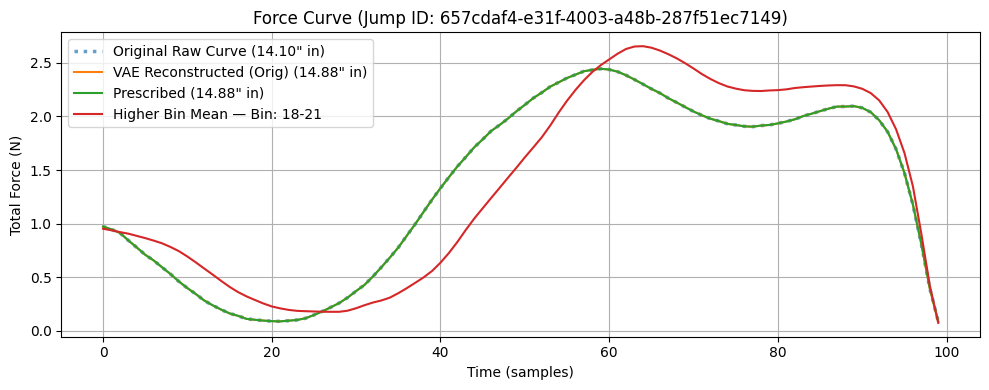

TypeError: 'NoneType' object is not iterable

In [119]:

# subset_binned_males = model_df[model_df['JUMP_HEIGHT_INCHES'] >= 24]  

# OR you could randomly sample 10 athletes for testing
subset_binned_males = binned_males.sample(n=10, random_state=42)

# Apply the function to all profiles in the subset
all_results_subset = []

# Iterate through all athlete profiles in the subset
for profileID in subset_binned_males['profileID'].unique():
    results = prescribe_jump_improvement(profileID=profileID, model_df=subset_binned_males, vae=vae, delta=1.0)
    all_results_subset.extend(results)


subset_binned_males = pd.DataFrame(all_results_subset)

# Now aggregate and analyze by bin transition
# Create new columns for 'original_bin' and 'prescribed_bin' based on 'original_height' and 'prescribed_height'
subset_binned_males['original_bin'] = pd.cut(subset_binned_males['JUMP_HEIGHT_INCHES'], 
                                            bins=[12, 15, 18, 21, 24, 27, 30], 
                                            labels=['12-15', '15-18', '18-21', '21-24', '24-27', '27-30'])

subset_binned_males['prescribed_bin'] = pd.cut(subset_binned_males['prescribed_height'], 
                                              bins=[12, 15, 18, 21, 24, 27, 30], 
                                              labels=['12-15', '15-18', '18-21', '21-24', '24-27', '27-30'])


# Group by 'original_bin' and analyze improvements
summary_stats_subset = subset_binned_males.groupby(['original_bin', 'prescribed_bin']).agg({
    'rmse_orig': ['mean', 'std'],
    'rmse_new': ['mean', 'std'],
    'corr_orig': ['mean', 'std'],
    'corr_new': ['mean', 'std'],
    'latent_change_magnitude': ['mean', 'std']
})

# Show summary stats for each transition
print(summary_stats_subset)


In [ ]:
# results_df_subset

In [ ]:
# binned_males["jump_bin"].unique()

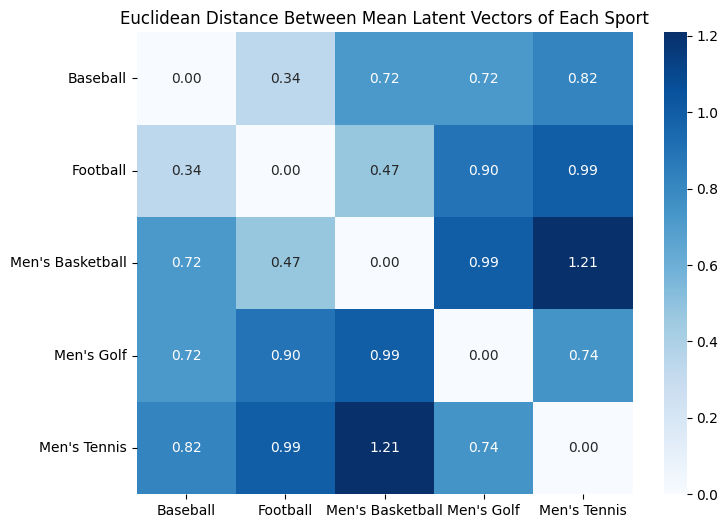

In [120]:
from scipy.spatial.distance import cdist

mean_latents_by_sport = binned_males.groupby('Team')['vae_latent_space_4d'].apply(lambda x: np.mean(np.stack(x), axis=0))
latent_means = np.stack(mean_latents_by_sport.values)
sports_names = mean_latents_by_sport.index

distances = cdist(latent_means, latent_means, metric='euclidean')

plt.figure(figsize=(8, 6))
sns.heatmap(distances, annot=True, xticklabels=sports_names, yticklabels=sports_names, cmap="Blues", fmt=".2f")
plt.title("Euclidean Distance Between Mean Latent Vectors of Each Sport")
plt.show()


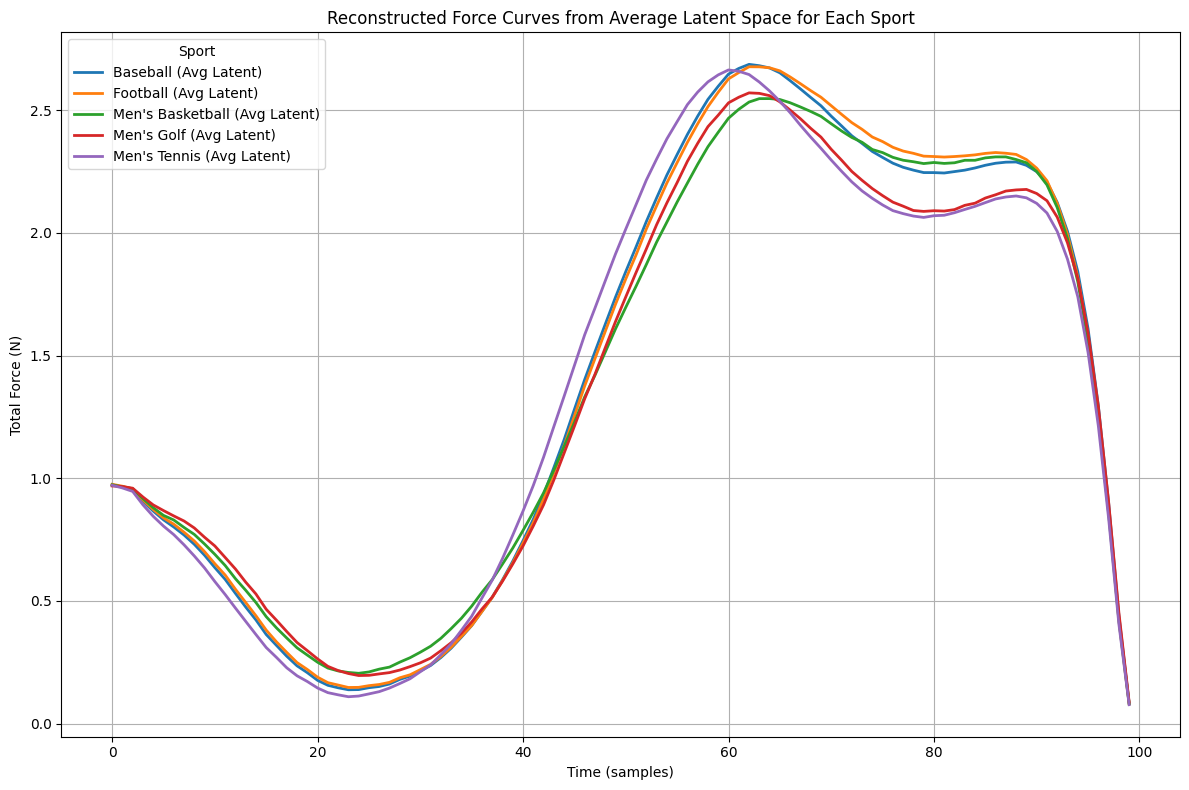

In [121]:
mean_latents_by_sport = binned_males.groupby('Team')['vae_latent_space_4d'].apply(lambda x: np.mean(np.stack(x), axis=0))

plt.figure(figsize=(12, 8))

for sport, avg_latent in mean_latents_by_sport.items():
    with torch.no_grad():
        avg_latent_tensor = torch.tensor(avg_latent, dtype=torch.float32).unsqueeze(0)
        reconstructed_profile = vae.decode(avg_latent_tensor).squeeze().cpu().numpy()

    initial_val = binned_males[binned_males['Team'] == sport]['initial_value'].mean()  # Average initial value for that sport
    offset = reconstructed_profile[0] * (20 / initial_val)
    adjusted_reconstruction = reconstructed_profile - offset

    plt.plot(adjusted_reconstruction, label=f"{sport} (Avg Latent)", linewidth=2)

plt.title("Reconstructed Force Curves from Average Latent Space for Each Sport")
plt.xlabel("Time (samples)")
plt.ylabel("Total Force (N)")
plt.legend(title="Sport", loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()


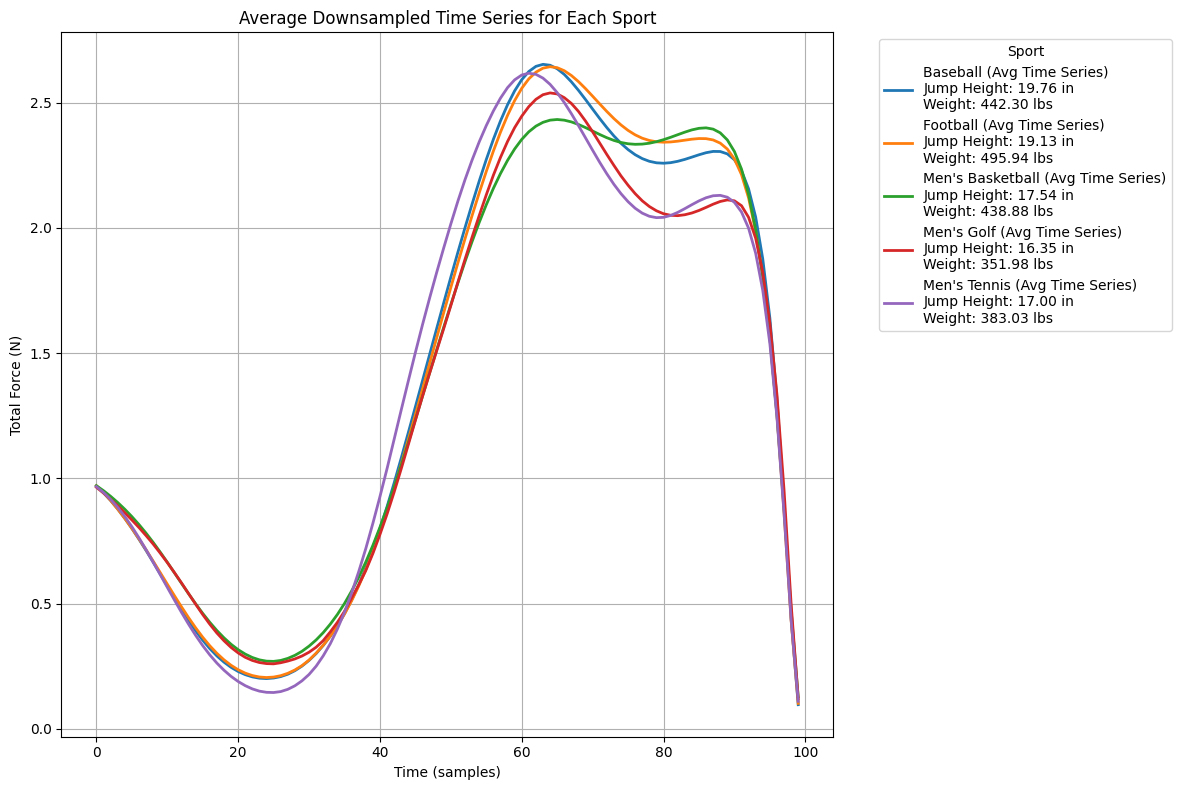

In [122]:
mean_time_series_by_sport = binned_males.groupby('Team')['downsampled_time_series'].apply(lambda x: np.mean(np.stack(x), axis=0))

avg_jump_height_by_sport = binned_males.groupby('Team')['JUMP_HEIGHT_INCHES'].mean()
avg_body_weight_by_sport = binned_males.groupby('Team')['BODY_WEIGHT_LBS'].mean()

plt.figure(figsize=(12, 8))

for sport, avg_time_series in mean_time_series_by_sport.items():
    label = f"{sport} (Avg Time Series)\nJump Height: {avg_jump_height_by_sport[sport]:.2f} in\nWeight: {avg_body_weight_by_sport[sport]:.2f} lbs"
    plt.plot(avg_time_series, label=label, linewidth=2)

plt.title("Average Downsampled Time Series for Each Sport")
plt.xlabel("Time (samples)")
plt.ylabel("Total Force (N)")
plt.legend(title="Sport", loc="best", bbox_to_anchor=(1.05, 1))  
plt.grid(True)
plt.tight_layout()
plt.show()


In [123]:
binned_males.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2,outlier,vae_latent_space_4d,reconstructed_waveform,adjusted_reconstruction,predicted_takeoff_velocity,latent_predicted_jump_height,avg_diff_recon_vs_downsampled,avg_magnitude_downsampled,diff_ratio,jump_bin
1438,0,0,adaee8b6-4ae7-4292-b7f4-8c1491cfb54c,1,b2cf3cb0-ec27-4a6a-b65c-0f0e86650797,2023-11-02 22:04:03.724000+00:00,Baseball,Sport,NaN,NaN,421.539954,35.34,35.828,35.532,35.678,17.514109,35.34,22.977109,22.176691,0.69,58.361826,56.314473,56.328765,108.007,result\nPOSITIVE_IMPULSE 845.683491\nPOSITI...,6433.102659,180.127,result\nLANDING_RFD 375447.617\nLANDING_RFD...,2.543,986.282,-0.143,108.007,result\nPEAK_LANDING_FORCE 10512.533271\nPE...,29926.697,0.838,117.813888,result\nLANDING_IMPULSE 89.352932\nLANDING_...,46380.0,result\nMEAN_ECCENTRIC_FORCE 880.741434\nME...,744.683532,8.345663,104.00544,result\nECCENTRIC_BRAKING_IMPULSE 71.46482...,1118.821861,1895.809587,result\nECC

In [124]:
latent_spaces_by_sport = {}
latent_spaces_by_jump_bin = {}

for idx, row in binned_males.iterrows():
    downsampled_series = torch.tensor(row['downsampled_time_series'], dtype=torch.float32).unsqueeze(0)
    
    with torch.no_grad():
        latent_vector, _ = vae.encode(downsampled_series)  # Get the mean latent vector (first element of tuple)
    
    team = row['Team']
    if team not in latent_spaces_by_sport:
        latent_spaces_by_sport[team] = []
    latent_spaces_by_sport[team].append(latent_vector.numpy())
    
    jump_bin = row['jump_bin']
    if jump_bin not in latent_spaces_by_jump_bin:
        latent_spaces_by_jump_bin[jump_bin] = []
    latent_spaces_by_jump_bin[jump_bin].append(latent_vector.numpy())

avg_latent_by_sport = {team: np.mean(np.stack(latents), axis=0) for team, latents in latent_spaces_by_sport.items()}

avg_latent_by_jump_bin = {jump_bin: np.mean(np.stack(latents), axis=0) for jump_bin, latents in latent_spaces_by_jump_bin.items()}

print("Average 4D Latent Space for Each Sport:")
for team, latent in avg_latent_by_sport.items():
    print(f"\n{team}:")
    print(latent)

print("\nAverage 4D Latent Space for Each Jump Bin:")
for jump_bin, latent in avg_latent_by_jump_bin.items():
    print(f"\nJump Bin {jump_bin}:")
    print(latent)


Average 4D Latent Space for Each Sport:

Baseball:
[[-0.17293942  0.43198547 -0.17555879 -0.02868625]]

Football:
[[-0.29548     0.40543923  0.08700435  0.14599374]]

Men's Basketball:
[[-0.31261018 -0.00243638  0.29987487  0.25997055]]

Men's Golf:
[[-0.12505162  0.02535152 -0.12269482 -0.6185405 ]]

Men's Tennis:
[[ 0.42778075  0.47990647  0.05904932 -0.5299373 ]]

Average 4D Latent Space for Each Jump Bin:

Jump Bin 21-24:
[[-0.38929573  0.57641274 -0.5031004   0.06350018]]

Jump Bin 24-27:
[[-0.7030773   0.83029616 -0.7815319   0.13249287]]

Jump Bin 18-21:
[[-0.27618372  0.48403618 -0.02023071  0.04157021]]

Jump Bin 12-15:
[[ 0.19123153 -0.31016374  0.7631367  -0.04603787]]

Jump Bin 15-18:
[[-0.0441638   0.12723269  0.34733075  0.13059045]]

Jump Bin 27-30:
[[-1.3900998   1.0187677  -1.2773868  -0.69426936]]

Jump Bin 9-12:
[[ 0.19006795 -0.76542926  1.3668511  -0.3759796 ]]

Jump Bin 6-9:
[[ 0.8310127 -1.0260394  1.8895689  1.0050907]]


In [125]:
from scipy.spatial.distance import cdist

avg_latent_by_sport = {
    'Baseball': [-0.15625776, 0.37653005, -0.18326129, -0.04487184],
    'Football': [-0.23230135, 0.29284334, 0.07589606, 0.10311289],
    "Men's Basketball": [-0.23838186, -0.11244985, 0.2531849, 0.19798689],
    "Men's Golf": [-0.12505162, 0.02535152, -0.12269482, -0.6185405],
    "Men's Tennis": [0.44390717, 0.45091265, 0.04891233, -0.530785]
}

avg_latent_by_jump_bin = {
    'Jump Bin 20-23': [-0.6557598, 0.42449096, -0.62845325, 0.13278036],
    'Jump Bin 17-20': [-0.32355046, 0.3738866, -0.26427102, 0.04653623],
    'Jump Bin 14-17': [-0.04065289, 0.28962705, 0.17714396, 0.03713875],
    'Jump Bin 11-14': [0.19564995, -0.13892071, 0.5520209, -0.11171892],
    'Jump Bin 8-11': [0.32906654, -0.5395174, 1.1322579, -0.302678],
    'Jump Bin 23-26': [-0.9278594, 0.22901642, -0.8264271, 0.14302464],
    'Jump Bin 5-8': [0.06980399, -0.6029944, 2.2277896, -0.8970035],
    'Jump Bin 26-29': [-1.1574382, -1.4694041, 1.0596313, 0.5146785]
}

sport_latent_spaces = np.array(list(avg_latent_by_sport.values()))
jump_bin_latent_spaces = np.array(list(avg_latent_by_jump_bin.values()))

distances = {}
for i, sport in enumerate(avg_latent_by_sport.keys()):
    dist_to_bins = cdist([sport_latent_spaces[i]], jump_bin_latent_spaces, metric='euclidean')
    closest_jump_bin_index = np.argmin(dist_to_bins)
    closest_jump_bin = list(avg_latent_by_jump_bin.keys())[closest_jump_bin_index]
    distances[sport] = closest_jump_bin

print("\nClosest Jump Bin for Each Sport:")
for sport, closest_jump_bin in distances.items():
    print(f"{sport} -> Closest Jump Bin: {closest_jump_bin}")



Closest Jump Bin for Each Sport:
Baseball -> Closest Jump Bin: Jump Bin 17-20
Football -> Closest Jump Bin: Jump Bin 14-17
Men's Basketball -> Closest Jump Bin: Jump Bin 14-17
Men's Golf -> Closest Jump Bin: Jump Bin 14-17
Men's Tennis -> Closest Jump Bin: Jump Bin 14-17


In [126]:
binned_males.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2,outlier,vae_latent_space_4d,reconstructed_waveform,adjusted_reconstruction,predicted_takeoff_velocity,latent_predicted_jump_height,avg_diff_recon_vs_downsampled,avg_magnitude_downsampled,diff_ratio,jump_bin
1438,0,0,adaee8b6-4ae7-4292-b7f4-8c1491cfb54c,1,b2cf3cb0-ec27-4a6a-b65c-0f0e86650797,2023-11-02 22:04:03.724000+00:00,Baseball,Sport,NaN,NaN,421.539954,35.34,35.828,35.532,35.678,17.514109,35.34,22.977109,22.176691,0.69,58.361826,56.314473,56.328765,108.007,result\nPOSITIVE_IMPULSE 845.683491\nPOSITI...,6433.102659,180.127,result\nLANDING_RFD 375447.617\nLANDING_RFD...,2.543,986.282,-0.143,108.007,result\nPEAK_LANDING_FORCE 10512.533271\nPE...,29926.697,0.838,117.813888,result\nLANDING_IMPULSE 89.352932\nLANDING_...,46380.0,result\nMEAN_ECCENTRIC_FORCE 880.741434\nME...,744.683532,8.345663,104.00544,result\nECCENTRIC_BRAKING_IMPULSE 71.46482...,1118.821861,1895.809587,result\nECC

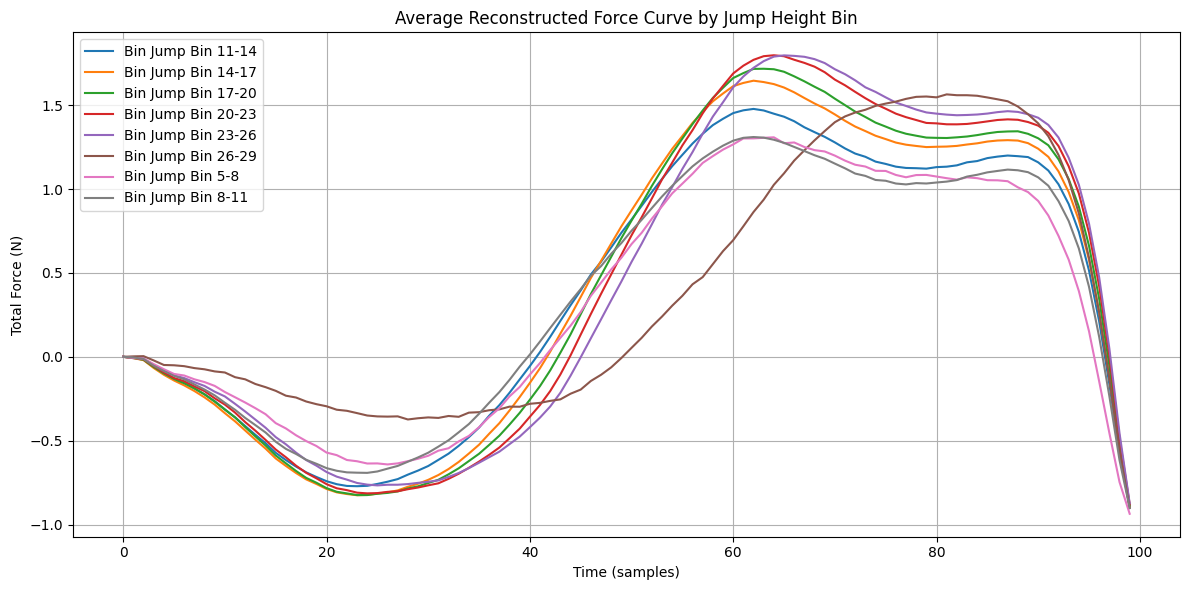

In [127]:
def plot_avg_reconstruction_by_jump_bin(avg_latent_by_jump_bin, vae, initial_val=20.0):
    plt.figure(figsize=(12, 6))

    for jump_bin, latent_vec in sorted(avg_latent_by_jump_bin.items()):
        with torch.no_grad():
            z_tensor = torch.tensor(latent_vec, dtype=torch.float32).unsqueeze(0)
            rec = vae.decode(z_tensor).squeeze().cpu().numpy()

        # Apply offset adjustment
        offset = rec[0] * (20 / initial_val)
        adjusted = rec - offset

        plt.plot(adjusted, label=f"Bin {jump_bin}")

    plt.title("Average Reconstructed Force Curve by Jump Height Bin")
    plt.xlabel("Time (samples)")
    plt.ylabel("Total Force (N)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Try again
plot_avg_reconstruction_by_jump_bin(avg_latent_by_jump_bin, vae, initial_val=20.0)


In [128]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2,outlier,vae_latent_space_4d,reconstructed_waveform,adjusted_reconstruction,predicted_takeoff_velocity,latent_predicted_jump_height,avg_diff_recon_vs_downsampled,avg_magnitude_downsampled,diff_ratio
1438,0,0,adaee8b6-4ae7-4292-b7f4-8c1491cfb54c,1,b2cf3cb0-ec27-4a6a-b65c-0f0e86650797,2023-11-02 22:04:03.724000+00:00,Baseball,Sport,NaN,NaN,421.539954,35.34,35.828,35.532,35.678,17.514109,35.34,22.977109,22.176691,0.69,58.361826,56.314473,56.328765,108.007,result\nPOSITIVE_IMPULSE 845.683491\nPOSITI...,6433.102659,180.127,result\nLANDING_RFD 375447.617\nLANDING_RFD...,2.543,986.282,-0.143,108.007,result\nPEAK_LANDING_FORCE 10512.533271\nPE...,29926.697,0.838,117.813888,result\nLANDING_IMPULSE 89.352932\nLANDING_...,46380.0,result\nMEAN_ECCENTRIC_FORCE 880.741434\nME...,744.683532,8.345663,104.00544,result\nECCENTRIC_BRAKING_IMPULSE 71.46482...,1118.821861,1895.809587,result\nECCENTRIC_BR

In [129]:
percentiles = [0.25, 0.5, 0.75, 0.9]

team_percentiles = binned_males.groupby('Team')['JUMP_HEIGHT_INCHES'].quantile(percentiles).unstack()

team_percentiles.columns = [f"{int(p*100)}th Percentile" for p in percentiles]

print(team_percentiles)

                  25th Percentile  50th Percentile  75th Percentile  \
Team                                                                  
Baseball                18.312964        19.644391        21.278125   
Football                17.143115        19.276641        21.278125   
Men's Basketball        16.011874        17.606421        19.154830   
Men's Golf              13.454422        16.459737        18.611507   
Men's Tennis            15.570189        16.685985        18.671447   

                  90th Percentile  
Team                               
Baseball                22.711480  
Football                23.244283  
Men's Basketball        20.265028  
Men's Golf              21.073576  
Men's Tennis            20.140129  


In [130]:
# Set the target percentile value for each team
p75_baseball = binned_males[binned_males['Team'] == 'Baseball']['JUMP_HEIGHT_INCHES'].quantile(0.75)
p75_football = binned_males[binned_males['Team'] == 'Football']['JUMP_HEIGHT_INCHES'].quantile(0.75)

# Get Baseball athletes near the 75th percentile
baseball_near_p75 = binned_males[
    (binned_males['Team'] == 'Baseball') &
    (binned_males['JUMP_HEIGHT_INCHES'].between(p75_baseball - 0.01, p75_baseball + 0.01))
]

# Get Football athletes near the 75th percentile
football_near_p75 = binned_males[
    (binned_males['Team'] == 'Football') &
    (binned_males['JUMP_HEIGHT_INCHES'].between(p75_football - 0.01, p75_football + 0.01))
]

# Display results
print("Baseball near 75th percentile:")
display(baseball_near_p75[['profileID', 'JUMP_HEIGHT_INCHES']])

print("\nFootball near 75th percentile:")
display(football_near_p75[['profileID', 'JUMP_HEIGHT_INCHES']])


Baseball near 75th percentile:


,profileID,JUMP_HEIGHT_INCHES
1479,a9e7d07b-0d02-467b-9969-188f76395365,21.278125
1913,a0d304d4-8965-458b-bc86-2e0ef2f599d0,21.278125
2188,831de876-d251-4634-8407-331ddfeef4ab,21.278125
2309,45329ffb-6f7c-481e-a295-3df73d16c2fb,21.278125
2319,45329ffb-6f7c-481e-a295-3df73d16c2fb,21.278125
...,...,...
7561,3e67002b-0443-4a7b-bf29-e301aa8aa066,21.278125
7570,3e67002b-0443-4a7b-bf29-e301aa8aa066,21.278125
7572,3e67002b-0443-4a7b-bf29-e301aa8aa066,21.278125
7597,3e67002b-0443-4a7b-bf29-e301aa8aa066,21.278125



Football near 75th percentile:


,profileID,JUMP_HEIGHT_INCHES
8122,8a3b50dd-ea2b-4e44-8650-05f6d8a28a16,21.278125
8164,8a3b50dd-ea2b-4e44-8650-05f6d8a28a16,21.278125
8212,8a3b50dd-ea2b-4e44-8650-05f6d8a28a16,21.278125
8356,475db7f7-b88c-47bf-8f86-0b7a213e70af,21.278125
8446,475db7f7-b88c-47bf-8f86-0b7a213e70af,21.278125
...,...,...
20827,4d9e2b85-4119-472c-b787-fdd0ba7bdc6b,21.278125
20829,4d9e2b85-4119-472c-b787-fdd0ba7bdc6b,21.278125
20861,4d9e2b85-4119-472c-b787-fdd0ba7bdc6b,21.278125
20869,4d9e2b85-4119-472c-b787-fdd0ba7bdc6b,21.278125


In [81]:
binned_males.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space_consistency,reconstruction_loss,reconstruction,outlier,total_sessions,start_year,years_training,first_session_date,relative_session,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,initial_weight,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2,vae_latent_space_4d,reconstructed_waveform,adjusted_reconstruction,predicted_takeoff_velocity,latent_predicted_jump_height,avg_diff_recon_vs_downsampled,avg_magnitude_downsampled,diff_ratio,jump_bin
1438,0,0,adaee8b6-4ae7-4292-b7f4-8c1491cfb54c,1,b2cf3cb0-ec27-4a6a-b65c-0f0e86650797,2023-11-02 22:04:03.724000+00:00,Baseball,Sport,NaN,NaN,195.703714,35.34,35.828,35.532,35.678,17.514109,35.34,22.977109,22.176691,0.69,58.361826,56.314473,56.328765,108.007,result\nPOSITIVE_IMPULSE 845.683491\nPOSITI...,6433.102659,180.127,result\nLANDING_RFD 375447.617\nLANDING_RFD...,2.543,986.282,

### Performers by Sport

In [82]:
binned_males = binned_males.sort_values(by="JUMP_HEIGHT_INCHES")

high_performers = binned_males.groupby('Team').apply(lambda x: x.tail(int(len(x) * 0.1)))  # Top 10%
low_performers = binned_males.groupby('Team').apply(lambda x: x.head(int(len(x) * 0.1)))  # Bottom 10%

high_performers = high_performers.reset_index(drop=True)
low_performers = low_performers.reset_index(drop=True)
high_performer_latents = np.stack(high_performers['vae_latent_space_4d'].values)
low_performer_latents = np.stack(low_performers['vae_latent_space_4d'].values)


In [83]:
def reconstruct_jump(latent_vec, vae, initial_value):
    with torch.no_grad():
        z_tensor = torch.tensor(latent_vec, dtype=torch.float32).unsqueeze(0)
        rec = vae.decode(z_tensor).squeeze().cpu().numpy()

    rec = np.clip(rec, 0, 5)
    offset = rec[0] * (20 / initial_value)
    adjusted = rec - offset
    return adjusted

# Reconstruct jumps for high and low performers, accessing the row correctly
high_performers['reconstructed_jump'] = high_performers.apply(
    lambda row: reconstruct_jump(row['vae_latent_space_4d'], vae, row['initial_value']),
    axis=1
)

low_performers['reconstructed_jump'] = low_performers.apply(
    lambda row: reconstruct_jump(row['vae_latent_space_4d'], vae, row['initial_value']),
    axis=1
)


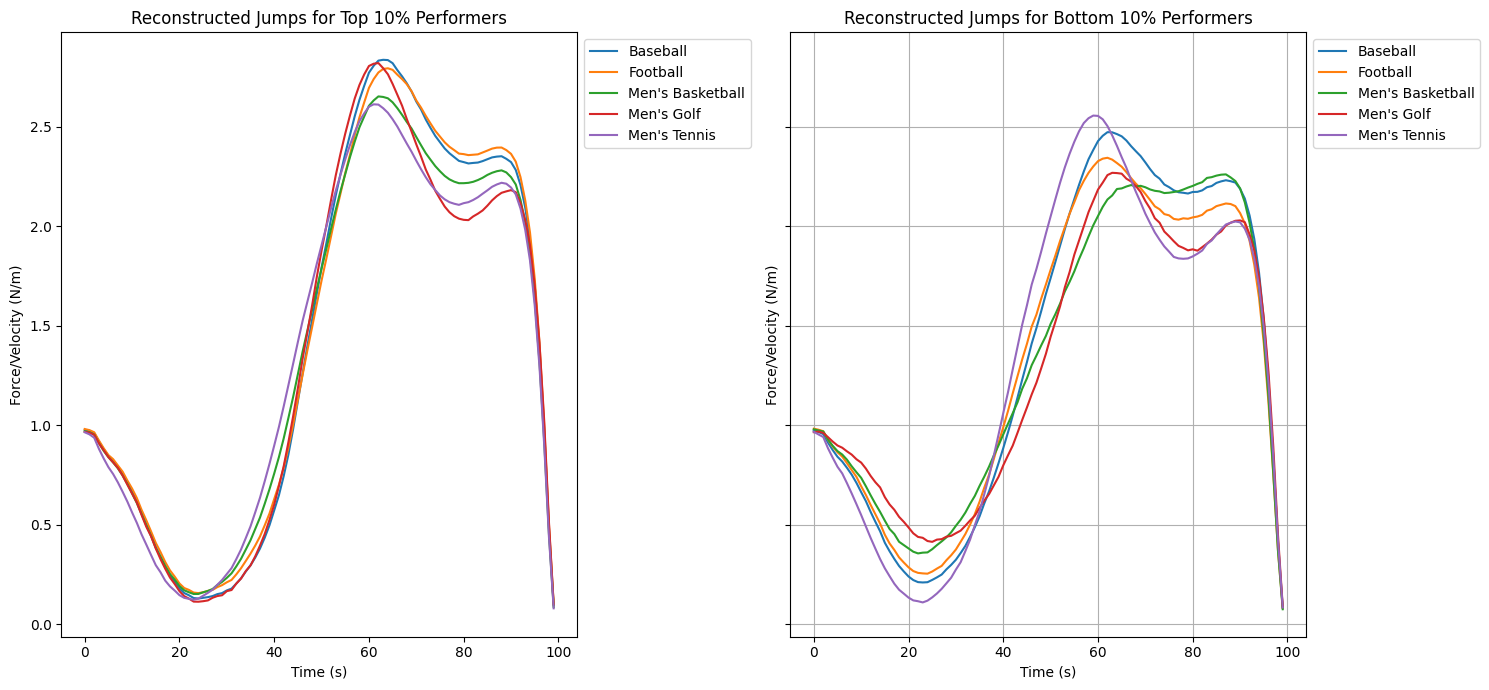

In [84]:
def reconstruct_jump(latent_vec, vae, initial_value):
    with torch.no_grad():
        z_tensor = torch.tensor(latent_vec, dtype=torch.float32).unsqueeze(0)
        rec = vae.decode(z_tensor).squeeze().cpu().numpy()

    rec = np.clip(rec, 0, 5)
    offset = rec[0] * (20 / initial_value)
    adjusted = rec - offset
    return adjusted

top_bottom_percentiles = binned_males.groupby('Team').apply(
    lambda x: {
        'top_10': x.nlargest(int(len(x) * 0.1), 'JUMP_HEIGHT_INCHES'),
        'bottom_10': x.nsmallest(int(len(x) * 0.1), 'JUMP_HEIGHT_INCHES')
    }
).apply(pd.Series)

def get_avg_latent_space(df):
    top_avg_latent = np.mean(np.stack(df['top_10']['vae_latent_space_4d'].values), axis=0)
    bottom_avg_latent = np.mean(np.stack(df['bottom_10']['vae_latent_space_4d'].values), axis=0)
    return top_avg_latent, bottom_avg_latent

avg_latent_vectors = top_bottom_percentiles.apply(get_avg_latent_space, axis=1)

reconstructed_top = []
reconstructed_bottom = []

for sport, (top_latent, bottom_latent) in avg_latent_vectors.items():
    sport_data = binned_males[binned_males['Team'] == sport]
    initial_value = sport_data['initial_value'].iloc[0]  # Assuming the initial_value is the same for all athletes in the sport
    
    reconstructed_top.append(reconstruct_jump(top_latent, vae, initial_value))
    reconstructed_bottom.append(reconstruct_jump(bottom_latent, vae, initial_value))

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True)

for i, sport in enumerate(avg_latent_vectors.index):
    axes[0].plot(reconstructed_top[i], label=sport)
axes[0].set_title("Reconstructed Jumps for Top 10% Performers")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Force/Velocity (N/m)")
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))

for i, sport in enumerate(avg_latent_vectors.index):
    axes[1].plot(reconstructed_bottom[i], label=sport)
axes[1].set_title("Reconstructed Jumps for Bottom 10% Performers")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Force/Velocity (N/m)")
axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)

plt.tight_layout()
plt.show()


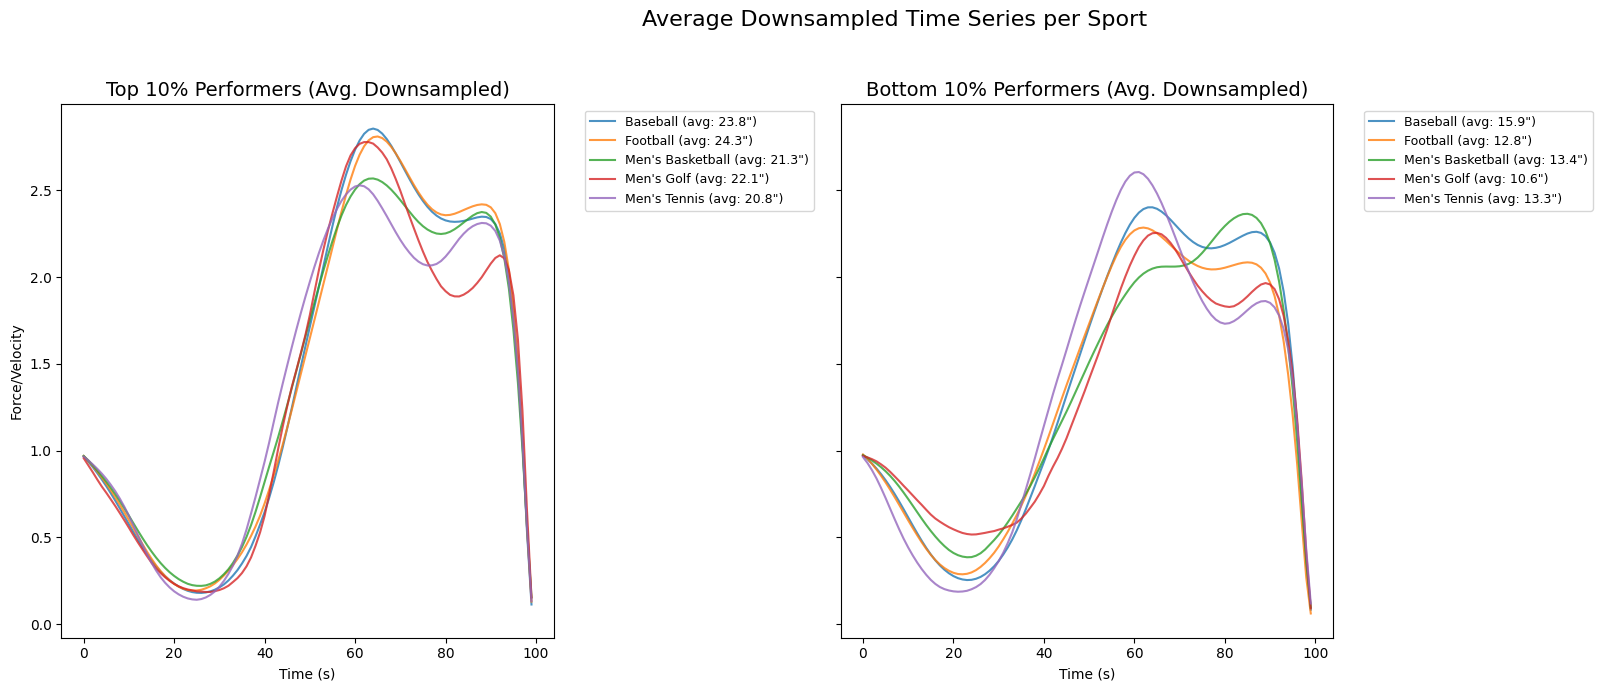

In [85]:
top_bottom = binned_males.groupby('Team').apply(
    lambda x: {
        'top_10': x.nlargest(int(len(x) * 0.1), 'JUMP_HEIGHT_INCHES'),
        'bottom_10': x.nsmallest(int(len(x) * 0.1), 'JUMP_HEIGHT_INCHES')
    }
).apply(pd.Series)

avg_top = {}
avg_bottom = {}

for sport in top_bottom.index:
    top_ts = np.stack(top_bottom.loc[sport, 'top_10']['downsampled_time_series'].values)
    bottom_ts = np.stack(top_bottom.loc[sport, 'bottom_10']['downsampled_time_series'].values)
    
    avg_top[sport] = np.mean(top_ts, axis=0)
    avg_bottom[sport] = np.mean(bottom_ts, axis=0)

fig, axes = plt.subplots(ncols=2, figsize=(18, 7), sharey=True)

for sport in avg_top:
    avg_jump = top_bottom.loc[sport, 'top_10']['JUMP_HEIGHT_INCHES'].mean()
    label = f"{sport} (avg: {avg_jump:.1f}\")"
    axes[0].plot(avg_top[sport], label=label, alpha=0.8)
axes[0].set_title("Top 10% Performers (Avg. Downsampled)", fontsize=14)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Force/Velocity")
axes[0].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=9)

for sport in avg_bottom:
    avg_jump = top_bottom.loc[sport, 'bottom_10']['JUMP_HEIGHT_INCHES'].mean()
    label = f"{sport} (avg: {avg_jump:.1f}\")"
    axes[1].plot(avg_bottom[sport], label=label, linestyle='-', alpha=0.8)
axes[1].set_title("Bottom 10% Performers (Avg. Downsampled)", fontsize=14)
axes[1].set_xlabel("Time (s)")
axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=9)

plt.suptitle("Average Downsampled Time Series per Sport", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


In [86]:
from scipy.spatial.distance import cdist

bin_latents = binned_males.groupby('jump_bin')['vae_latent_space_4d'].apply(
    lambda x: np.mean(np.stack(x), axis=0)
)

def closest_bin(latent_vec, bin_latents):
    bin_matrix = np.stack(bin_latents.values)
    distances = cdist([latent_vec], bin_matrix)[0]
    closest_idx = np.argmin(distances)
    return bin_latents.index[closest_idx]

closest_top_bins = {}
closest_bottom_bins = {}

for sport, (top_latent, bottom_latent) in avg_latent_vectors.items():
    closest_top_bins[sport] = closest_bin(top_latent, bin_latents)
    closest_bottom_bins[sport] = closest_bin(bottom_latent, bin_latents)


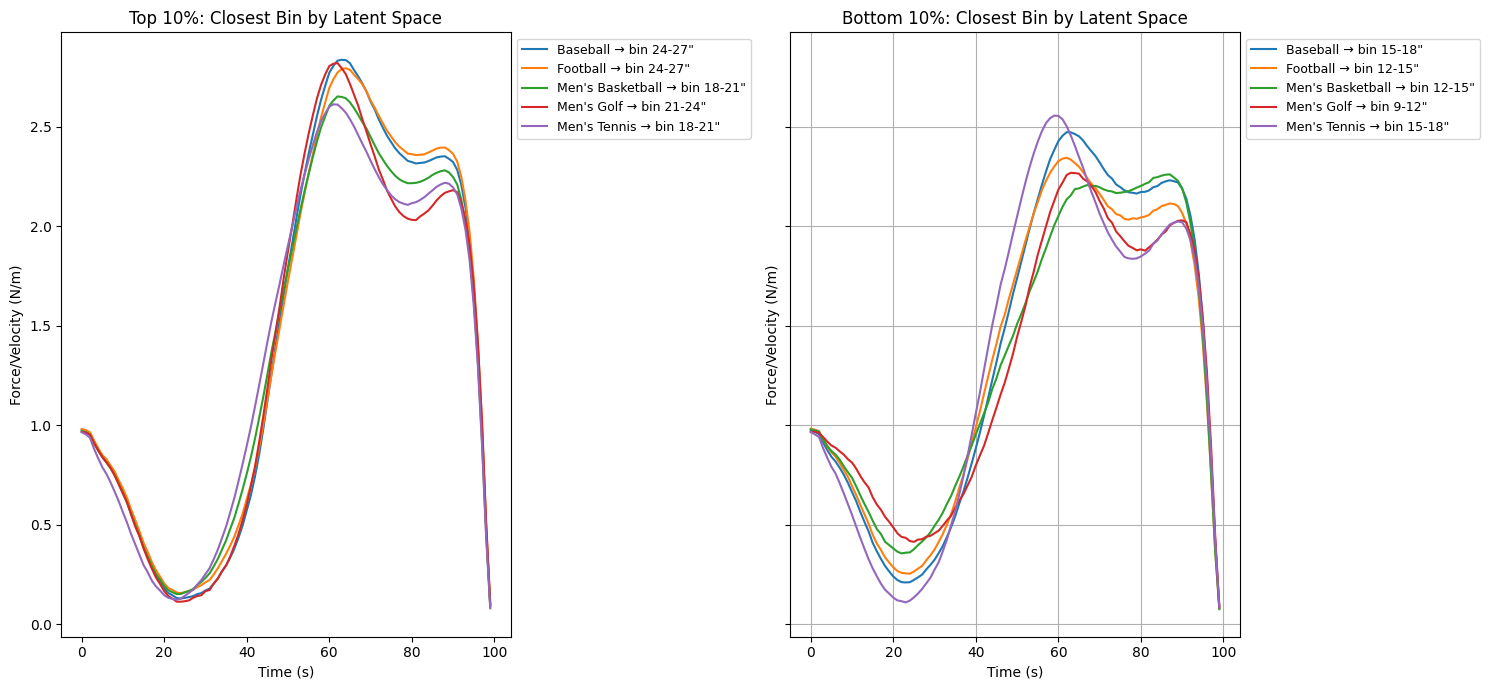

In [87]:
from scipy.spatial.distance import cdist

# 1. Get the average latent vector for each jump height bin
bin_latents = binned_males.groupby('jump_bin')['vae_latent_space_4d'].apply(
    lambda x: np.mean(np.stack(x), axis=0)
)

# 2. Function to find the closest bin
def closest_bin(latent_vec, bin_latents):
    bin_matrix = np.stack(bin_latents.values)
    distances = cdist([latent_vec], bin_matrix)[0]
    closest_idx = np.argmin(distances)
    return bin_latents.index[closest_idx]

# 3. Compute average latent vectors for top/bottom performers
top_bottom_percentiles = binned_males.groupby('Team').apply(
    lambda x: {
        'top_10': x.nlargest(int(len(x) * 0.1), 'JUMP_HEIGHT_INCHES'),
        'bottom_10': x.nsmallest(int(len(x) * 0.1), 'JUMP_HEIGHT_INCHES')
    }
).apply(pd.Series)

def get_avg_latent_space(df):
    top_avg = np.mean(np.stack(df['top_10']['vae_latent_space_4d'].values), axis=0)
    bottom_avg = np.mean(np.stack(df['bottom_10']['vae_latent_space_4d'].values), axis=0)
    return top_avg, bottom_avg

avg_latent_vectors = top_bottom_percentiles.apply(get_avg_latent_space, axis=1)

reconstructed_top = {}
reconstructed_bottom = {}
closest_top_bins = {}
closest_bottom_bins = {}

for sport, (top_latent, bottom_latent) in avg_latent_vectors.items():
    sport_data = binned_males[binned_males['Team'] == sport]
    initial_value = sport_data['initial_value'].iloc[0]
    
    reconstructed_top[sport] = reconstruct_jump(top_latent, vae, initial_value)
    reconstructed_bottom[sport] = reconstruct_jump(bottom_latent, vae, initial_value)

    closest_top_bins[sport] = closest_bin(top_latent, bin_latents)
    closest_bottom_bins[sport] = closest_bin(bottom_latent, bin_latents)


fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True)



for sport in avg_latent_vectors.index:
    label = f"{sport} → bin {closest_top_bins[sport]}\""
    axes[0].plot(reconstructed_top[sport], label=label)
axes[0].set_title("Top 10%: Closest Bin by Latent Space")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Force/Velocity (N/m)")
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)

for sport in avg_latent_vectors.index:
    label = f"{sport} → bin {closest_bottom_bins[sport]}\""
    axes[1].plot(reconstructed_bottom[sport], label=label)
axes[1].set_title("Bottom 10%: Closest Bin by Latent Space")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Force/Velocity (N/m)")
axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
plt.grid(True)

plt.tight_layout()
plt.show()


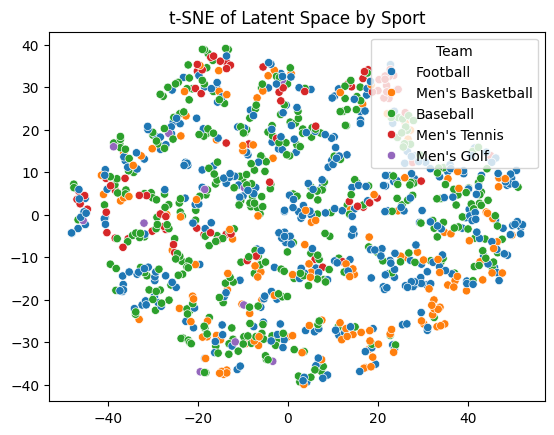

In [88]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
sampled_df = binned_males.sample(n=1000, random_state=42)


X = np.stack(sampled_df['vae_latent_space_4d'].values)
labels = sampled_df['Team']  

X_proj = TSNE(n_components=2, perplexity=20).fit_transform(X)

sns.scatterplot(x=X_proj[:,0], y=X_proj[:,1], hue=labels)
plt.title("t-SNE of Latent Space by Sport")
plt.show()


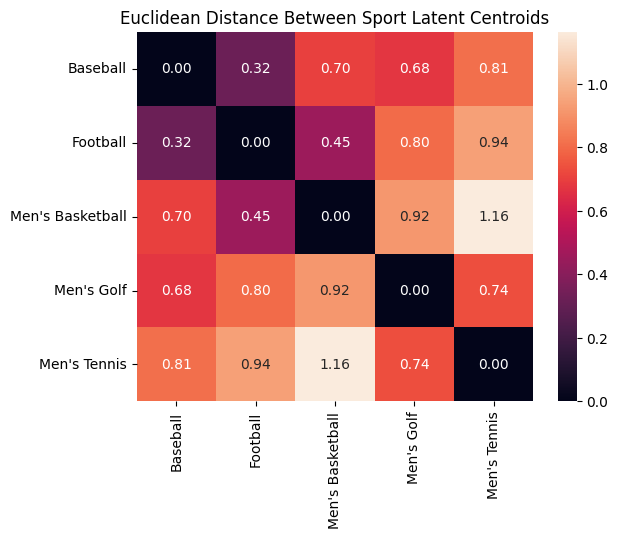

In [89]:
from scipy.spatial.distance import cdist

grouped = binned_males.groupby('Team')
centroids = {sport: np.mean(np.stack(g['vae_latent_space_4d']), axis=0)
             for sport, g in grouped}

sports = list(centroids.keys())
dist_matrix = np.zeros((len(sports), len(sports)))

for i, s1 in enumerate(sports):
    for j, s2 in enumerate(sports):
        dist_matrix[i, j] = np.linalg.norm(centroids[s1] - centroids[s2])

sns.heatmap(dist_matrix, xticklabels=sports, yticklabels=sports, annot=True, fmt=".2f")
plt.title("Euclidean Distance Between Sport Latent Centroids")
plt.show()


Jake's points around the influence of anthropometrics on latent space prediction of improved jump height for athletes is an interesting investigation. It could be worth thinking about the performance testing on 5/26 with Beach Volleyball and Acro as being a test data set to see if stature influence prediction.
Another place to look at:
- To move from one bin to the next bin (increase jump height), does the latent space prediction push all prediction to what the idealized curve shape is for the next jump height bin? 
- How different are the are the latent spaces between sports? This is riffing off an older paper from Sparta Science using PCA (https://pubmed.ncbi.nlm.nih.gov/23838969/#:~:text=The%20subjects%20performed%20a%20series,for%20football%20and%20baseball%20players.)
- Also, high performer and low performers in a given sport?

In [90]:
from scipy.optimize import basinhopping

def compare_latent_space_to_next_bin_for_all(model_df, vae, delta=1.0):
    vae.eval()
    
    athlete_results = []

    for profileID in model_df["profileID"].unique():
        athlete_df = model_df[model_df["profileID"] == profileID].copy()
        
        if athlete_df.empty:
            print(f"No data found for profileID: {profileID}")
            continue

        top_jump = athlete_df.sort_values("recordedUTC", ascending=False).head(1).iloc[0]
        latent_vec = np.array(top_jump["vae_latent_space_4d"])
        actual_recorded_height = top_jump["JUMP_HEIGHT_INCHES"]

        def predict_height(z):
            with torch.no_grad():
                z_tensor = torch.tensor(z, dtype=torch.float32).unsqueeze(0)
                rec = vae.decode(z_tensor).squeeze().cpu().numpy()

            rec = np.clip(rec, 0, 5)
            adjusted = rec - (rec[0] * (20 / top_jump["initial_value"]))
            net_force = adjusted - 1.0
            avg_net_force = np.mean(net_force)
            takeoff_velocity = avg_net_force * top_jump["jump_duration_s"] * 9.81
            height = (takeoff_velocity ** 2) / (2 * 9.81) * 39.37
            return height

        predicted_orig_height = predict_height(latent_vec)
        target_jump_height = predicted_orig_height + delta  # Target jump height after improvement

        def objective(z_new):
            pred = predict_height(z_new)
            penalty = max(0, target_jump_height - pred) ** 2
            return np.sum((z_new - latent_vec) ** 2) + 10 * penalty

        def constraint(z_new):
            return predict_height(z_new) - target_jump_height

        # minimizer_kwargs = {
        #     "method": "SLSQP",
        #     "bounds": [(val - 2.0, val + 2.0) for val in latent_vec],
        #     "constraints": [{'type': 'ineq', 'fun': constraint}],
        # }

        result = minimize(
            objective, 
            x0=latent_vec,
            method='SLSQP',
            bounds=[(val - 2.0, val + 2.0) for val in latent_vec],
            constraints=[{'type': 'ineq', 'fun': constraint}]
        )        
        z_new = result.x

        higher_bin_latents = model_df[model_df['JUMP_HEIGHT_INCHES'] > actual_recorded_height]
        if higher_bin_latents.empty:
            print(f"No higher bin data found for profileID: {profileID}")
            continue

        z_next_bin = np.stack(higher_bin_latents['vae_latent_space_4d'].values)
        z_mean_next = np.mean(z_next_bin, axis=0)

        latent_dist_orig = np.linalg.norm(latent_vec - z_mean_next)
        latent_dist_new = np.linalg.norm(z_new - z_mean_next)

        athlete_results.append({
            "profileID": profileID,
            "original_distance": latent_dist_orig,
            "prescribed_distance": latent_dist_new,
            "moved_closer": latent_dist_new < latent_dist_orig
        })

    athlete_results_df = pd.DataFrame(athlete_results)

    num_athletes = len(athlete_results_df)
    num_moved_closer = athlete_results_df["moved_closer"].sum()
    num_did_not = num_athletes - num_moved_closer

    percent_moved_closer = (num_moved_closer / num_athletes) * 100 if num_athletes > 0 else 0
    percent_did_not = 100 - percent_moved_closer

    print("\n--- Summary of Results ---")
    # print(athlete_results_df)

    print(f"\n{num_moved_closer}/{num_athletes} athletes moved closer to the next bin ({percent_moved_closer:.2f}%)")
    print(f"{num_did_not}/{num_athletes} athletes did not move closer ({percent_did_not:.2f}%)")

    return athlete_results_df, percent_moved_closer, percent_did_not




subset_df = binned_males[binned_males["JUMP_HEIGHT_INCHES"] < 24]
athlete_results_df, percent_moved_closer, percent_did_not = compare_latent_space_to_next_bin_for_all(model_df=subset_df, vae=vae, delta=2)


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/scipy/optimize/_optimize.py:353: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "



--- Summary of Results ---

147/307 athletes moved closer to the next bin (47.88%)
160/307 athletes did not move closer (52.12%)


In [91]:
len(subset_df["profileID"].unique())

307

The 5d Latent Space (with time): [-0.26089147  0.35350525 -0.08935882 -0.126541   -0.122253  ]



/anaconda/envs/azureml_py38/lib/python3.10/site-packages/scipy/optimize/_optimize.py:353: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "



Jump ID: 657cdaf4-e31f-4003-a48b-287f51ec7149, Date: 2024-11-19 21:11:39.327000+00:00
Predicted Original Height: 17.21 inches
Target Prescribed Height: 21.21 inches
Predicted Prescribed Height: 21.21 inches
Latent change magnitude: 0.5701
Original jump duration: 0.754s | New duration: 0.768s

Latent Dimension Comparison:
z1        -0.2609     -0.4564           -0.1955
z2         0.3535      0.8114            0.4578
z3        -0.0894     -0.0591            0.0303
z4        -0.1265      0.0777            0.2042
t_n       -0.1223      0.0638            0.1861

--- Quantitative Similarity to Higher Bin ---
Metric                  Original    Prescribed   Improved?
RMSE                      0.0433        0.1157          NO
Pearson Corr.             0.9990        0.9984          NO


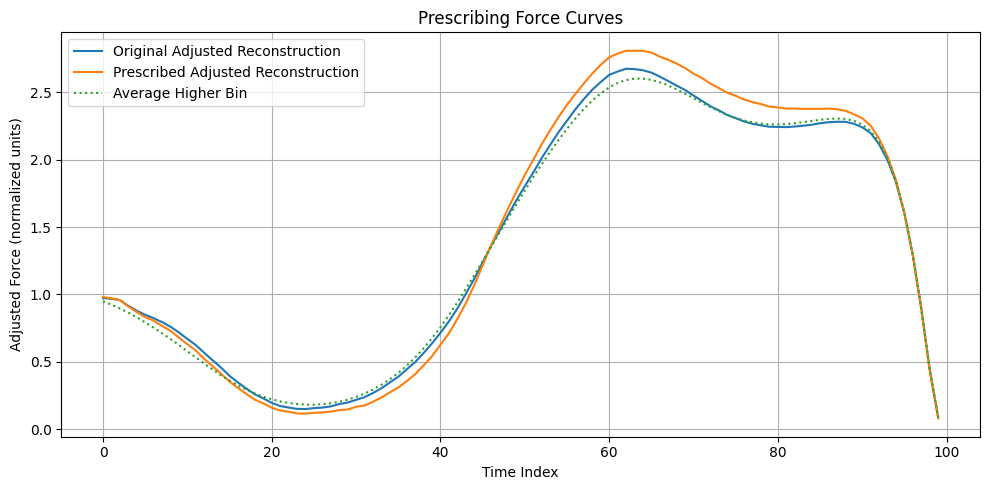

In [88]:
from scipy.optimize import basinhopping
from scipy.stats import pearsonr


def prescribe_jump_improvement(profileID, model_df, vae, top_n=1, delta=1.0):
    jump_mean = model_df["jump_duration_s"].mean()
    jump_std = model_df["jump_duration_s"].std()
    vae.eval()
    athlete_df = model_df[model_df["profileID"] == profileID].copy()
    
    if athlete_df.empty:
        print(f"No data found for profileID: {profileID}")
        return

    top_jumps = athlete_df.sort_values("recordedUTC", ascending=False).head(top_n)

    for idx, row in top_jumps.iterrows():
        latent_vec = np.array(row["vae_latent_space_4d"])
        jump_duration = row["jump_duration_s"]
        initial_val = row["initial_value"]
        jump_date = row["recordedUTC"]
        actual_recorded_height = row["JUMP_HEIGHT_INCHES"]

        if initial_val < 1e-3:
            print(f"[SKIP] initial_val too small ({initial_val})")
            continue
        if jump_duration > 2.0 or jump_duration <= 0:
            print(f"[SKIP] suspicious jump_duration ({jump_duration:.3f}s)")
            continue

        # latent vector with normalized time
        t_n = (jump_duration - jump_mean) / jump_std
        latent_5d = np.concatenate([latent_vec, [t_n]])
        print(f"The 5d Latent Space (with time): {latent_5d}\n")

        def predict_height(z):
            z_latent = z[:4]
            t_n_pred = z[4]
            jump_t = t_n_pred * jump_std + jump_mean  # denormalize

            if jump_t <= 0 or jump_t > 2.0:
                return -100.0  # invalid duration penalty

            with torch.no_grad():
                z_tensor = torch.tensor(z_latent, dtype=torch.float32).unsqueeze(0)
                rec = vae.decode(z_tensor).squeeze().cpu().numpy()

            rec = np.clip(rec, 0, 5)
            offset = rec[0] * (20 / initial_val)
            adjusted = rec - offset
            net_force = adjusted - 1.0
            avg_net_force = np.mean(net_force)
            takeoff_velocity = avg_net_force * jump_t * 9.81
            height = (takeoff_velocity ** 2) / (2 * 9.81) * 39.37
            return height

        predicted_orig_height = predict_height(latent_5d)
        target_jump_height = predicted_orig_height + delta

        def objective(z_new):
            pred = predict_height(z_new)
            penalty = max(0, target_jump_height - pred) ** 2
            return np.sum((z_new - latent_5d) ** 2) + 10 * penalty

        epsilon = 0.05

        def constraint(z_new):
            return predict_height(z_new) - target_jump_height

        def min_latent_shift(z_new):
            return np.linalg.norm(z_new - latent_5d) - epsilon

        bounds = [(val - 2.0, val + 2.0) for val in latent_vec] + [(-2.0, 2.0)]  # t_n bound

        constraints = [
            {'type': 'ineq', 'fun': constraint},
            {'type': 'ineq', 'fun': min_latent_shift},
        ]

        minimizer_kwargs = {
            "method": "SLSQP",
            "bounds": bounds,
            "constraints": constraints
        }

        result = basinhopping(objective, x0=latent_5d, minimizer_kwargs=minimizer_kwargs, niter=100)

        z_new = result.x
        z_new_latent = z_new[:4]
        z_new_tn = z_new[4]
        predicted_new_height = predict_height(z_new)

        print("\n" + "=" * 60)
        print(f"Jump ID: {row['profileID']}, Date: {jump_date}")
        print(f"Predicted Original Height: {predicted_orig_height:.2f} inches")
        print(f"Target Prescribed Height: {target_jump_height:.2f} inches")
        print(f"Predicted Prescribed Height: {predicted_new_height:.2f} inches")
        print(f"Latent change magnitude: {np.linalg.norm(z_new - latent_5d):.4f}")
        print(f"Original jump duration: {jump_duration:.3f}s | New duration: {z_new_tn * jump_std + jump_mean:.3f}s")

        print(f"\nLatent Dimension Comparison:")
        for i, (orig, new) in enumerate(zip(latent_5d, z_new)):
            label = "t_n" if i == 4 else f"z{i+1}"
            print(f"{label:<5}{orig:>12.4f}{new:>12.4f}{(new - orig):>18.4f}")

        with torch.no_grad():
            rec_orig = vae.decode(torch.tensor(latent_vec, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()
            rec_new = vae.decode(torch.tensor(z_new_latent, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()

        offset_orig = rec_orig[0] * (20 / initial_val)
        offset_new = rec_new[0] * (20 / initial_val)
        adj_orig = rec_orig - offset_orig
        adj_new = rec_new - offset_new

        def parse_bin_label(label):
            start, end = label.split('-')
            return float(start), float(end)

        unique_bins = model_df['jump_bin'].dropna().unique()
        bin_tuples = [(label, *parse_bin_label(label)) for label in unique_bins]
        bin_tuples.sort(key=lambda x: x[1])

        current_bin_label = None
        next_bin_label = None
        for i, (label, start, end) in enumerate(bin_tuples):
            if start <= predicted_orig_height < end:
                current_bin_label = label
                if i + 1 < len(bin_tuples):
                    next_bin_label = bin_tuples[i + 1][0]
                break

        higher_bin_latents = model_df[model_df['JUMP_HEIGHT_INCHES'] > actual_recorded_height]
        if next_bin_label:
            higher_bin_latents = higher_bin_latents[higher_bin_latents['jump_bin'] == next_bin_label]

        if not higher_bin_latents.empty and 'downsampled_time_series' in higher_bin_latents.columns:
            downsampled_arrays = np.stack(higher_bin_latents['downsampled_time_series'].values)
            avg_downsampled_ts = np.mean(downsampled_arrays, axis=0)

            offset_higher_bin = avg_downsampled_ts[0] * (20 / initial_val)
            adj_higher_bin = avg_downsampled_ts - offset_higher_bin
            rmse_orig = np.sqrt(np.mean((adj_orig - adj_higher_bin) ** 2))
            rmse_new = np.sqrt(np.mean((adj_new - adj_higher_bin) ** 2))
            corr_orig, _ = pearsonr(adj_orig, adj_higher_bin)
            corr_new, _ = pearsonr(adj_new, adj_higher_bin)

            print("\n--- Quantitative Similarity to Higher Bin ---")
            print(f"{'Metric':<20}{'Original':>12}{'Prescribed':>14}{'Improved?':>12}")
            print(f"{'RMSE':<20}{rmse_orig:>12.4f}{rmse_new:>14.4f}{'YES' if rmse_new < rmse_orig else 'NO':>12}")
            print(f"{'Pearson Corr.':<20}{corr_orig:>12.4f}{corr_new:>14.4f}{'YES' if corr_new > corr_orig else 'NO':>12}")
            plt.figure(figsize=(10, 5))
            plt.plot(adj_orig, label='Original Adjusted Reconstruction', linestyle='-')
            plt.plot(adj_new, label='Prescribed Adjusted Reconstruction', linestyle='-')

            if 'adj_higher_bin' in locals():
                plt.plot(adj_higher_bin, label='Average Higher Bin', linestyle=':')

            plt.title(f"Prescribing Force Curves")
            plt.xlabel("Time Index")
            plt.ylabel("Adjusted Force (normalized units)")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        else:
            print("No higher bin data with downsampled_time_series available.")

prescribe_jump_improvement(profileID="657cdaf4-e31f-4003-a48b-287f51ec7149", model_df=binned_males, top_n=1, vae=vae, delta=4)

### How is Time Incorporated?
- Normalize jump duration and add it as a 5th dimension to latent space used in optimization. 
- When predicting, 5th dimension interpreted as normalized time, which is then de-normalized back to seconds. Allows for impulse to be scaled correctly. 

# What is this code doing?
- Compute mean and standard deviation of jump_duration across athletes for normalization. 
- Retrieve 4D latent vector, append normalized jump_duration -> creates 5D latent vector.
- This vector becomes input for predicting and optimizing jump height.
# Height Prediction
- The objective() function optimizes the 5D vector with time concatenated to maximize jump height in as little change in latent space as possible. 
- The noramlized time is then reconverted. 
# Optimization Problem
- Defines objective function that:
    - Penalizes solutions far from original latent vector
    - Strongly penalizes those that don't improve jump height by delta inches
- Adds constraints:
    - Predicted height must reach or exceed the target (will still display closest attempt)
    - Latent shift must be at least 0.05 to avoid trivial solutions.
    

In [92]:
def predict_height_from_profile(
    profileID,
    model_df,
    vae,
    delta_vector=None,  # e.g., np.array([0.1, -0.2, 0.0, 0.3])
    jump_mean=None,
    jump_std=None
):
    # Get the athlete's most recent jump
    athlete_df = model_df[model_df["profileID"] == profileID].copy()
    if athlete_df.empty:
        raise ValueError(f"No data found for profileID {profileID}")
    
    top_jump = athlete_df.sort_values("recordedUTC", ascending=False).iloc[0]

    # Extract info
    latent_vec = np.array(top_jump["vae_latent_space_4d"])
    jump_duration = top_jump["jump_duration_s"]
    initial_val = top_jump["initial_value"]

    if jump_mean is None:
        jump_mean = model_df["jump_duration_s"].mean()
    if jump_std is None:
        jump_std = model_df["jump_duration_s"].std()

    t_n = (jump_duration - jump_mean) / jump_std

    # Apply modification if provided
    if delta_vector is not None:
        latent_vec = latent_vec + delta_vector
    z5d = np.concatenate([latent_vec, [t_n]])

    # --- Predict height ---
    z_latent = z5d[:4]
    t_n_pred = z5d[4]
    jump_t = t_n_pred * jump_std + jump_mean  # denormalize

    if jump_t <= 0 or jump_t > 2.0:
        return -100.0  # invalid duration penalty

    with torch.no_grad():
        z_tensor = torch.tensor(z_latent, dtype=torch.float32).unsqueeze(0)
        rec = vae.decode(z_tensor).squeeze().cpu().numpy()

    rec = np.clip(rec, 0, 5)
    offset = rec[0] * (20 / initial_val)
    adjusted = rec - offset
    net_force = adjusted - 1.0
    avg_net_force = np.mean(net_force)
    takeoff_velocity = avg_net_force * jump_t * 9.81
    height = (takeoff_velocity ** 2) / (2 * 9.81) * 39.37

    return height

# No modification — just predict the height for current state
print(predict_height_from_profile("5743491d-af1f-47fb-8838-252a96696964", binned_males, vae))

# Apply a small tweak to the latent space
delta = np.array([-1.6855, 1.2591, 0.3610, 0.6515])
predict_height_from_profile("5743491d-af1f-47fb-8838-252a96696964", binned_males, vae, delta_vector=delta)


18.290141134364887


32.25316261097102

In [93]:
from scipy.stats import pearsonr


errors = []
correlations = []

for idx, row in binned_males.iterrows():
    # Get latent space and force curve
    latent_vec = np.array(row["vae_latent_space_4d"])  # or row["vae_latent_space_5d"][:4]
    original = np.array(row["downsampled_time_series"])
    initial_val = row["initial_value"]

    with torch.no_grad():
        z = torch.tensor(latent_vec, dtype=torch.float32).unsqueeze(0)
        x_hat = vae.decode(z).squeeze().cpu().numpy()

    offset = x_hat[0] * (20 / initial_val)
    adjusted_x_hat = x_hat - offset
    adjusted_original = original - (original[0] * (20 / initial_val))

    rmse = np.sqrt(np.mean((adjusted_original - adjusted_x_hat) ** 2))
    corr, _ = pearsonr(adjusted_original, adjusted_x_hat)

    errors.append(rmse)
    correlations.append(corr)

print(f"Average RMSE: {np.mean(errors):.4f}")
print(f"Average Pearson Correlation: {np.mean(correlations):.4f}")

Average RMSE: 0.0927
Average Pearson Correlation: 0.9948


- How different are the are the latent spaces between sports? This is riffing off an older paper from Sparta Science using PCA (https://pubmed.ncbi.nlm.nih.gov/23838969/#:~:text=The%20subjects%20performed%20a%20series,for%20football%20and%20baseball%20players.)
- Also, high performer and low performers in a given sport?

### How Different are the Latent Spaces Between High and Low Performers

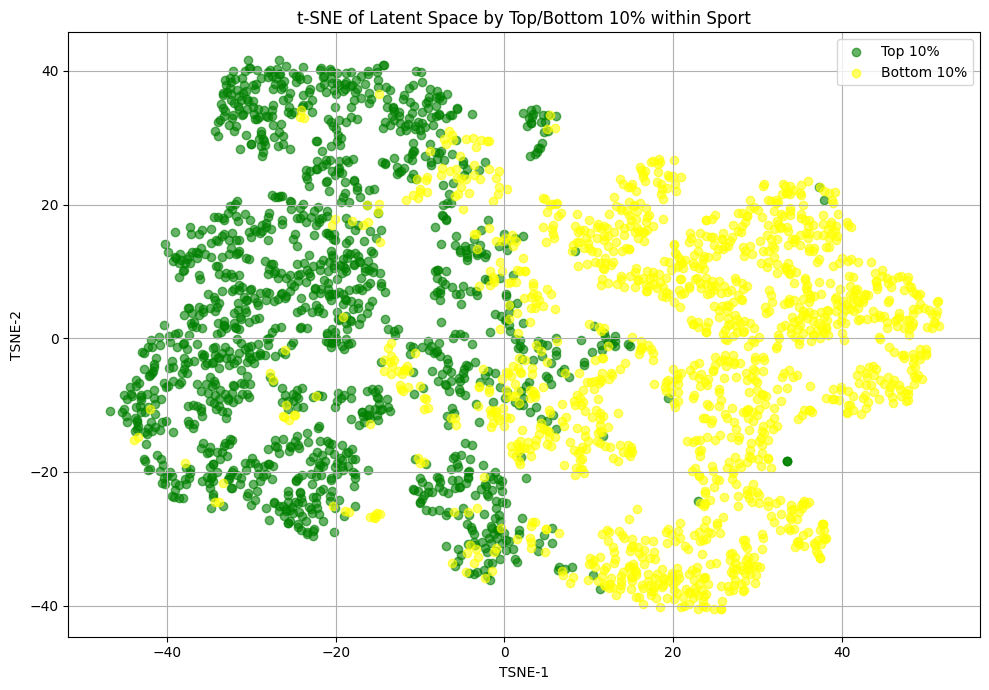

In [94]:
from sklearn.manifold import TSNE

def label_top_bottom(group):
    n = len(group)
    top_n = int(n * 0.1)
    bottom_n = int(n * 0.1)
    group = group.copy()
    group['Performance'] = 'Middle'
    group.loc[group['JUMP_HEIGHT_INCHES'].nlargest(top_n).index, 'Performance'] = 'Top 10%'
    group.loc[group['JUMP_HEIGHT_INCHES'].nsmallest(bottom_n).index, 'Performance'] = 'Bottom 10%'
    return group

labeled_df = binned_males.groupby('Team', group_keys=False).apply(label_top_bottom)

filtered_df = labeled_df[labeled_df['Performance'].isin(['Top 10%', 'Bottom 10%'])].copy()

latent_matrix = np.stack(filtered_df['vae_latent_space_4d'].values)

tsne = TSNE(n_components=2, perplexity=50, learning_rate=200, random_state=42)
tsne_result = tsne.fit_transform(latent_matrix)

filtered_df['TSNE-1'] = tsne_result[:, 0]
filtered_df['TSNE-2'] = tsne_result[:, 1]

plt.figure(figsize=(10, 7))
for label, color in zip(['Top 10%', 'Bottom 10%'], ['green', 'yellow']):
    subset = filtered_df[filtered_df['Performance'] == label]
    plt.scatter(subset['TSNE-1'], subset['TSNE-2'], label=label, alpha=0.6, c=color)

plt.title("t-SNE of Latent Space by Top/Bottom 10% within Sport")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [92]:
# t-sne everything first then just color by top10 and bottom10%
# plot from top 10 and bottom 10, 
# 

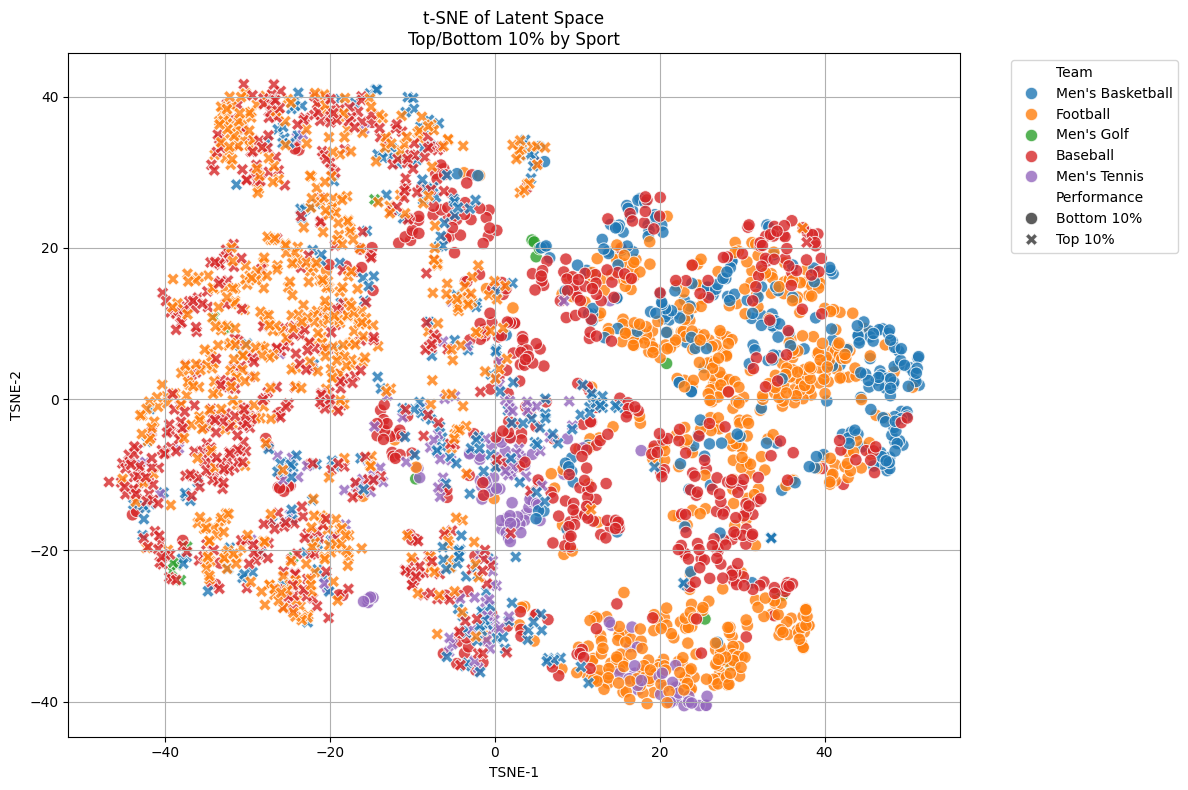

In [95]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=filtered_df,
    x='TSNE-1',
    y='TSNE-2',
    hue='Team',
    style='Performance',
    palette='tab10',  
    s=80,
    alpha=0.8
)

plt.title("t-SNE of Latent Space\nTop/Bottom 10% by Sport")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


This t-SNE projection shows a clear separation between top and bottom 10% performers within each sport, based on their latent space representations. In other words, the neural network has learned to encode performance-relevant features — high performers cluster on the left, low performers on the right.

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = tsne_result
y = (filtered_df['Performance'] == 'Top 10%').astype(int)
clf = LogisticRegression().fit(X, y)
preds = clf.predict(X)
accuracy = accuracy_score(y, preds)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.90


In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# 1. Stack latent space vectors into a matrix
X_latent = np.stack(filtered_df['vae_latent_space_4d'].values)  # shape: (n_samples, 4)

# 2. Get jump duration or time-based variable (must be 1D)
jump_duration = filtered_df['jump_duration_s'].values.reshape(-1, 1)  # shape: (n_samples, 1)

# 3. Concatenate latent space and duration into one feature matrix
X_combined = np.hstack([X_latent, jump_duration])  # shape: (n_samples, 5)

# 4. Define binary target
y = (filtered_df['Performance'] == 'Top 10%').astype(int)

# 5. Fit logistic regression
clf = LogisticRegression().fit(X_combined, y)

# 6. Predict and evaluate
preds = clf.predict(X_combined)
accuracy = accuracy_score(y, preds)

print(f"Logistic Regression Accuracy with Time Feature: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y, preds))


Logistic Regression Accuracy with Time Feature: 0.95

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.95      1420
           1       0.94      0.95      0.95      1420

    accuracy                           0.95      2840
   macro avg       0.95      0.95      0.95      2840
weighted avg       0.95      0.95      0.95      2840



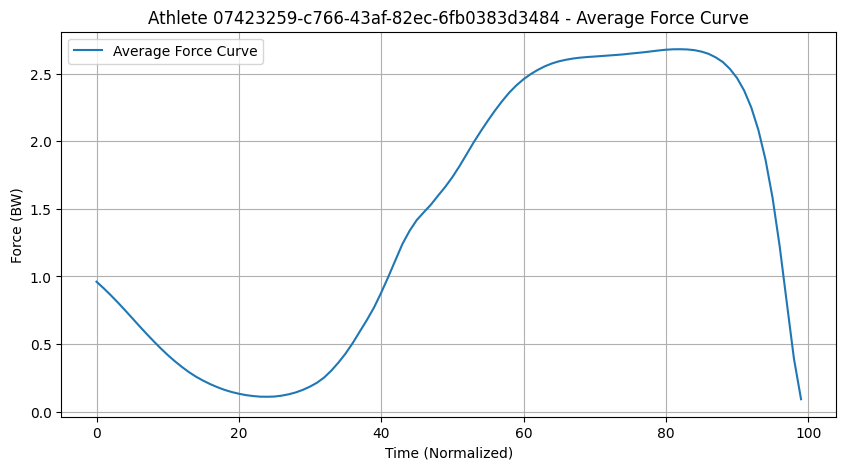

In [98]:
import numpy as np
import matplotlib.pyplot as plt

# Filter to this athlete's data
athlete_id = "07423259-c766-43af-82ec-6fb0383d3484"
athlete_df = binned_males[binned_males["profileID"] == athlete_id]

# Stack all their downsampled time series into a matrix
force_curves = np.stack(athlete_df["downsampled_time_series"].values)

# Compute the average force curve
avg_curve = force_curves.mean(axis=0)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(avg_curve, label='Average Force Curve')
plt.title(f"Athlete {athlete_id} - Average Force Curve")
plt.xlabel("Time (Normalized)")
plt.ylabel("Force (BW)")
plt.grid(True)
plt.legend()
plt.show()


Most unimodal football athlete: 07423259-c766-43af-82ec-6fb0383d3484 with 1 peak(s)


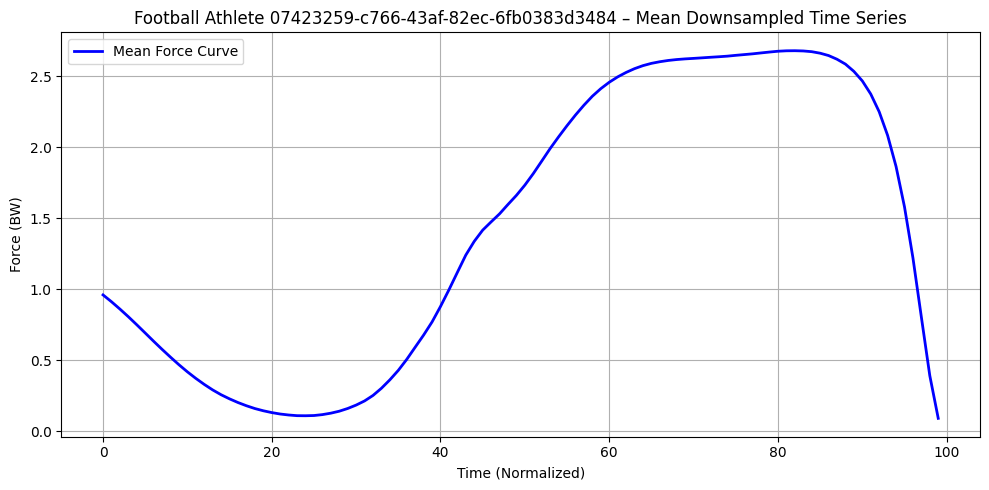

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def count_prominent_peaks(curve, height_thresh=0.2):
    peaks, _ = find_peaks(curve, height=height_thresh)
    return len(peaks)

# Filter to football athletes only
football_df = binned_males[binned_males["Team"] == "Football"]

peak_counts = []

for pid, group in football_df.groupby("profileID"):
    if len(group) < 2:
        continue  # skip athletes with less than 2 jumps

    try:
        curves = np.stack(group["downsampled_time_series"].values)
        avg_curve = curves.mean(axis=0)
        n_peaks = count_prominent_peaks(avg_curve)
        peak_counts.append((pid, n_peaks, avg_curve))
    except:
        continue

peak_counts.sort(key=lambda x: x[1])

best_pid, best_peak_count, best_avg_curve = peak_counts[0]

print(f"Most unimodal football athlete: {best_pid} with {best_peak_count} peak(s)")

plt.figure(figsize=(10, 5))
plt.plot(best_avg_curve, color='blue', linewidth=2, label='Mean Force Curve')
plt.title(f"Football Athlete {best_pid} – Mean Downsampled Time Series")
plt.xlabel("Time (Normalized)")
plt.ylabel("Force (BW)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [100]:
binned_males[binned_males["profileID"] == "07423259-c766-43af-82ec-6fb0383d3484"]

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space_consistency,reconstruction_loss,reconstruction,outlier,total_sessions,start_year,years_training,first_session_date,relative_session,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,initial_weight,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2,vae_latent_space_4d,reconstructed_waveform,adjusted_reconstruction,predicted_takeoff_velocity,latent_predicted_jump_height,avg_diff_recon_vs_downsampled,avg_magnitude_downsampled,diff_ratio,jump_bin
13382,2873,2873,2e6e21cd-efce-4535-a74e-53d453084499,1,07423259-c766-43af-82ec-6fb0383d3484,2024-05-13 17:30:36.672000+00:00,Football,Team,NaN,NaN,211.266573,16.892,17.360,17.070,17.186,16.385292,16.892,16.123261,13.052569,0.578,40.953061,33.269796,33.153506,14.486,result\nPOSITIVE_IMPULSE 829.040725\nPOSITI...,841.623620,57.230,result\nLANDING_RFD 34467.063\nLANDING_RFD ...,2.556,13

In [101]:
from sklearn.linear_model import LogisticRegression

# Train logistic model on t-SNE (2D)
X = filtered_df[['TSNE-1', 'TSNE-2']].values
y = (filtered_df['Performance'] == 'Top 10%').astype(int)

clf = LogisticRegression().fit(X, y)
filtered_df['Predicted'] = clf.predict(X)
filtered_df['Correct'] = (filtered_df['Predicted'] == y)


In [102]:
# Top 10% that look like Bottom 10%
top_in_bottom_cluster = filtered_df[
    (filtered_df['Performance'] == 'Top 10%') & (filtered_df['Predicted'] == 0)
]

# Bottom 10% that look like Top 10%
bottom_in_top_cluster = filtered_df[
    (filtered_df['Performance'] == 'Bottom 10%') & (filtered_df['Predicted'] == 1)
]


In [103]:
filtered_df.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space_consistency,reconstruction_loss,reconstruction,outlier,total_sessions,start_year,years_training,first_session_date,relative_session,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,initial_weight,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2,vae_latent_space_4d,reconstructed_waveform,adjusted_reconstruction,predicted_takeoff_velocity,latent_predicted_jump_height,avg_diff_recon_vs_downsampled,avg_magnitude_downsampled,diff_ratio,jump_bin,Performance,TSNE-1,TSNE-2,Predicted,Correct
28139,543,543,5cf946e0-2b95-4ba6-9e5f-2987907ef93b,4,4c783ecb-b867-463b-a2e0-9c83cea770f8,2022-08-14 18:20:38.182000+00:00,Men's Basketball,Team,NaN,NaN,201.468898,110.046,110.434,110.172,110.254,18.134567,110.046,8.351873,7.452329,0.416,21.213745,18.921078,18.928905,30.698,result\nPOSITIVE_IMPULSE 556.193919\nPOSIT...,2775.454393,177.629,r

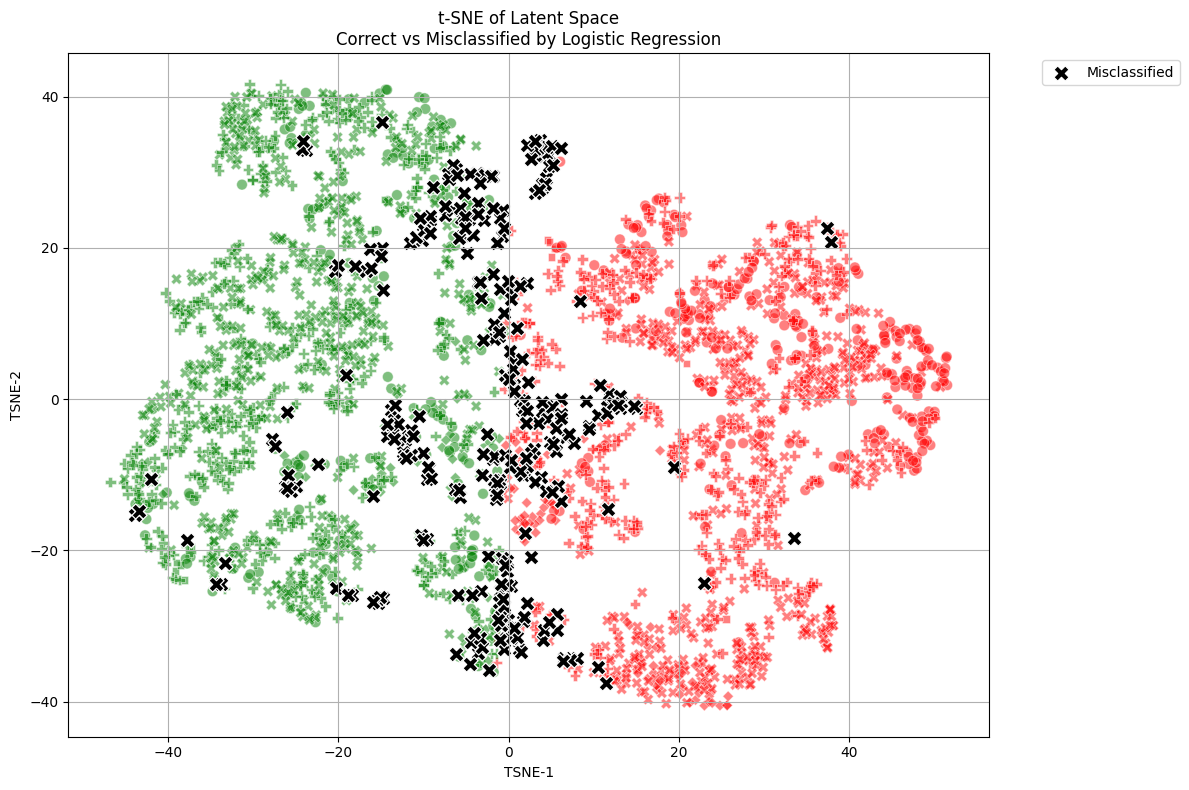

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# Plot all correctly classified points
sns.scatterplot(
    data=filtered_df[filtered_df['Correct']],
    x='TSNE-1',
    y='TSNE-2',
    hue='Performance',
    style='Team',  # Optional: distinguish teams
    alpha=0.5,
    palette={'Top 10%': 'green', 'Bottom 10%': 'red'},
    s=60,
    legend=False
)

# Overlay misclassified points in black
sns.scatterplot(
    data=filtered_df[~filtered_df['Correct']],
    x='TSNE-1',
    y='TSNE-2',
    marker='X',
    color='black',
    s=120,
    label='Misclassified'
)

plt.title("t-SNE of Latent Space\nCorrect vs Misclassified by Logistic Regression")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [105]:
top_curves = np.stack(filtered_df[filtered_df['Performance'] == 'Top 10%']['downsampled_time_series'].values)
bottom_curves = np.stack(filtered_df[filtered_df['Performance'] == 'Bottom 10%']['downsampled_time_series'].values)


top_times = filtered_df[filtered_df['Performance'] == 'Top 10%']['jump_duration_s'].mean()
bottom_times = filtered_df[filtered_df['Performance'] == 'Bottom 10%']['jump_duration_s'].mean()

mean_top = top_curves.mean(axis=0)
mean_bottom = bottom_curves.mean(axis=0)


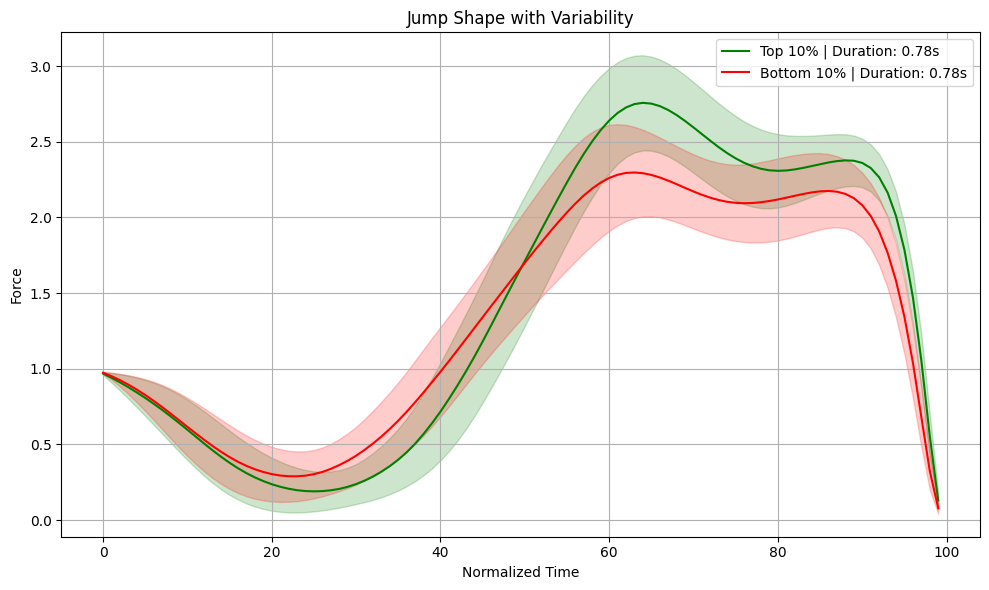

In [106]:
std_top = top_curves.std(axis=0)
std_bottom = bottom_curves.std(axis=0)

plt.figure(figsize=(10, 6))
plt.plot(mean_top, label=f'Top 10% | Duration: {top_times:.2f}s', color='green')
plt.fill_between(range(len(mean_top)), mean_top - std_top, mean_top + std_top, alpha=0.2, color='green')

plt.plot(mean_bottom, label=f'Bottom 10% | Duration: {bottom_times:.2f}s', color='red')
plt.fill_between(range(len(mean_bottom)), mean_bottom - std_bottom, mean_bottom + std_bottom, alpha=0.2, color='red')

plt.title("Jump Shape with Variability")
plt.xlabel("Normalized Time")
plt.ylabel("Force")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

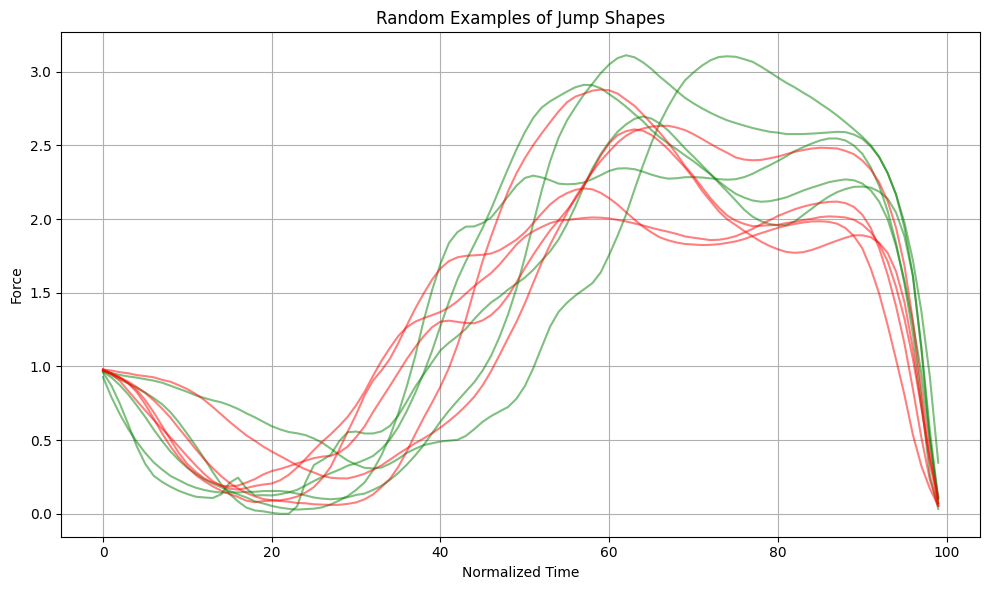

In [107]:
# Show 5 random examples from each group
sample_top = top_curves[np.random.choice(len(top_curves), 5, replace=False)]
sample_bottom = bottom_curves[np.random.choice(len(bottom_curves), 5, replace=False)]

plt.figure(figsize=(10, 6))
for curve in sample_top:
    plt.plot(curve, color='green', alpha=0.5)
for curve in sample_bottom:
    plt.plot(curve, color='red', alpha=0.5)

plt.title("Random Examples of Jump Shapes")
plt.xlabel("Normalized Time")
plt.ylabel("Force")
plt.grid(True)
plt.tight_layout()
plt.show()

In [108]:
len_filtered_d

NameError: name 'len_filtered_d' is not defined

In [ ]:
filtered_df[(filtered_df["Team"] == "Football") & (filtered_df["Performance"] == "Top 10%")]["jump_duration_s"].mean()

In [ ]:
teams = filtered_df['Team'].unique()
num_teams = len(teams)

fig, axes = plt.subplots(nrows=num_teams, figsize=(14, 6 * num_teams), sharex=True, sharey=True)

if num_teams == 1:
    axes = [axes]

for team_idx, (team, ax) in enumerate(zip(teams, axes)):
    top_color = 'green'  
    bottom_color = 'red'  

    for performance, color, linestyle in zip(['Top 10%', 'Bottom 10%'], [top_color, bottom_color], ['solid', 'dashed']):
        subset = filtered_df[
            (filtered_df['Team'] == team) & 
            (filtered_df['Performance'] == performance)
        ]
        if len(subset) < 2:
            continue  

        curves = np.stack(subset['downsampled_time_series'].values)
        mean_curve = curves.mean(axis=0)
        std_curve = curves.std(axis=0)

        label = f"{performance}"
        ax.plot(mean_curve, label=label, color=color, linestyle=linestyle)
        ax.fill_between(range(len(mean_curve)),
                         mean_curve - std_curve,
                         mean_curve + std_curve,
                         alpha=0.15, color=color)

    ax.set_title(f"Jump Shape for {team}")
    ax.set_xlabel("Normalized Time")
    ax.set_ylabel("Force / Displacement")
    ax.grid(True)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:

jump_heights = filtered_df['JUMP_HEIGHT_INCHES']
norm = plt.Normalize(jump_heights.min(), jump_heights.max())
colors = plt.cm.viridis(norm(jump_heights))  # or use plt.cm.plasma, coolwarm, etc.

plt.figure(figsize=(10, 7))
plt.scatter(
    filtered_df['TSNE-1'],
    filtered_df['TSNE-2'],
    c=colors,
    s=80,
    alpha=0.8,
    edgecolors='k'
)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'))
cbar.set_label('Jump Height (inches)')

plt.title("t-SNE of Latent Space Colored by Jump Height")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
sorted_df = filtered_df.sort_values('JUMP_HEIGHT_INCHES')

N = 8
indices = np.linspace(0, len(sorted_df) - 1, N, dtype=int)
samples = sorted_df.iloc[indices]

plt.figure(figsize=(12, 6))

for _, row in samples.iterrows():
    jump_height = row['JUMP_HEIGHT_INCHES']
    color = plt.cm.viridis(norm(jump_height))
    plt.plot(row['downsampled_time_series'], color=color, label=f'{jump_height:.1f}"')

# Add colorbar for jump height context
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
cbar = plt.colorbar(sm)
cbar.set_label('Jump Height (inches)')

plt.title("Progression of Reconstructed Jump Shapes (Low to High Performance)")
plt.xlabel("Normalized Time")
plt.ylabel("Force")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# takeX_new - X + X_new -> don't move away from the center, only move away from center of distributio if you're near the middle, if you're near the outisde, try and move closer to center

# min(||X_new - X|| + ||X_new||)

In [ ]:
from scipy.optimize import basinhopping
from scipy.stats import pearsonr


def prescribe_jump_improvement(profileID, model_df, vae, top_n=1, delta=1.0):
    jump_mean = model_df["jump_duration_s"].mean()
    jump_std = model_df["jump_duration_s"].std()
    vae.eval()
    athlete_df = model_df[model_df["profileID"] == profileID].copy()
    
    if athlete_df.empty:
        print(f"No data found for profileID: {profileID}")
        return

    top_jumps = athlete_df.sort_values("recordedUTC", ascending=False).head(top_n)

    for idx, row in top_jumps.iterrows():
        latent_vec = np.array(row["vae_latent_space_4d"])
        jump_duration = row["jump_duration_s"]
        initial_val = row["initial_value"]
        jump_date = row["recordedUTC"]
        actual_recorded_height = row["JUMP_HEIGHT_INCHES"]

        if initial_val < 1e-3:
            print(f"[SKIP] initial_val too small ({initial_val})")
            continue
        if jump_duration > 2.0 or jump_duration <= 0:
            print(f"[SKIP] suspicious jump_duration ({jump_duration:.3f}s)")
            continue

        # latent vector with normalized time
        t_n = (jump_duration - jump_mean) / jump_std
        latent_5d = np.concatenate([latent_vec, [t_n]])
        print(f"The 5d Latent Space (with time): {latent_5d}\n")

        def predict_height(z):
            z_latent = z[:4]
            t_n_pred = z[4]
            jump_t = t_n_pred * jump_std + jump_mean  # denormalize

            if jump_t <= 0 or jump_t > 2.0:
                return -100.0  # invalid duration penalty

            with torch.no_grad():
                z_tensor = torch.tensor(z_latent, dtype=torch.float32).unsqueeze(0)
                rec = vae.decode(z_tensor).squeeze().cpu().numpy()

            rec = np.clip(rec, 0, 5)
            offset = rec[0] * (20 / initial_val)
            adjusted = rec - offset
            net_force = adjusted - 1.0
            avg_net_force = np.mean(net_force)
            takeoff_velocity = avg_net_force * jump_t * 9.81
            height = (takeoff_velocity ** 2) / (2 * 9.81) * 39.37
            return height

        predicted_orig_height = predict_height(latent_5d)
        target_jump_height = predicted_orig_height + delta

        def objective(z_new):
            pred = predict_height(z_new)
            penalty = max(0, target_jump_height - pred) ** 2
            return np.sum((z_new - latent_5d) ** 2) + 10 * penalty

        epsilon = 0.05

        def constraint(z_new):
            return predict_height(z_new) - target_jump_height

        def min_latent_shift(z_new):
            return np.linalg.norm(z_new - latent_5d) - epsilon

        bounds = [(val - 2.0, val + 2.0) for val in latent_vec] + [(-2.0, 2.0)]  # t_n bound

        constraints = [
            {'type': 'ineq', 'fun': constraint},
            {'type': 'ineq', 'fun': min_latent_shift},
        ]

        minimizer_kwargs = {
            "method": "SLSQP",
            "bounds": bounds,
            "constraints": constraints
        }

        result = basinhopping(objective, x0=latent_5d, minimizer_kwargs=minimizer_kwargs, niter=100)

        z_new = result.x
        z_new_latent = z_new[:4]
        z_new_tn = z_new[4]
        predicted_new_height = predict_height(z_new)

        print("\n" + "=" * 60)
        print(f"Jump ID: {row['profileID']}, Date: {jump_date}")
        print(f"Predicted Original Height: {predicted_orig_height:.2f} inches")
        print(f"Target Prescribed Height: {target_jump_height:.2f} inches")
        print(f"Predicted Prescribed Height: {predicted_new_height:.2f} inches")
        print(f"Latent change magnitude: {np.linalg.norm(z_new - latent_5d):.4f}")
        print(f"Original jump duration: {jump_duration:.3f}s | New duration: {z_new_tn * jump_std + jump_mean:.3f}s")

        print(f"\nLatent Dimension Comparison:")
        for i, (orig, new) in enumerate(zip(latent_5d, z_new)):
            label = "t_n" if i == 4 else f"z{i+1}"
            print(f"{label:<5}{orig:>12.4f}{new:>12.4f}{(new - orig):>18.4f}")

        with torch.no_grad():
            rec_orig = vae.decode(torch.tensor(latent_vec, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()
            rec_new = vae.decode(torch.tensor(z_new_latent, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()

        offset_orig = rec_orig[0] * (20 / initial_val)
        offset_new = rec_new[0] * (20 / initial_val)
        adj_orig = rec_orig - offset_orig
        adj_new = rec_new - offset_new

        def parse_bin_label(label):
            start, end = label.split('-')
            return float(start), float(end)

        unique_bins = model_df['jump_bin'].dropna().unique()
        bin_tuples = [(label, *parse_bin_label(label)) for label in unique_bins]
        bin_tuples.sort(key=lambda x: x[1])

        current_bin_label = None
        next_bin_label = None
        for i, (label, start, end) in enumerate(bin_tuples):
            if start <= predicted_orig_height < end:
                current_bin_label = label
                if i + 1 < len(bin_tuples):
                    next_bin_label = bin_tuples[i + 1][0]
                break

        higher_bin_latents = model_df[model_df['JUMP_HEIGHT_INCHES'] > actual_recorded_height]
        if next_bin_label:
            higher_bin_latents = higher_bin_latents[higher_bin_latents['jump_bin'] == next_bin_label]

        if not higher_bin_latents.empty and 'downsampled_time_series' in higher_bin_latents.columns:
            downsampled_arrays = np.stack(higher_bin_latents['downsampled_time_series'].values)
            avg_downsampled_ts = np.mean(downsampled_arrays, axis=0)

            offset_higher_bin = avg_downsampled_ts[0] * (20 / initial_val)
            adj_higher_bin = avg_downsampled_ts - offset_higher_bin
            rmse_orig = np.sqrt(np.mean((adj_orig - adj_higher_bin) ** 2))
            rmse_new = np.sqrt(np.mean((adj_new - adj_higher_bin) ** 2))
            corr_orig, _ = pearsonr(adj_orig, adj_higher_bin)
            corr_new, _ = pearsonr(adj_new, adj_higher_bin)

            height_gain = predicted_new_height - predicted_orig_height

            plt.figure(figsize=(12, 6))
            plt.plot(adj_orig, label=f'Original Jump ({predicted_orig_height:.1f}")', color='blue', linewidth=2)
            plt.plot(adj_new, label=f'Prescribed Jump ({predicted_new_height:.1f}")', color='green', linewidth=2)
            if 'adj_higher_bin' in locals():
                plt.plot(adj_higher_bin, label='Avg Higher Bin', linestyle='--', color='gray')

            plt.fill_between(range(len(adj_orig)), adj_orig, adj_new, 
                             where=(adj_new > adj_orig), interpolate=True, 
                             color='lightgreen', alpha=0.3, label='Increased Force Region')
            plt.fill_between(range(len(adj_orig)), adj_orig, adj_new, 
                             where=(adj_new < adj_orig), interpolate=True, 
                             color='lightcoral', alpha=0.3, label='Decreased Force Region')

            plt.title(f"Jump Shape Change ➜ Height Gain: {height_gain:.2f}\"", fontsize=14)
            plt.xlabel("Normalized Time")
            plt.ylabel("Adjusted Force")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

            avg_force_diff = np.mean(adj_new - adj_orig)

            dt = (jump_duration / len(adj_orig))  # seconds per sample
            impulse_diff = np.sum((adj_new - adj_orig) * dt)  # in BW·s

            force_l2_diff = np.linalg.norm(adj_new - adj_orig)
            mass_kg = initial_val / 9.81  
            impulse_diff_newtons = impulse_diff * mass_kg * 9.81  

            print(f"Impulse Difference of +{impulse_diff_newtons:.2f} Newtons to improve jump by {delta} inches.")

        else:
            print("No higher bin data with downsampled_time_series available.")

prescribe_jump_improvement(profileID="dd817868-71dc-4126-b6c0-dfbd1212d527", model_df=binned_males, top_n=1, vae=vae, delta=10)

In [ ]:
binned_females["Team"].unique()

In [109]:
acro_top10 = (
    binned_females[binned_females["Team"] == "Acro and Tumbling"]
    .sort_values("JUMP_HEIGHT_INCHES", ascending=False)
    .head(10)
)

volleyball_top10 = (
    binned_females[binned_females["Team"] == "Volleyball Beach"]
    .sort_values("JUMP_HEIGHT_INCHES", ascending=False)
    .head(10)
)


Average Actual Acro & Tumbling Jump Height: 16.20" Jump Duration: 0.67s
Average Actual Volleyball Jump Height: 14.36" Jump Duration: 0.79s


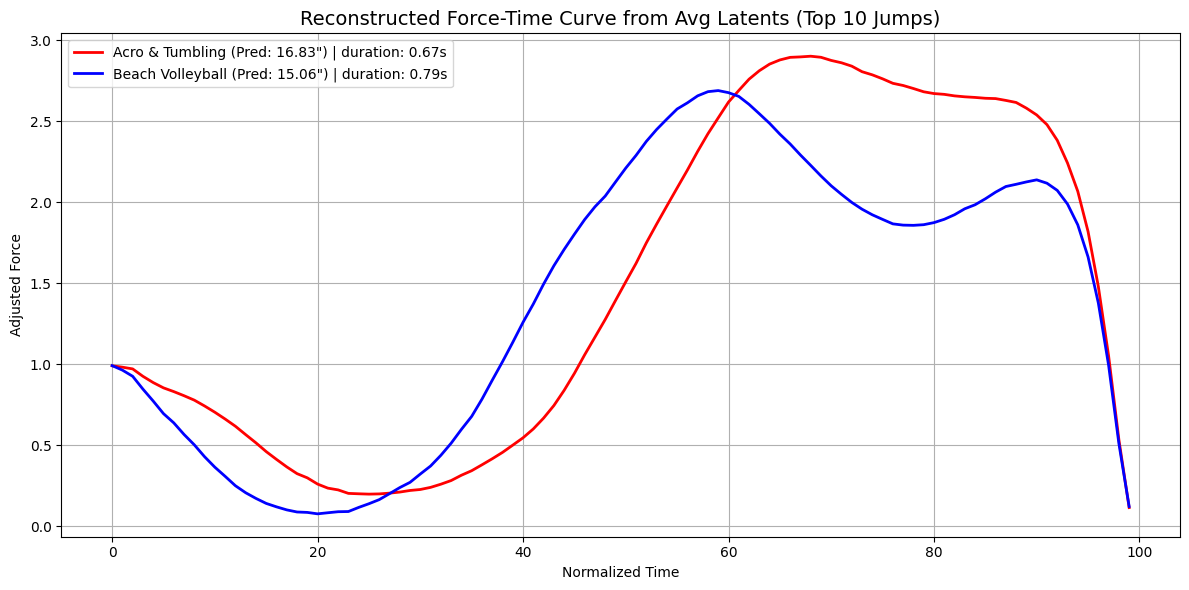

In [110]:
jump_mean = binned_females["jump_duration_s"].mean()
jump_std = binned_females["jump_duration_s"].std()

acro_latents = np.stack(acro_top10["vae_latent_space_4d"].values)
vb_latents = np.stack(volleyball_top10["vae_latent_space_4d"].values)
avg_acro_latent = np.mean(acro_latents, axis=0)
avg_vb_latent = np.mean(vb_latents, axis=0)

avg_acro_dur_norm = (np.mean(acro_top10["jump_duration_s"]) - jump_mean) / jump_std
avg_vb_dur_norm = (np.mean(volleyball_top10["jump_duration_s"]) - jump_mean) / jump_std

initial_val_acro = np.mean(acro_top10["initial_value"])
initial_val_vb = np.mean(volleyball_top10["initial_value"])

acro_5d = np.concatenate([avg_acro_latent, [avg_acro_dur_norm]])
vb_5d = np.concatenate([avg_vb_latent, [avg_vb_dur_norm]])

def predict_height(z, initial_val):
    z_latent = z[:4]
    t_n_pred = z[4]
    jump_t = t_n_pred * jump_std + jump_mean  

    if jump_t <= 0 or jump_t > 2.0:
        return -100.0

    with torch.no_grad():
        z_tensor = torch.tensor(z_latent, dtype=torch.float32).unsqueeze(0)
        rec = vae.decode(z_tensor).squeeze().cpu().numpy()

    rec = np.clip(rec, 0, 5)

    offset = rec[0] * (20 / initial_val)
    adjusted = rec - offset
    net_force = adjusted - 1.0  

    avg_net_force = np.mean(net_force)

    takeoff_velocity = avg_net_force * jump_t * 9.81
    height_in_inches = (takeoff_velocity ** 2) / (2 * 9.81) * 39.37

    return height_in_inches

predicted_acro_height = predict_height(acro_5d, initial_val_acro)
predicted_vb_height = predict_height(vb_5d, initial_val_vb)


avg_actual_acro_height = np.mean(acro_top10["JUMP_HEIGHT_INCHES_IMP_MOM"])
avg_actual_vb_height = np.mean(volleyball_top10["JUMP_HEIGHT_INCHES_IMP_MOM"])
avg_actual_acro_jump_duration = np.mean(acro_top10["jump_duration_s"])
avg_actual_volleyball_jump_duration = np.mean(volleyball_top10["jump_duration_s"])

print(f"Average Actual Acro & Tumbling Jump Height: {avg_actual_acro_height:.2f}\" Jump Duration: {avg_actual_acro_jump_duration:.2f}s")
print(f"Average Actual Volleyball Jump Height: {avg_actual_vb_height:.2f}\" Jump Duration: {avg_actual_volleyball_jump_duration:.2f}s")


with torch.no_grad():
    acro_decoded = vae.decode(torch.tensor(avg_acro_latent, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()
    vb_decoded = vae.decode(torch.tensor(avg_vb_latent, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()

plt.figure(figsize=(12, 6))
plt.plot(acro_decoded, label=f"Acro & Tumbling (Pred: {predicted_acro_height:.2f}\") | duration: {avg_actual_acro_jump_duration:.2f}s", color="red", linewidth=2)
plt.plot(vb_decoded, label=f"Beach Volleyball (Pred: {predicted_vb_height:.2f}\") | duration: {avg_actual_volleyball_jump_duration:.2f}s", color="blue", linewidth=2)

plt.title("Reconstructed Force-Time Curve from Avg Latents (Top 10 Jumps)", fontsize=14)
plt.xlabel("Normalized Time")
plt.ylabel("Adjusted Force")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [111]:
print(f"Average Actual Acro Jump Height (Flight Time): {avg_actual_acro_height:.2f}\"")
print(f"Average Actual Acro Jump Height (Impulse-Momentum): {acro_top10['JUMP_HEIGHT_INCHES_IMP_MOM'].mean():.2f}\"")
print(f"Predicted Acro Height from Latent: {predicted_acro_height:.2f}\"")

print(f"Average Actual Volleyball Jump Height (Flight Time): {avg_actual_vb_height:.2f}\"")
print(f"Average Actual Volleyball Jump Height (Impulse-Momentum): {volleyball_top10['JUMP_HEIGHT_INCHES_IMP_MOM'].mean():.2f}\"")
print(f"Predicted Volleyball Height from Latent: {predicted_vb_height:.2f}\"")


Average Actual Acro Jump Height (Flight Time): 16.20"
Average Actual Acro Jump Height (Impulse-Momentum): 16.20"
Predicted Acro Height from Latent: 16.83"
Average Actual Volleyball Jump Height (Flight Time): 14.36"
Average Actual Volleyball Jump Height (Impulse-Momentum): 14.36"
Predicted Volleyball Height from Latent: 15.06"


In [112]:
avg_acro_latent

array([-1.234056  ,  0.41012806, -0.924503  ,  0.8543331 ], dtype=float32)

The 5d Latent Space (with time): [-0.26089153  0.35350519 -0.08935878 -0.12654097 -0.122253  ]



/anaconda/envs/azureml_py38/lib/python3.10/site-packages/scipy/optimize/_optimize.py:353: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


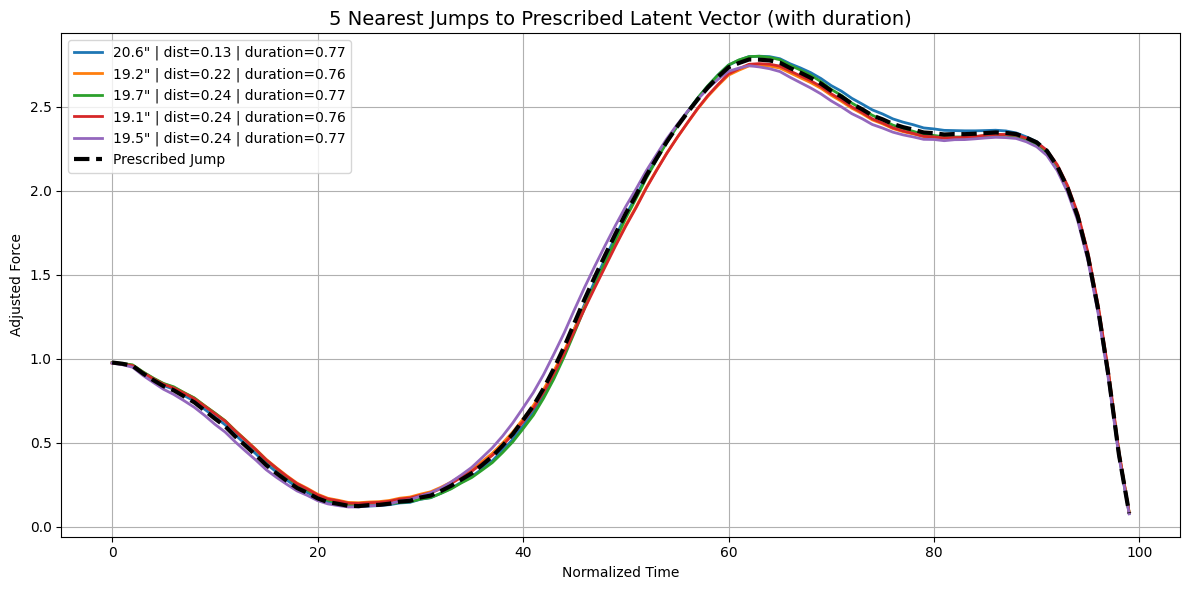

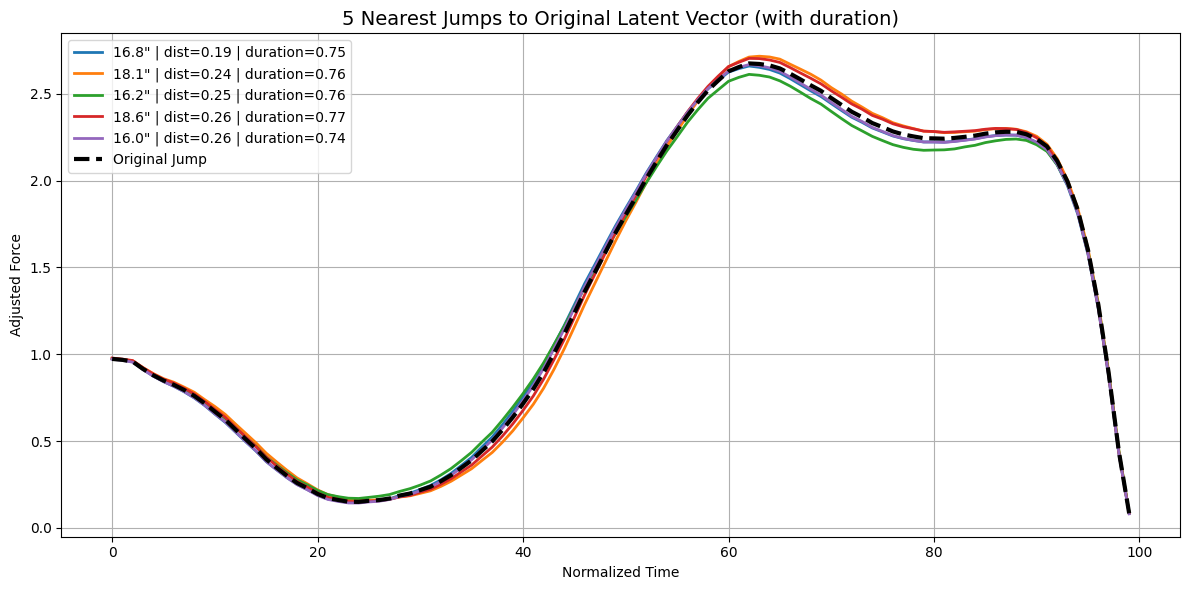


Jump ID: 657cdaf4-e31f-4003-a48b-287f51ec7149, Date: 2024-11-19 21:11:39.327000+00:00
Predicted Original Height: 17.21 inches
Target Prescribed Height: 20.21 inches
Predicted Prescribed Height: 20.21 inches
Latent change magnitude: 0.4318
Original jump duration: 0.754s | New duration: 0.768s

Latent Dimension Comparison:
z1        -0.2609     -0.4158           -0.1549
z2         0.3535      0.6994            0.3459
z3        -0.0894     -0.1089           -0.0195
z4        -0.1265     -0.0359            0.0906
t_n       -0.1223      0.0629            0.1851


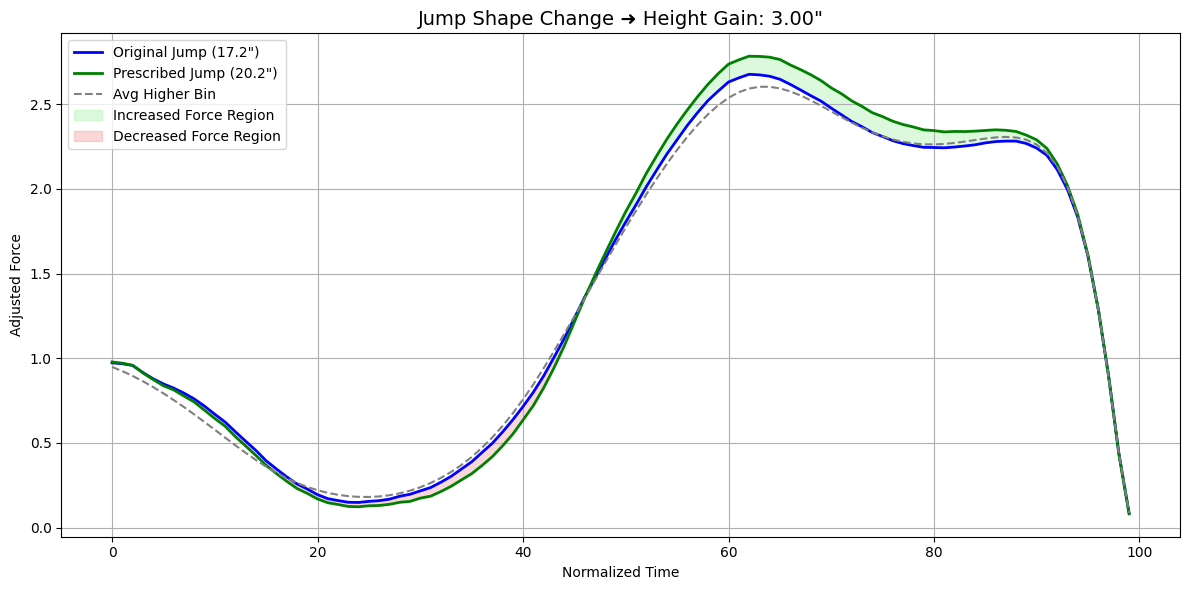

Impulse Difference of +17.21 Newtons to improve jump by 3 inches.


In [113]:
from scipy.optimize import basinhopping
from scipy.stats import pearsonr


def prescribe_jump_improvement(profileID, model_df, vae, top_n=1, delta=1.0):
    jump_mean = model_df["jump_duration_s"].mean()
    jump_std = model_df["jump_duration_s"].std()
    vae.eval()
    athlete_df = model_df[model_df["profileID"] == profileID].copy()
    
    if athlete_df.empty:
        print(f"No data found for profileID: {profileID}")
        return

    top_jumps = athlete_df.sort_values("recordedUTC", ascending=False).head(top_n)

    for idx, row in top_jumps.iterrows():
        latent_vec = np.array(row["vae_latent_space_4d"])
        jump_duration = row["jump_duration_s"]
        initial_val = row["initial_value"]
        jump_date = row["recordedUTC"]
        actual_recorded_height = row["JUMP_HEIGHT_INCHES"]

        if initial_val < 1e-3:
            print(f"[SKIP] initial_val too small ({initial_val})")
            continue
        if jump_duration > 2.0 or jump_duration <= 0:
            print(f"[SKIP] suspicious jump_duration ({jump_duration:.3f}s)")
            continue

        # latent vector with normalized time
        t_n = (jump_duration - jump_mean) / jump_std
        latent_5d = np.concatenate([latent_vec, [t_n]])
        print(f"The 5d Latent Space (with time): {latent_5d}\n")

        def predict_height(z):
            z_latent = z[:4]
            t_n_pred = z[4]
            jump_t = t_n_pred * jump_std + jump_mean  # denormalize

            if jump_t <= 0 or jump_t > 2.0:
                return -100.0  # invalid duration penalty

            with torch.no_grad():
                z_tensor = torch.tensor(z_latent, dtype=torch.float32).unsqueeze(0)
                rec = vae.decode(z_tensor).squeeze().cpu().numpy()

            rec = np.clip(rec, 0, 5)
            offset = rec[0] * (20 / initial_val)
            adjusted = rec - offset
            net_force = adjusted - 1.0
            avg_net_force = np.mean(net_force)
            takeoff_velocity = avg_net_force * jump_t * 9.81
            height = (takeoff_velocity ** 2) / (2 * 9.81) * 39.37
            return height

        predicted_orig_height = predict_height(latent_5d)
        target_jump_height = predicted_orig_height + delta

        def objective(z_new):
            pred = predict_height(z_new)
            penalty = max(0, target_jump_height - pred) ** 2
            return np.sum((z_new - latent_5d) ** 2) + 10 * penalty

        epsilon = 0.05

        def constraint(z_new):
            return predict_height(z_new) - target_jump_height

        def min_latent_shift(z_new):
            return np.linalg.norm(z_new - latent_5d) - epsilon

        bounds = [(val - 2.0, val + 2.0) for val in latent_vec] + [(-2.0, 2.0)]  # t_n bound

        constraints = [
            {'type': 'ineq', 'fun': constraint},
            {'type': 'ineq', 'fun': min_latent_shift},
        ]

        minimizer_kwargs = {
            "method": "SLSQP",
            "bounds": bounds,
            "constraints": constraints
        }

        result = basinhopping(objective, x0=latent_5d, minimizer_kwargs=minimizer_kwargs, niter=100)

        z_new = result.x
        jump_mean = model_df["jump_duration_s"].mean()
        jump_std = model_df["jump_duration_s"].std()
        model_df["t_n"] = (model_df["jump_duration_s"] - jump_mean) / jump_std

        # Build 5D latent vectors: [z1, z2, z3, z4, t_n]
        model_df["latent_space_5d"] = model_df.apply(
            lambda r: np.append(r["vae_latent_space_4d"], r["t_n"]), axis=1
        )
        # -----------------------------------------------
        # Plot 5 nearest jumps in latent space to prescribed jump (with jump_duration_s)
        # -----------------------------------------------

        # 5D latent vector of prescribed jump
        z_new_5d = result.x  # should already be 5D: 4D latent + normalized duration

        # Stack all latent 5D vectors
        all_latents_5d = np.stack(model_df["latent_space_5d"].values)

        # Compute Euclidean distance
        latent_distances = np.linalg.norm(all_latents_5d - z_new_5d, axis=1)
        model_df["latent_distance"] = latent_distances

        # Exclude same profileID and jump
        exclude_mask = (model_df["profileID"] != row["profileID"]) | (model_df["recordedUTC"] != jump_date)

        # Combine masks
        filtered_df = model_df[exclude_mask].copy()

        # Sort and get top 5
        nearest_jumps = filtered_df.sort_values("latent_distance").head(5)

        # Plotting
        plt.figure(figsize=(12, 6))

        for i, near_row in nearest_jumps.iterrows():
            near_latent = np.array(near_row["vae_latent_space_4d"])
            init_val = near_row["initial_value"]
            jump_height = near_row["latent_predicted_jump_height"]
            distance = near_row["latent_distance"]
            jump_time = near_row["jump_duration_s"]

            with torch.no_grad():
                decoded = vae.decode(torch.tensor(near_latent, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()

            offset = decoded[0] * (20 / init_val)
            adjusted = decoded - offset

            label = f"{jump_height:.1f}\" | dist={distance:.2f} | duration={jump_time:.2f}"
            plt.plot(adjusted, linewidth=2, label=label)

        # Plot prescribed jump
        z_new_latent = z_new_5d[:4]
        with torch.no_grad():
            decoded_prescribed = vae.decode(torch.tensor(z_new_latent, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()
        offset_prescribed = decoded_prescribed[0] * (20 / initial_val)
        adjusted_prescribed = decoded_prescribed - offset_prescribed

        plt.plot(adjusted_prescribed, color='black', linestyle='--', linewidth=3, label="Prescribed Jump")
        plt.title("5 Nearest Jumps to Prescribed Latent Vector (with duration)", fontsize=14)
        plt.xlabel("Normalized Time")
        plt.ylabel("Adjusted Force")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()



        # -----------------------------------------------
        # Plot 5 nearest jumps in latent space to original jump (with jump_duration_s)
        # -----------------------------------------------

        # Get original latent vector + normalized jump duration
        orig_latent_vec = latent_vec  # 4D latent of original jump
        orig_t_n = (row["jump_duration_s"] - jump_mean) / jump_std
        orig_latent_5d = np.append(orig_latent_vec, orig_t_n)

        # Stack all 5D latent vectors
        all_latents_5d = np.stack(model_df["latent_space_5d"].values)

        # Compute Euclidean distances
        orig_latent_distances = np.linalg.norm(all_latents_5d - orig_latent_5d, axis=1)
        model_df["latent_distance_orig"] = orig_latent_distances

        # Exclude same profileID and jump
        exclude_mask_orig = (model_df["profileID"] != row["profileID"]) | (model_df["recordedUTC"] != jump_date)

        # Combine masks
        filtered_df_orig = model_df[exclude_mask_orig].copy()

        # Get top 5
        nearest_jumps_orig = filtered_df_orig.sort_values("latent_distance_orig").head(5)

        # Plot
        plt.figure(figsize=(12, 6))
        for i, near_row in nearest_jumps_orig.iterrows():
            near_latent = np.array(near_row["vae_latent_space_4d"])
            init_val = near_row["initial_value"]
            jump_height = near_row["latent_predicted_jump_height"]
            distance = near_row["latent_distance_orig"]
            jump_time = near_row["jump_duration_s"]

            with torch.no_grad():
                decoded = vae.decode(torch.tensor(near_latent, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()

            offset = decoded[0] * (20 / init_val)
            adjusted = decoded - offset

            label = f"{jump_height:.1f}\" | dist={distance:.2f} | duration={jump_time:.2f}"
            plt.plot(adjusted, linewidth=2, label=label)

        # Plot original jump
        with torch.no_grad():
            decoded_orig = vae.decode(torch.tensor(orig_latent_vec, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()
        offset_orig = decoded_orig[0] * (20 / initial_val)
        adjusted_orig = decoded_orig - offset_orig

        plt.plot(adjusted_orig, color='black', linestyle='--', linewidth=3, label="Original Jump")
        plt.title("5 Nearest Jumps to Original Latent Vector (with duration)", fontsize=14)
        plt.xlabel("Normalized Time")
        plt.ylabel("Adjusted Force")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()




        
        z_new_latent = z_new[:4]
        z_new_tn = z_new[4]
        predicted_new_height = predict_height(z_new)

        print("\n" + "=" * 60)
        print(f"Jump ID: {row['profileID']}, Date: {jump_date}")
        print(f"Predicted Original Height: {predicted_orig_height:.2f} inches")
        print(f"Target Prescribed Height: {target_jump_height:.2f} inches")
        print(f"Predicted Prescribed Height: {predicted_new_height:.2f} inches")
        print(f"Latent change magnitude: {np.linalg.norm(z_new - latent_5d):.4f}")
        print(f"Original jump duration: {jump_duration:.3f}s | New duration: {z_new_tn * jump_std + jump_mean:.3f}s")

        print(f"\nLatent Dimension Comparison:")
        for i, (orig, new) in enumerate(zip(latent_5d, z_new)):
            label = "t_n" if i == 4 else f"z{i+1}"
            print(f"{label:<5}{orig:>12.4f}{new:>12.4f}{(new - orig):>18.4f}")

        with torch.no_grad():
            rec_orig = vae.decode(torch.tensor(latent_vec, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()
            rec_new = vae.decode(torch.tensor(z_new_latent, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()

        offset_orig = rec_orig[0] * (20 / initial_val)
        offset_new = rec_new[0] * (20 / initial_val)
        adj_orig = rec_orig - offset_orig
        adj_new = rec_new - offset_new

        def parse_bin_label(label):
            start, end = label.split('-')
            return float(start), float(end)

        unique_bins = model_df['jump_bin'].dropna().unique()
        bin_tuples = [(label, *parse_bin_label(label)) for label in unique_bins]
        bin_tuples.sort(key=lambda x: x[1])

        current_bin_label = None
        next_bin_label = None
        for i, (label, start, end) in enumerate(bin_tuples):
            if start <= predicted_orig_height < end:
                current_bin_label = label
                if i + 1 < len(bin_tuples):
                    next_bin_label = bin_tuples[i + 1][0]
                break

        higher_bin_latents = model_df[model_df['JUMP_HEIGHT_INCHES'] > actual_recorded_height]
        if next_bin_label:
            higher_bin_latents = higher_bin_latents[higher_bin_latents['jump_bin'] == next_bin_label]

        if not higher_bin_latents.empty and 'downsampled_time_series' in higher_bin_latents.columns:
            downsampled_arrays = np.stack(higher_bin_latents['downsampled_time_series'].values)
            avg_downsampled_ts = np.mean(downsampled_arrays, axis=0)

            offset_higher_bin = avg_downsampled_ts[0] * (20 / initial_val)
            adj_higher_bin = avg_downsampled_ts - offset_higher_bin
            rmse_orig = np.sqrt(np.mean((adj_orig - adj_higher_bin) ** 2))
            rmse_new = np.sqrt(np.mean((adj_new - adj_higher_bin) ** 2))
            corr_orig, _ = pearsonr(adj_orig, adj_higher_bin)
            corr_new, _ = pearsonr(adj_new, adj_higher_bin)

            height_gain = predicted_new_height - predicted_orig_height

            plt.figure(figsize=(12, 6))
            plt.plot(adj_orig, label=f'Original Jump ({predicted_orig_height:.1f}")', color='blue', linewidth=2)
            plt.plot(adj_new, label=f'Prescribed Jump ({predicted_new_height:.1f}")', color='green', linewidth=2)
            if 'adj_higher_bin' in locals():
                plt.plot(adj_higher_bin, label='Avg Higher Bin', linestyle='--', color='gray')

            plt.fill_between(range(len(adj_orig)), adj_orig, adj_new, 
                             where=(adj_new > adj_orig), interpolate=True, 
                             color='lightgreen', alpha=0.3, label='Increased Force Region')
            plt.fill_between(range(len(adj_orig)), adj_orig, adj_new, 
                             where=(adj_new < adj_orig), interpolate=True, 
                             color='lightcoral', alpha=0.3, label='Decreased Force Region')

            plt.title(f"Jump Shape Change ➜ Height Gain: {height_gain:.2f}\"", fontsize=14)
            plt.xlabel("Normalized Time")
            plt.ylabel("Adjusted Force")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

            avg_force_diff = np.mean(adj_new - adj_orig)

            dt = (jump_duration / len(adj_orig))  # seconds per sample
            impulse_diff = np.sum((adj_new - adj_orig) * dt)  # in BW·s

            force_l2_diff = np.linalg.norm(adj_new - adj_orig)
            mass_kg = initial_val / 9.81  
            impulse_diff_newtons = impulse_diff * mass_kg * 9.81  

            print(f"Impulse Difference of +{impulse_diff_newtons:.2f} Newtons to improve jump by {delta} inches.")

        else:
            print("No higher bin data with downsampled_time_series available.")

prescribe_jump_improvement(profileID="657cdaf4-e31f-4003-a48b-287f51ec7149", model_df=binned_males, top_n=1, vae=vae, delta=3)


In [114]:
binned_males.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space_consistency,reconstruction_loss,reconstruction,outlier,total_sessions,start_year,years_training,first_session_date,relative_session,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,initial_weight,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2,vae_latent_space_4d,reconstructed_waveform,adjusted_reconstruction,predicted_takeoff_velocity,latent_predicted_jump_height,avg_diff_recon_vs_downsampled,avg_magnitude_downsampled,diff_ratio,jump_bin,t_n,latent_space_5d,latent_distance,latent_distance_orig
28139,543,543,5cf946e0-2b95-4ba6-9e5f-2987907ef93b,4,4c783ecb-b867-463b-a2e0-9c83cea770f8,2022-08-14 18:20:38.182000+00:00,Men's Basketball,Team,NaN,NaN,201.468898,110.046,110.434,110.172,110.254,18.134567,110.046,8.351873,7.452329,0.416,21.213745,18.921078,18.928905,30.698,result\nPOSITIVE_IMPULSE 556.193919\nPOSIT...,2775.454

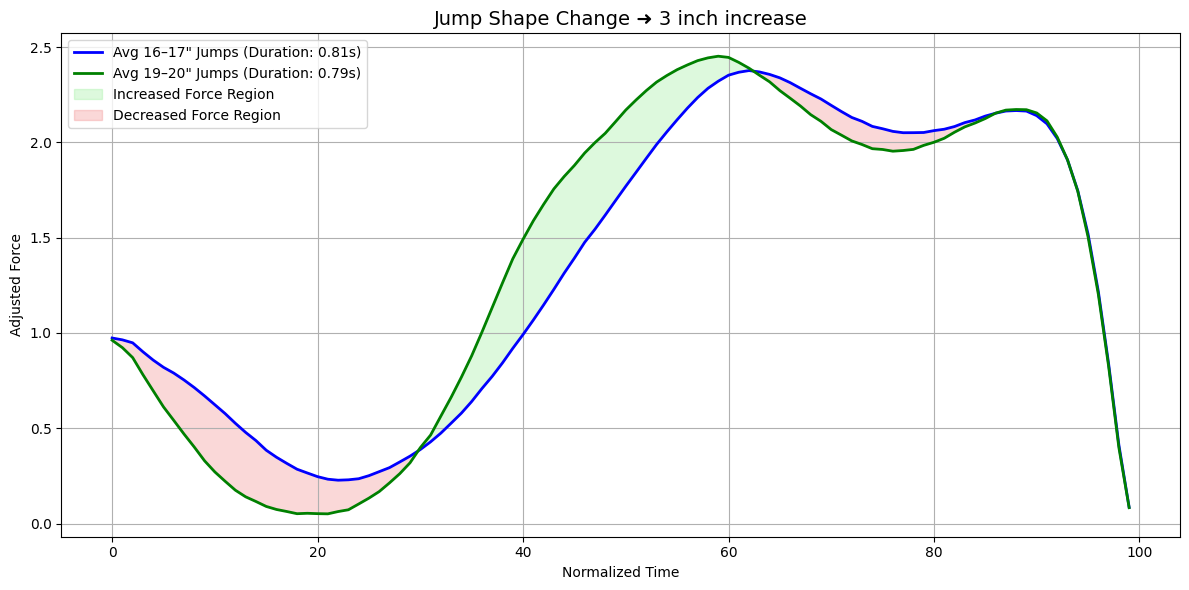

In [115]:
import numpy as np
import matplotlib.pyplot as plt

# Filter data for the specified player
player_id = "657cdaf4-e31f-4003-a48b-287f51ec7149"
player_df = binned_males[binned_males["profileID"] == player_id]

# Filter jumps by height range
jumps_16_17 = player_df[(player_df["JUMP_HEIGHT_INCHES"] >= 16) & (player_df["JUMP_HEIGHT_INCHES"] < 17)]
jumps_19_20 = player_df[(player_df["JUMP_HEIGHT_INCHES"] >= 19) & (player_df["JUMP_HEIGHT_INCHES"] < 20)]

# Stack and compute mean adjusted reconstructions
avg_ts_16_17 = np.mean(np.stack(jumps_16_17["adjusted_reconstruction"].values), axis=0)
avg_ts_19_20 = np.mean(np.stack(jumps_19_20["adjusted_reconstruction"].values), axis=0)

# Compute average durations
avg_duration_16_17 = jumps_16_17["jump_duration_s"].mean()
avg_duration_19_20 = jumps_19_20["jump_duration_s"].mean()

# Plot with formatting
plt.figure(figsize=(12, 6))
plt.plot(avg_ts_16_17, label=f'Avg 16–17" Jumps (Duration: {avg_duration_16_17:.2f}s)', color='blue', linewidth=2)
plt.plot(avg_ts_19_20, label=f'Avg 19–20" Jumps (Duration: {avg_duration_19_20:.2f}s)', color='green', linewidth=2)

# Fill between for increase and decrease regions
plt.fill_between(
    range(len(avg_ts_16_17)), avg_ts_16_17, avg_ts_19_20,
    where=(avg_ts_19_20 > avg_ts_16_17), interpolate=True,
    color='lightgreen', alpha=0.3, label='Increased Force Region'
)
plt.fill_between(
    range(len(avg_ts_16_17)), avg_ts_16_17, avg_ts_19_20,
    where=(avg_ts_19_20 < avg_ts_16_17), interpolate=True,
    color='lightcoral', alpha=0.3, label='Decreased Force Region'
)

plt.title("Jump Shape Change ➜ 3 inch increase", fontsize=14)
plt.xlabel("Normalized Time")
plt.ylabel("Adjusted Force")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [116]:
binned_males.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space_consistency,reconstruction_loss,reconstruction,outlier,total_sessions,start_year,years_training,first_session_date,relative_session,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,initial_weight,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2,vae_latent_space_4d,reconstructed_waveform,adjusted_reconstruction,predicted_takeoff_velocity,latent_predicted_jump_height,avg_diff_recon_vs_downsampled,avg_magnitude_downsampled,diff_ratio,jump_bin,t_n,latent_space_5d,latent_distance,latent_distance_orig
28139,543,543,5cf946e0-2b95-4ba6-9e5f-2987907ef93b,4,4c783ecb-b867-463b-a2e0-9c83cea770f8,2022-08-14 18:20:38.182000+00:00,Men's Basketball,Team,NaN,NaN,201.468898,110.046,110.434,110.172,110.254,18.134567,110.046,8.351873,7.452329,0.416,21.213745,18.921078,18.928905,30.698,result\nPOSITIVE_IMPULSE 556.193919\nPOSIT...,2775.454

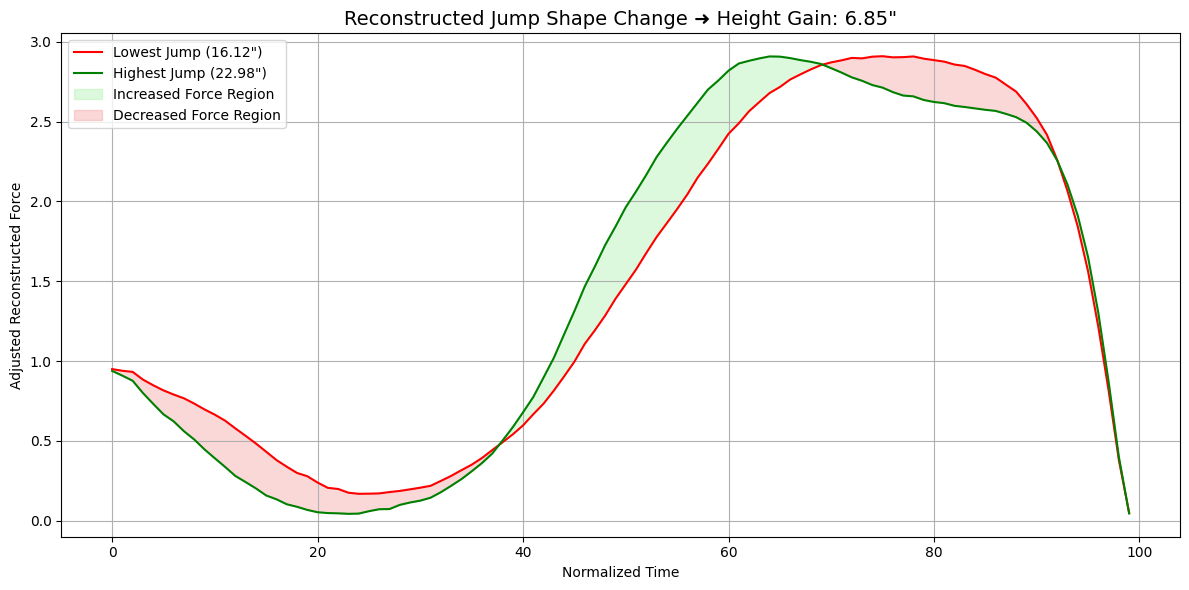

Improvement from 16.12" to 22.98" (6.85" gain)


In [117]:

def compare_reconstruction_improvement(profileID, model_df):
    athlete_df = model_df[model_df["profileID"] == profileID].copy()

    if athlete_df.empty or "adjusted_reconstruction" not in athlete_df.columns:
        print(f"No valid reconstructed data for athlete {profileID}")
        return

    # Get jumps with min and max height
    min_jump = athlete_df.loc[athlete_df["JUMP_HEIGHT_INCHES"].idxmin()]
    max_jump = athlete_df.loc[athlete_df["JUMP_HEIGHT_INCHES"].idxmax()]

    # Use reconstructed curves and correct for offset
    def get_adjusted_reconstruction(jump):
        raw = np.array(jump["adjusted_reconstruction"])
        initial_val = jump["initial_value"]
        offset = raw[0] * (20 / initial_val)
        return raw - offset

    adj_min = get_adjusted_reconstruction(min_jump)
    adj_max = get_adjusted_reconstruction(max_jump)

    jump_height_min = min_jump["JUMP_HEIGHT_INCHES"]
    jump_height_max = max_jump["JUMP_HEIGHT_INCHES"]
    delta_height = jump_height_max - jump_height_min

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(adj_min, label=f"Lowest Jump ({jump_height_min:.2f}\")", color="red")
    plt.plot(adj_max, label=f"Highest Jump ({jump_height_max:.2f}\")", color="green")

    plt.fill_between(
        range(len(adj_min)),
        adj_min,
        adj_max,
        where=(adj_max > adj_min),
        interpolate=True,
        color='lightgreen',
        alpha=0.3,
        label="Increased Force Region"
    )

    plt.fill_between(
        range(len(adj_min)),
        adj_min,
        adj_max,
        where=(adj_max < adj_min),
        interpolate=True,
        color='lightcoral',
        alpha=0.3,
        label="Decreased Force Region"
    )

    plt.title(f"Reconstructed Jump Shape Change ➜ Height Gain: {delta_height:.2f}\"", fontsize=14)
    plt.xlabel("Normalized Time")
    plt.ylabel("Adjusted Reconstructed Force")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Improvement from {jump_height_min:.2f}\" to {jump_height_max:.2f}\" ({delta_height:.2f}\" gain)")

# Example usage
compare_reconstruction_improvement(profileID="07423259-c766-43af-82ec-6fb0383d3484", model_df=binned_males)


In [118]:
athlete_df = binned_males[binned_males["profileID"] == "07423259-c766-43af-82ec-6fb0383d3484"].copy()

# min_jump_height = athlete_df["JUMP_HEIGHT_INCHES"].min()
# min_jump_row = athlete_df.loc[[athlete_df["JUMP_HEIGHT_INCHES"].idxmin()]]

# # Find jumps at least 1 inch above min jump
# higher_jumps_1inch = athlete_df[athlete_df["JUMP_HEIGHT_INCHES"] >= min_jump_height + 1.0]

# if not higher_jumps_1inch.empty:
#     # Find the jump with height closest to exactly min_jump_height + 1
#     target_height = min_jump_height + 1.0
#     next_high_jump_idx = (higher_jumps_1inch["JUMP_HEIGHT_INCHES"] - target_height).abs().idxmin()
#     next_high_jump_row = athlete_df.loc[[next_high_jump_idx]]
# else:
#     next_high_jump_row = None

# print("Min jump row:")
# # print(min_jump_row)

# if next_high_jump_row is not None:
#     print("\nNext higher jump row:")
# else:
#     print("\nNo next higher jump at least 1 inch above minimum available.")

# next_high_jump_row
# if next_high_jump_row is not None:
#     two_jumps_df = pd.concat([min_jump_row, next_high_jump_row])
# else:
#     two_jumps_df = min_jump_row.copy()  


two_jumps_df = athlete_df.copy()


In [119]:
two_jumps_df


,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,BODY_WEIGHT_LBS,START_OF_MOVEMENT,BEGIN_CONCENTRIC_PHASE,BEGIN_BRAKING_PHASE,BEGIN_ECC_DECEL_PHASE,START_OF_MOVEMENT_THRESHOLD,START_OF_INTEGRATION,JUMP_HEIGHT_INCHES,JUMP_HEIGHT_INCHES_IMP_MOM,FLIGHT_TIME,JUMP_HEIGHT,IMPULSE_JUMP_HEIGHT,JUMP_HEIGHT_IMP_MOM,WEIGHT_RELATIVE_PEAK_LANDING_FORCE,POSITIVE_IMPULSE,JUMP_HEIGHT_RELATIVE_LANDING_RFD,JUMP_HEIGHT_RELATIVE_PEAK_LANDING_FORCE,LANDING_RFD,MEAN_LANDING_ACCELERATION,MEAN_LANDING_POWER,MEAN_LANDING_VELOCITY,PEAK_LANDING_ACCELERATION,PEAK_LANDING_FORCE,PEAK_LANDING_POWER,PEAK_LANDING_VELOCITY,RELATIVE_PEAK_LANDING_FORCE,LANDING_IMPULSE,LANDING_RFD_50,MEAN_ECCENTRIC_FORCE,MEAN_ECCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_ECCENTRIC_POWER,RELATIVE_ECCENTRIC_BRAKING_RFD,ECCENTRIC_BRAKING_IMPULSE,MEAN_ECCENTRIC_BRAKING_FORCE,MEAN_ECCENTRIC_DECELERATION_FORCE,ECCENTRIC_BRAKING_RFD,ECCENTRIC_DECEL_RFD,RELATIVE_ECCENTRIC_DECEL_RFD,PEAK_ECCENTRIC_FORCE,RELATIVE_PEAK_ECCENTRIC_FORCE,LOWER_LIMB_STIFFNESS,ECCENTRIC_DECEL_IMPULSE,BODYMASS_RELATIVE_ECCENTRIC_PEAK_POWER,MIN_ECCENTRIC_FORCE,ECCENTRIC_BRAKING_RFD_100MS,RELATIVE_ECCENTRIC_BRAKING_RFD_100MS,ECCENTRIC_PEAK_VELOCITY,ECCENTRIC_PEAK_POWER,BODYMASS_RELATIVE_ECC_DECEL_IMPULSE,RSI_MODIFIED,RSI_MODIFIED_IMP_MOM,MEAN_ECC_CON_RATIO,FORCE_AT_PEAK_POWER,CONTRACTION_TIME,ECCENTRIC_TIME,TIME_TO_PEAK_FORCE,START_TO_PEAK_FORCE_TIME,START_TO_PEAK_POWER_TIME,CONCENTRIC_DURATION,CONCENTRIC_ECCENTRIC_DURATION_RATIO,ECCENTRIC_CONCENTRIC_DURATION_RATIO,FLIGHT_CONTRACTION_TIME_RATIO,FLIGHT_ECCENTRIC_TIME_RATIO,BRAKING_PHASE_DURATION,TIME_TO_BRAKING_PHASE,ECCENTRIC_ACCEL_PHASE_DURATION,ECCENTRIC_DECEL_PHASE_DURATION,BEAKING_CONTRACTION_DURATION_RATIO,BEAKING_CONCENTRIC_DURATION_RATIO,MEAN_ECC_CON_POWER_TIME,FORCE_AT_ZERO_VELOCITY,ECC_CON_PEAK_POWER_RATIO,CON_P2_CON_P1_IMPULSE_RATIO,CON_100MS_CON_IMPULSE_RATIO,BM_REL_FORCE_AT_ZERO_VELOCITY,COUNTERMOVEMENT_DEPTH,DISPLACEMENT_AT_TAKEOFF,BODYMASS_RELATIVE_TAKEOFF_POWER,MEAN_TAKEOFF_FORCE,MEAN_CONCENTRIC_POWER,BODYMASS_RELATIVE_MEAN_CONCENTRIC_POWER,MEAN_TAKEOFF_VELOCITY,PEAK_TAKEOFF_FORCE,PEAK_TAKEOFF_POWER,PEAK_TAKEOFF_VELOCITY,TAKEOFF_VELOCITY,RELATIVE_PEAK_TAKEOFF_FORCE,PEAK_CONCENTRIC_FORCE,RELATIVE_PEAK_CONCENTRIC_FORCE,CONCENTRIC_IMPULSE,POSITIVE_TAKEOFF_IMPULSE,BODYMASS_RELATIVE_MEAN_TAKEOFF_FORCE,BM_REL_ABS_CON_IMPULSE,MEAN_TAKEOFF_ACCELERATION,CONCENTRIC_RFD,CONCENTRIC_RFD_MAX,RELATIVE_CONCENTRIC_RFD,CONCENTRIC_RPD,RELATIVE_CONCENTRIC_RPD,PEAK_TAKEOFF_ACCELERATION,CONCENTRIC_RFD_100,CONCENTRIC_RFD_200,CONCENTRIC_RFD_50,WEIGHT_RELATIVE_PEAK_TAKEOFF_FORCE,CONCENTRIC_IMPULSE_50MS,CONCENTRIC_IMPULSE_100MS,CONCENTRIC_IMPULSE_P1,CONCENTRIC_IMPULSE_P2,CONCENTRIC_RPD_50MS,RELATIVE_CONCENTRIC_RPD_50MS,CONCENTRIC_RPD_100MS,RELATIVE_CONCENTRIC_RPD_100MS,TOTAL_WORK,VELOCITY_AT_PEAK_POWER,CMJ_STIFFNESS,ECCENTRIC_UNLOADING_IMPULSE,id_rep,time_series,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space_consistency,reconstruction_loss,reconstruction,outlier,total_sessions,start_year,years_training,first_session_date,relative_session,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,initial_weight,jump_start,jump_end,jump_duration_s,jump_end_time,Gender,takeoff_velocity,takeoff_velocity_2,tv_jump_height,tv_jump_height_2,vae_latent_space_4d,reconstructed_waveform,adjusted_reconstruction,predicted_takeoff_velocity,latent_predicted_jump_height,avg_diff_recon_vs_downsampled,avg_magnitude_downsampled,diff_ratio,jump_bin,t_n,latent_space_5d,latent_distance,latent_distance_orig
13382,2873,2873,2e6e21cd-efce-4535-a74e-53d453084499,1,07423259-c766-43af-82ec-6fb0383d3484,2024-05-13 17:30:36.672000+00:00,Football,Team,NaN,NaN,211.266573,16.892,17.360,17.070,17.186,16.385292,16.892,16.123261,13.052569,0.578,40.953061,33.269796,33.153506,14.486,result\nPOSITIVE_IMPULSE 829.040725\nPOSITI...,841.623620,57.23

The 5d Latent Space (with time): [-0.42777717  0.88177836  0.47226343  1.27612162  0.09104635]



/anaconda/envs/azureml_py38/lib/python3.10/site-packages/scipy/optimize/_optimize.py:353: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


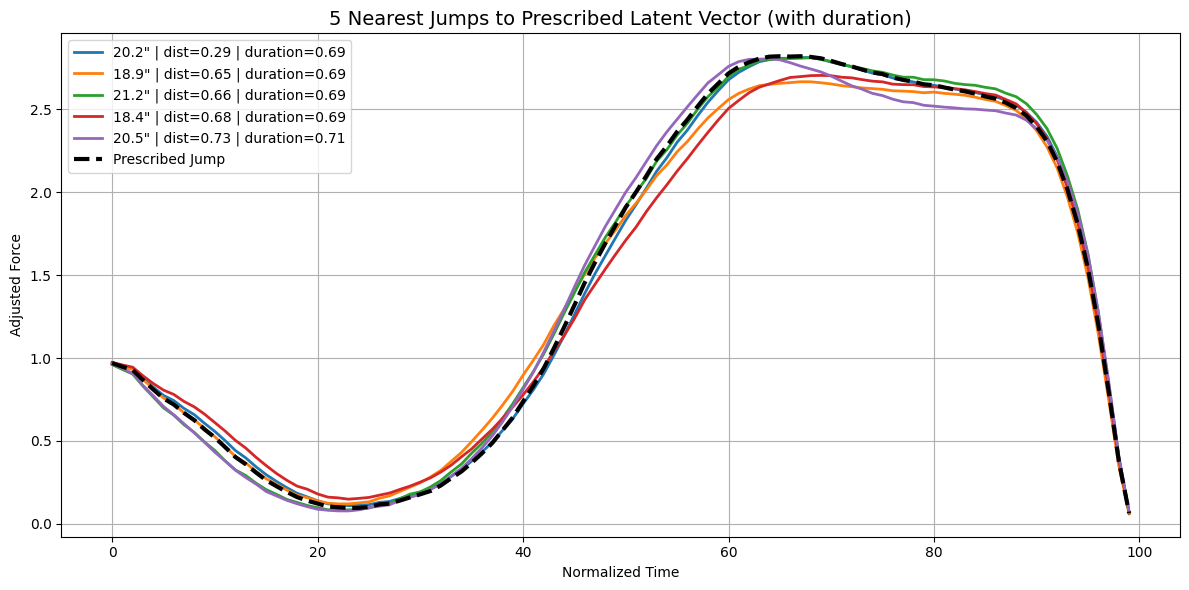

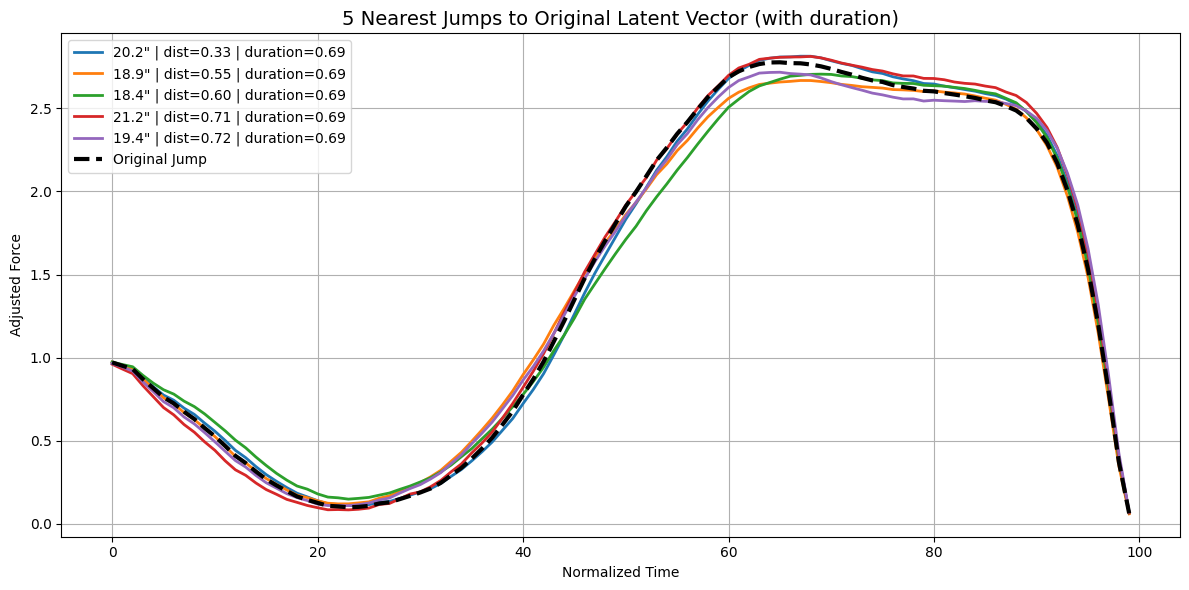


Jump ID: 07423259-c766-43af-82ec-6fb0383d3484, Date: 2024-12-04 14:37:09.295000+00:00
Predicted Original Height: 19.69 inches
Target Prescribed Height: 20.69 inches
Predicted Prescribed Height: 20.69 inches
Latent change magnitude: 0.1784
Original jump duration: 0.692s | New duration: 0.696s

Latent Dimension Comparison:
z1        -0.4278     -0.5317           -0.1040
z2         0.8818      0.9866            0.1048
z3         0.4723      0.4310           -0.0412
z4         1.2761      1.3105            0.0344
t_n        0.0910      0.1756            0.0846


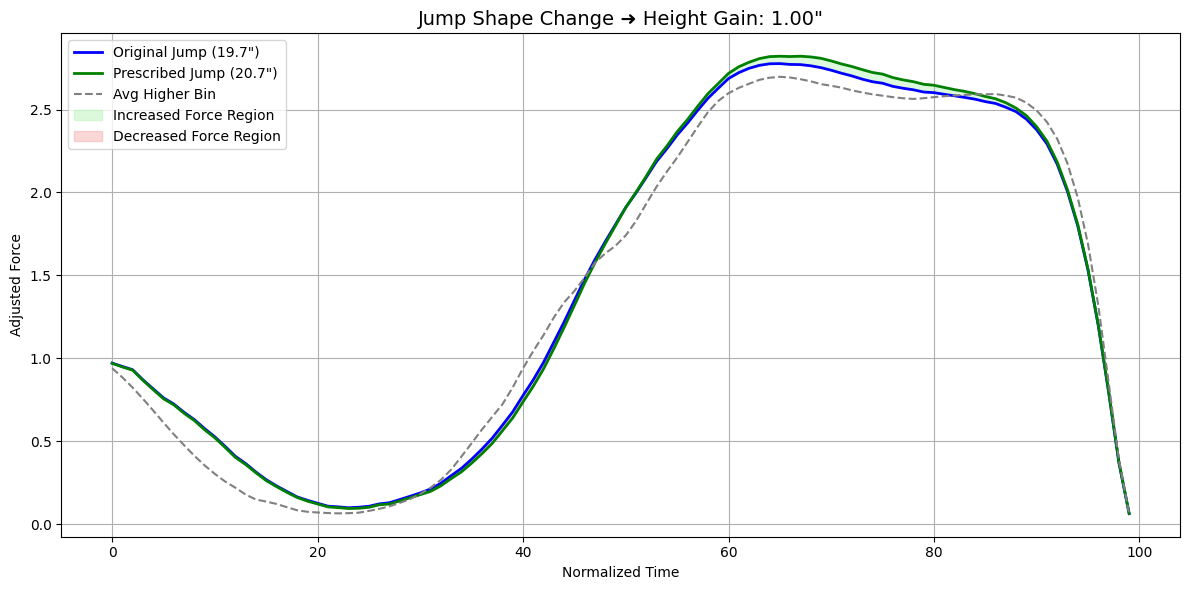

Impulse Difference of +5.56 Newtons to improve jump by 1 inches.


In [120]:
prescribe_jump_improvement(profileID="07423259-c766-43af-82ec-6fb0383d3484", model_df=two_jumps_df, top_n=1, vae=vae, delta=1)

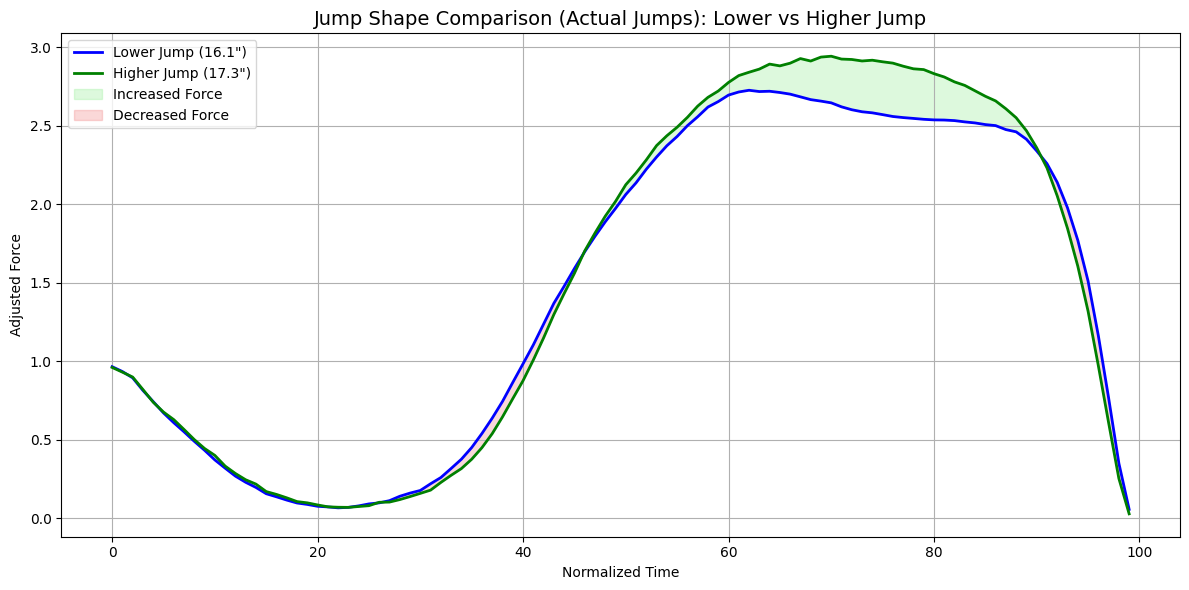

In [130]:
athlete_df = binned_males[binned_males["profileID"] == "07423259-c766-43af-82ec-6fb0383d3484"].copy()

# Find lowest jump
min_jump_row = athlete_df.loc[[athlete_df["latent_predicted_jump_height"].idxmin()]]

# Find next higher jump at least 1 inch above
min_jump_height = min_jump_row["latent_predicted_jump_height"].values[0]
higher_jumps_1inch = athlete_df[athlete_df["latent_predicted_jump_height"] >= min_jump_height + 1.0]

if not higher_jumps_1inch.empty:
    target_height = min_jump_height + 1.0
    next_high_jump_idx = (higher_jumps_1inch["latent_predicted_jump_height"] - target_height).abs().idxmin()
    next_high_jump_row = athlete_df.loc[[next_high_jump_idx]]
    two_jumps_df = pd.concat([min_jump_row, next_high_jump_row])
else:
    two_jumps_df = min_jump_row.copy()
    next_high_jump_row = None

# Decode both jumps
vae.eval()
decoded_curves = []
adjusted_curves = []

for _, row in two_jumps_df.iterrows():
    z = np.array(row["vae_latent_space_4d"])
    initial_val = row["initial_value"]
    
    with torch.no_grad():
        recon = vae.decode(torch.tensor(z, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()

    # Offset adjust using same scaling
    offset = recon[0] * (20 / initial_val)
    adjusted = recon - offset
    
    decoded_curves.append(recon)
    adjusted_curves.append(adjusted)

# Plotting
label_base = f'({two_jumps_df["latent_predicted_jump_height"].iloc[0]:.1f}")'
label_comp = f'({two_jumps_df["latent_predicted_jump_height"].iloc[1]:.1f}")' if next_high_jump_row is not None else None

plt.figure(figsize=(12, 6))
plt.plot(adjusted_curves[0], label=f"Lower Jump {label_base}", color='blue', linewidth=2)
if label_comp:
    plt.plot(adjusted_curves[1], label=f"Higher Jump {label_comp}", color='green', linewidth=2)

    # Fill increased/decreased regions
    diff = adjusted_curves[1] - adjusted_curves[0]
    plt.fill_between(range(len(diff)), adjusted_curves[0], adjusted_curves[1], 
                     where=(diff > 0), interpolate=True, color='lightgreen', alpha=0.3, label='Increased Force')
    plt.fill_between(range(len(diff)), adjusted_curves[0], adjusted_curves[1], 
                     where=(diff < 0), interpolate=True, color='lightcoral', alpha=0.3, label='Decreased Force')

plt.title("Jump Shape Comparison (Actual Jumps): Lower vs Higher Jump", fontsize=14)
plt.xlabel("Normalized Time")
plt.ylabel("Adjusted Force")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [131]:
from scipy.optimize import basinhopping
from scipy.stats import pearsonr


def prescribe_jump_improvement(profileID, model_df, vae, top_n=1, delta=1.0):
    jump_mean = model_df["jump_duration_s"].mean()
    jump_std = model_df["jump_duration_s"].std()
    vae.eval()
    athlete_df = model_df[model_df["profileID"] == profileID].copy()
    
    if athlete_df.empty:
        print(f"No data found for profileID: {profileID}")
        return

    top_jumps = athlete_df.sort_values("recordedUTC", ascending=True).head(top_n)

    for idx, row in top_jumps.iterrows():
        latent_vec = np.array(row["vae_latent_space_4d"])
        jump_duration = row["jump_duration_s"]
        initial_val = row["initial_value"]
        jump_date = row["recordedUTC"]
        actual_recorded_height = row["JUMP_HEIGHT_INCHES"]

        if initial_val < 1e-3:
            print(f"[SKIP] initial_val too small ({initial_val})")
            continue
        if jump_duration > 2.0 or jump_duration <= 0:
            print(f"[SKIP] suspicious jump_duration ({jump_duration:.3f}s)")
            continue

        # latent vector with normalized time
        t_n = (jump_duration - jump_mean) / jump_std
        latent_5d = np.concatenate([latent_vec, [t_n]])
        print(f"The 5d Latent Space (with time): {latent_5d}\n")

        def predict_height(z):
            z_latent = z[:4]
            t_n_pred = z[4]
            jump_t = t_n_pred * jump_std + jump_mean  # denormalize

            if jump_t <= 0 or jump_t > 2.0:
                return -100.0  # invalid duration penalty

            with torch.no_grad():
                z_tensor = torch.tensor(z_latent, dtype=torch.float32).unsqueeze(0)
                rec = vae.decode(z_tensor).squeeze().cpu().numpy()

            rec = np.clip(rec, 0, 5)
            offset = rec[0] * (20 / initial_val)
            adjusted = rec - offset
            net_force = adjusted - 1.0
            avg_net_force = np.mean(net_force)
            takeoff_velocity = avg_net_force * jump_t * 9.81
            height = (takeoff_velocity ** 2) / (2 * 9.81) * 39.37
            return height

        predicted_orig_height = predict_height(latent_5d)
        target_jump_height = predicted_orig_height + delta

        def objective(z_new):
            pred = predict_height(z_new)
            penalty = max(0, target_jump_height - pred) ** 2
            return np.sum((z_new - latent_5d) ** 2) + 10 * penalty

        epsilon = 0.05

        def constraint(z_new):
            return predict_height(z_new) - target_jump_height

        def min_latent_shift(z_new):
            return np.linalg.norm(z_new - latent_5d) - epsilon

        bounds = [(val - 2.0, val + 2.0) for val in latent_vec] + [(-2.0, 2.0)]  # t_n bound

        constraints = [
            {'type': 'ineq', 'fun': constraint},
            {'type': 'ineq', 'fun': min_latent_shift},
        ]

        minimizer_kwargs = {
            "method": "SLSQP",
            "bounds": bounds,
            "constraints": constraints
        }

        result = basinhopping(objective, x0=latent_5d, minimizer_kwargs=minimizer_kwargs, niter=100)

        z_new = result.x
        z_new_latent = z_new[:4]
        z_new_tn = z_new[4]
        predicted_new_height = predict_height(z_new)

        print("\n" + "=" * 60)
        print(f"Jump ID: {row['profileID']}, Date: {jump_date}")
        print(f"Predicted Original Height: {actual_recorded_height:.1f} inches")
        print(f"Target Prescribed Height: {actual_recorded_height + 1:.1f} inches")
        print(f"Predicted Prescribed Height: {actual_recorded_height + 1:.1f} inches")
        print(f"Latent change magnitude: {np.linalg.norm(z_new - latent_5d):.4f}")
        print(f"Original jump duration: {jump_duration:.3f}s | New duration: {z_new_tn * jump_std + jump_mean:.3f}s")

        print(f"\nLatent Dimension Comparison:")
        for i, (orig, new) in enumerate(zip(latent_5d, z_new)):
            label = "t_n" if i == 4 else f"z{i+1}"
            print(f"{label:<5}{orig:>12.4f}{new:>12.4f}{(new - orig):>18.4f}")

        with torch.no_grad():
            rec_orig = vae.decode(torch.tensor(latent_vec, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()
            rec_new = vae.decode(torch.tensor(z_new_latent, dtype=torch.float32).unsqueeze(0)).squeeze().cpu().numpy()

        offset_orig = rec_orig[0] * (20 / initial_val)
        offset_new = rec_new[0] * (20 / initial_val)
        adj_orig = rec_orig - offset_orig
        adj_new = rec_new - offset_new

        def parse_bin_label(label):
            start, end = label.split('-')
            return float(start), float(end)

        unique_bins = model_df['jump_bin'].dropna().unique()
        bin_tuples = [(label, *parse_bin_label(label)) for label in unique_bins]
        bin_tuples.sort(key=lambda x: x[1])

        current_bin_label = None
        next_bin_label = None
        for i, (label, start, end) in enumerate(bin_tuples):
            if start <= predicted_orig_height < end:
                current_bin_label = label
                if i + 1 < len(bin_tuples):
                    next_bin_label = bin_tuples[i + 1][0]
                break

        higher_bin_latents = model_df[model_df['JUMP_HEIGHT_INCHES'] > actual_recorded_height]
        if next_bin_label:
            higher_bin_latents = higher_bin_latents[higher_bin_latents['jump_bin'] == next_bin_label]

        if not higher_bin_latents.empty and 'downsampled_time_series' in higher_bin_latents.columns:
            downsampled_arrays = np.stack(higher_bin_latents['downsampled_time_series'].values)
            avg_downsampled_ts = np.mean(downsampled_arrays, axis=0)

            offset_higher_bin = avg_downsampled_ts[0] * (20 / initial_val)
            adj_higher_bin = avg_downsampled_ts - offset_higher_bin
            rmse_orig = np.sqrt(np.mean((adj_orig - adj_higher_bin) ** 2))
            rmse_new = np.sqrt(np.mean((adj_new - adj_higher_bin) ** 2))
            corr_orig, _ = pearsonr(adj_orig, adj_higher_bin)
            corr_new, _ = pearsonr(adj_new, adj_higher_bin)

            height_gain = predicted_new_height - predicted_orig_height

            plt.figure(figsize=(12, 6))
            plt.plot(adj_orig, label=f'Original Jump ({actual_recorded_height:.1f}")', color='blue', linewidth=2)
            plt.plot(adj_new, label=f'Prescribed Jump ({actual_recorded_height + 1:.1f}")', color='green', linewidth=2)
            # if 'adj_higher_bin' in locals():
                # plt.plot(adj_higher_bin, label='Avg Higher Bin', linestyle='--', color='gray')

            plt.fill_between(range(len(adj_orig)), adj_orig, adj_new, 
                             where=(adj_new > adj_orig), interpolate=True, 
                             color='lightgreen', alpha=0.3, label='Increased Force Region')
            plt.fill_between(range(len(adj_orig)), adj_orig, adj_new, 
                             where=(adj_new < adj_orig), interpolate=True, 
                             color='lightcoral', alpha=0.3, label='Decreased Force Region')

            plt.title(f"Jump Shape Change ➜ Height Gain: {height_gain:.2f}\"", fontsize=14)
            plt.xlabel("Normalized Time")
            plt.ylabel("Adjusted Force")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

            avg_force_diff = np.mean(adj_new - adj_orig)

            dt = (jump_duration / len(adj_orig))  # seconds per sample
            impulse_diff = np.sum((adj_new - adj_orig) * dt)  # in BW·s

            force_l2_diff = np.linalg.norm(adj_new - adj_orig)
            mass_kg = initial_val / 9.81  
            impulse_diff_newtons = impulse_diff * mass_kg * 9.81  

            print(f"Impulse Difference of +{impulse_diff_newtons:.2f} Newtons to improve jump by {delta} inches.")

        else:
            print("No higher bin data with downsampled_time_series available.")

# prescribe_jump_improvement(profileID="657cdaf4-e31f-4003-a48b-287f51ec7149", model_df=binned_males, top_n=1, vae=vae, delta=4)

In [136]:
binned_females.to_pickle("binned_females.pkl")

In [121]:
# saved binned_males
# binned_males.to_pickle("binned_males.pkl")


In [125]:
len(data[(data["Gender"] == "Male") & (data["Team"] == "Men's Golf")]["profileID"].unique())


20